VARIABLE RELATIONSHIPS WITH NO_FLUIDO

In [ ]:
"""
Análisis de relación entre climatología y tráfico (Estado)
Dataset: dataset_final.csv
Estado: 0=Fluido, 1=Denso, 2=Congestionado, 3=Muy congestionado
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv("dataset_final.csv")

# Asume que ya tienes el DataFrame cargado en la variable `df`
print(f"Filas cargadas: {len(df):,}")
print("Columnas:", df.columns.tolist())

# =============================================================
# 2. PREPARACIÓN
# =============================================================
df['fecha']    = pd.to_datetime(df['fecha'])
df['hora_num'] = pd.to_datetime(df['hora'], format='%H:%M:%S').dt.hour
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# Hora punta: mañana (7-9h) y tarde (14-16h)
df['punta'] = df['hora_num'].isin([7, 8, 9, 14, 15, 16]).astype(int)

# Categoría de lluvia
df['lluvia_cat'] = pd.cut(
    df['prec'],
    bins=[-1, 0, 2, 10, 1000],
    labels=['Sin lluvia', 'Suave (<2mm)', 'Moderada (2-10mm)', 'Intensa (>10mm)']
)

# Agregación diaria (una fila por día, promedio de Estado)
por_dia = df.groupby('fecha').agg(
    tmed          = ('tmed',      'first'),
    prec          = ('prec',      'first'),
    tmin          = ('tmin',      'first'),
    tmax          = ('tmax',      'first'),
    sol           = ('sol',       'first'),
    pct_no_fluido = ('no_fluido', 'mean')
).reset_index()

por_dia['cuartil_temp'] = pd.qcut(
    por_dia['tmed'], 4,
    labels=['Fría\n(<15°C)', 'Fresca\n(15-20°C)', 'Cálida\n(20-25°C)', 'Caliente\n(>25°C)']
)

# =============================================================
# 3. CORRELACIONES
# =============================================================
print("\n--- CORRELACIONES con % tráfico no fluido ---")
corr = por_dia[['tmed', 'prec', 'tmin', 'tmax', 'sol', 'pct_no_fluido']].corr()
print(corr['pct_no_fluido'].sort_values())

# =============================================================
# 4. VISUALIZACIONES
# =============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Relación Climatología → Tráfico No Fluido (Estado > 0)",
    fontsize=15, fontweight='bold', y=1.01
)

palette = "#e74c3c"
scatter_kw = dict(alpha=0.35, s=18, color="#2c3e50")

# --- 4.1 Temperatura media vs % no fluido ---
ax = axes[0, 0]
ax.scatter(por_dia['tmed'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m, b = np.polyfit(por_dia['tmed'].dropna(), por_dia.loc[por_dia['tmed'].notna(), 'pct_no_fluido'] * 100, 1)
x_line = np.linspace(por_dia['tmed'].min(), por_dia['tmed'].max(), 100)
ax.plot(x_line, m * x_line + b, color=palette, linewidth=2)
ax.set_xlabel("Temperatura media (°C)")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Temp. media  |  r = {por_dia['tmed'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.2 Precipitación vs % no fluido ---
ax = axes[0, 1]
ax.scatter(por_dia['prec'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m2, b2 = np.polyfit(por_dia['prec'].dropna(), por_dia.loc[por_dia['prec'].notna(), 'pct_no_fluido'] * 100, 1)
x2 = np.linspace(0, por_dia['prec'].max(), 100)
ax.plot(x2, m2 * x2 + b2, color=palette, linewidth=2)
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Precipitación  |  r = {por_dia['prec'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.3 Horas de sol vs % no fluido ---
ax = axes[0, 2]
ax.scatter(por_dia['sol'], por_dia['pct_no_fluido'] * 100, **scatter_kw)
m3, b3 = np.polyfit(por_dia['sol'].dropna(), por_dia.loc[por_dia['sol'].notna(), 'pct_no_fluido'] * 100, 1)
x3 = np.linspace(0, por_dia['sol'].max(), 100)
ax.plot(x3, m3 * x3 + b3, color=palette, linewidth=2)
ax.set_xlabel("Horas de sol")
ax.set_ylabel("% registros no fluidos")
ax.set_title(f"Horas de sol  |  r = {por_dia['sol'].corr(por_dia['pct_no_fluido']):.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# --- 4.4 Cuartiles de temperatura ---
ax = axes[1, 0]
medias_temp = por_dia.groupby('cuartil_temp', observed=True)['pct_no_fluido'].mean() * 100
bars = ax.bar(medias_temp.index, medias_temp.values, color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c"])
ax.set_xlabel("Rango de temperatura")
ax.set_ylabel("% medio no fluido")
ax.set_title("% No fluido por temperatura")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, medias_temp.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

# --- 4.5 Intensidad de lluvia ---
ax = axes[1, 1]
medias_lluvia = df.groupby('lluvia_cat', observed=True)['no_fluido'].mean() * 100
bars2 = ax.bar(medias_lluvia.index, medias_lluvia.values,
               color=["#95a5a6", "#5dade2", "#2980b9", "#1a5276"])
ax.set_xlabel("Intensidad de lluvia")
ax.set_ylabel("% medio no fluido")
ax.set_title("% No fluido por intensidad de lluvia")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars2, medias_lluvia.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

# --- 4.6 Lluvia x Hora punta ---
ax = axes[1, 2]
tabla = df.groupby(['punta', (df['prec'] > 0).rename('lluvia')])['no_fluido'].mean() * 100
tabla = tabla.unstack()
tabla.index = ['Fuera de punta', 'Hora punta']
tabla.columns = ['Sin lluvia', 'Con lluvia']
tabla.plot(kind='bar', ax=ax, color=["#95a5a6", "#2980b9"], rot=0, edgecolor='white')
ax.set_xlabel("")
ax.set_ylabel("% medio no fluido")
ax.set_title("Lluvia x Hora punta")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig("analisis_clima_trafico.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfica guardada en: analisis_clima_trafico.png")

# =============================================================
# 5. RESUMEN NUMÉRICO
# =============================================================
print("\n========== RESUMEN ==========")
print(f"\nDistribución de Estado:")
print(df['Estado'].value_counts(normalize=True).mul(100).round(2).to_string())

print(f"\nCorrelaciones (valor absoluto):")
vars_clima = ['tmed', 'tmin', 'tmax', 'prec', 'sol']
for v in vars_clima:
    r = por_dia[v].corr(por_dia['pct_no_fluido'])
    print(f"  {v:<8}: {r:+.4f}  {'← débil' if abs(r) < 0.15 else '← moderada'}")

print(f"\n% no fluido con lluvia vs sin lluvia:")
print(f"  Sin lluvia : {df[df['prec']==0]['no_fluido'].mean()*100:.3f}%")
print(f"  Con lluvia : {df[df['prec']>0]['no_fluido'].mean()*100:.3f}%")

print("\nCONCLUSIÓN: La climatología tiene correlación muy débil con el tráfico.")
print("El patrón de congestión está dominado por hora del día y día de la semana.")

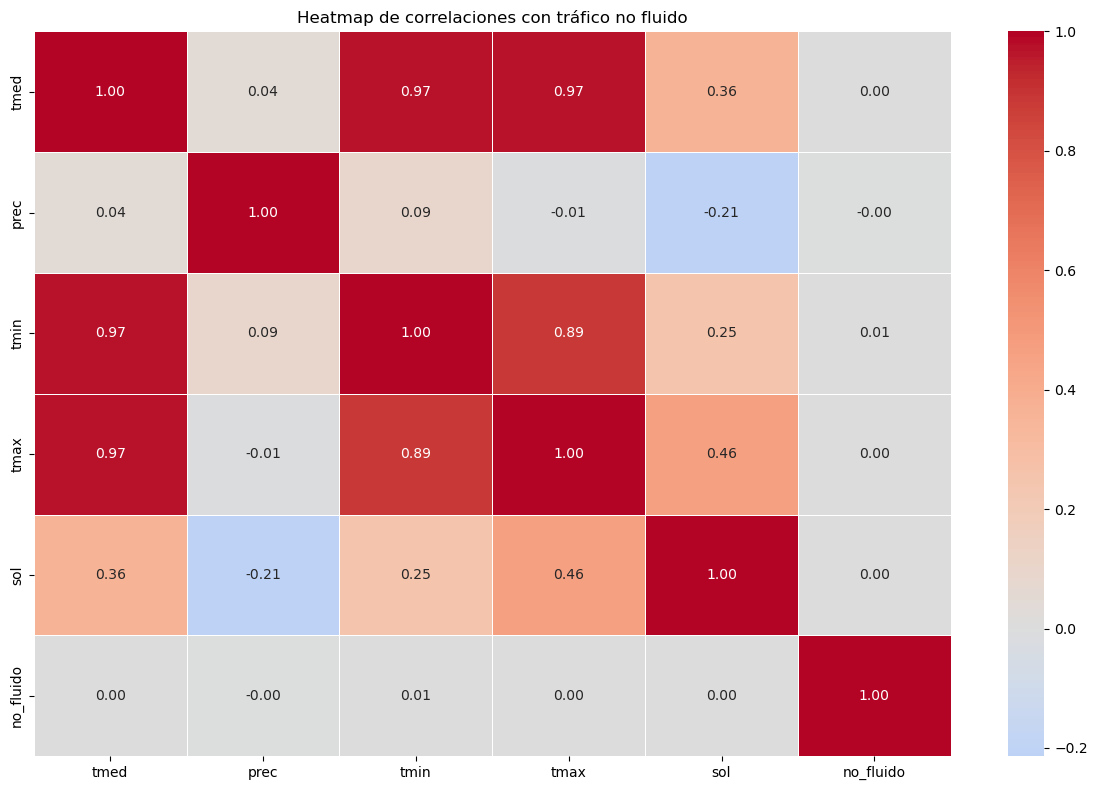


--- CORRELACIÓN CON TRÁFICO NO FLUIDO ---
no_fluido    1.000000
tmin         0.005426
tmed         0.004604
tmax         0.003406
sol          0.003104
prec        -0.002994
Name: no_fluido, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================
# PREPARACIÓN
# =============================================================

df = pd.read_csv("dataset_final.csv")

df['fecha'] = pd.to_datetime(df['fecha'])

# 0 = fluido
# 1 = no fluido (Estado 1,2,3)
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# =============================================================
# VARIABLES NUMÉRICAS
# =============================================================

variables = [
    'tmed',
    'prec',
    'tmin',
    'tmax',
    'sol',
    'no_fluido'
]

# =============================================================
# MATRIZ DE CORRELACIÓN
# =============================================================

corr_matrix = df[variables].corr()

# =============================================================
# HEATMAP
# =============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap de correlaciones con tráfico no fluido')
plt.tight_layout()
plt.show()

# =============================================================
# CORRELACIONES SOLO CON no_fluido
# =============================================================

print("\n--- CORRELACIÓN CON TRÁFICO NO FLUIDO ---")

corr_no_fluido = (
    corr_matrix['no_fluido']
    .sort_values(ascending=False)
)

print(corr_no_fluido)

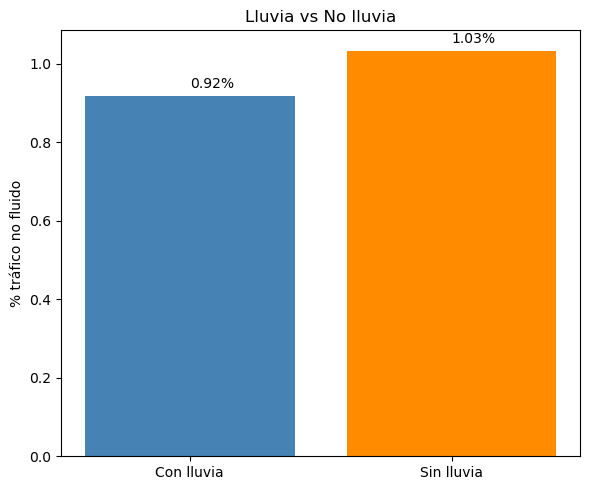

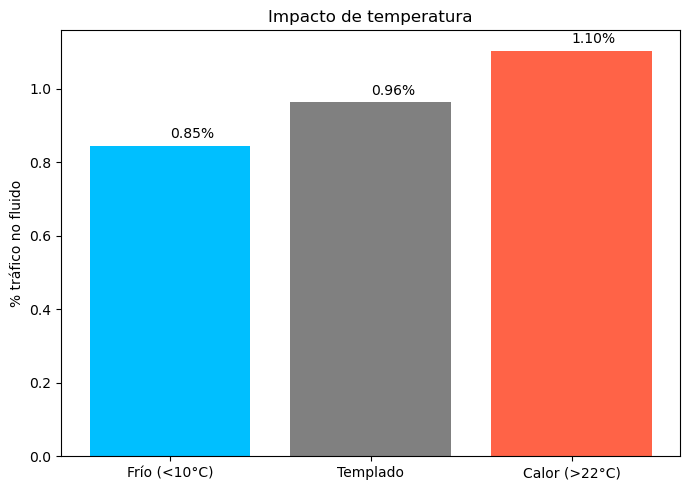

C:\Users\vicen\AppData\Local\Temp\ipykernel_18104\1895398812.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


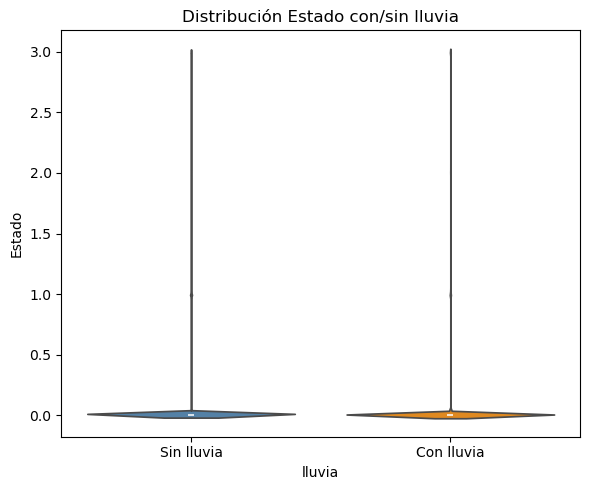

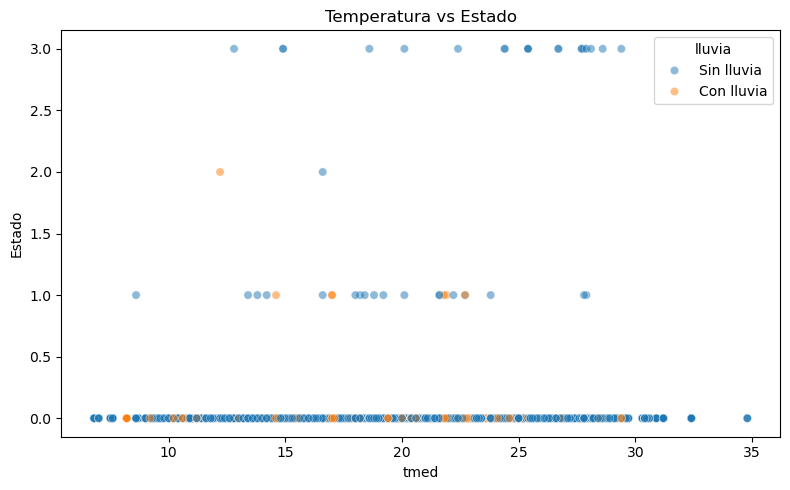

<Figure size 700x500 with 0 Axes>

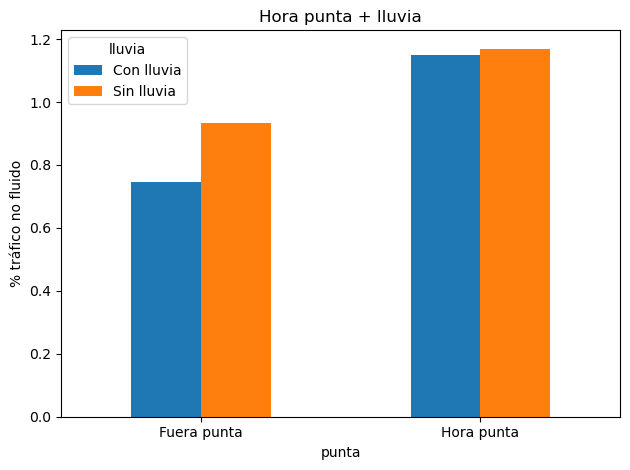

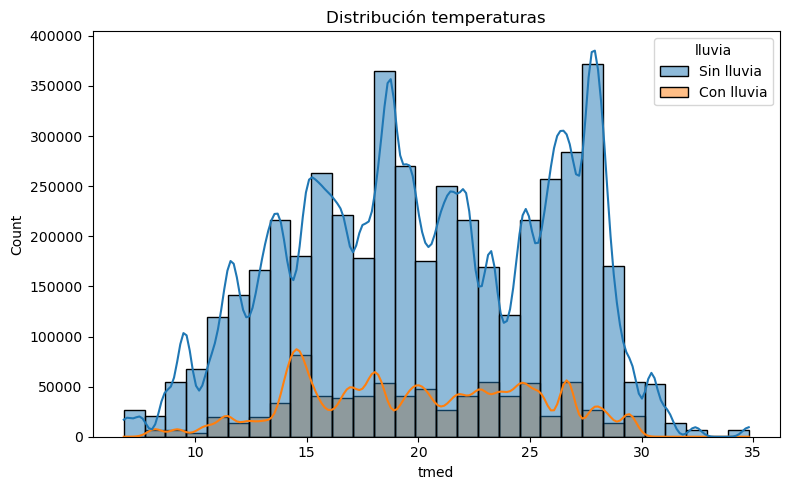

<Figure size 800x500 with 0 Axes>

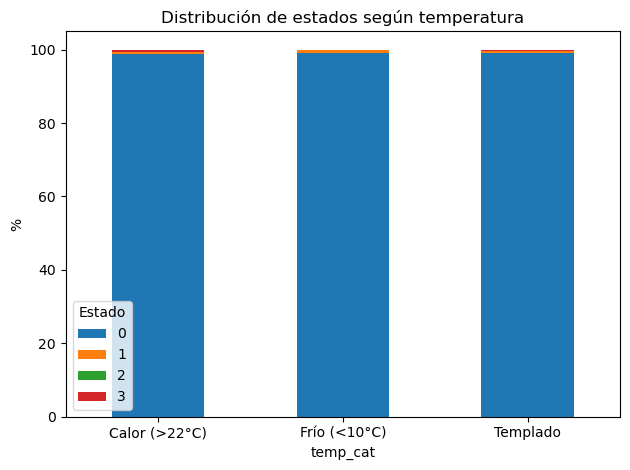

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =============================================================
# CARGA
# =============================================================

df = pd.read_csv("dataset_final.csv")

df['fecha'] = pd.to_datetime(df['fecha'])
df['hora_num'] = pd.to_datetime(df['hora'], format='%H:%M:%S').dt.hour

# =============================================================
# VARIABLES
# =============================================================

df['no_fluido'] = (df['Estado'] > 0).astype(int)

df['lluvia'] = np.where(df['prec'] > 0,
                        'Con lluvia',
                        'Sin lluvia')

df['temp_cat'] = np.select(
    [
        df['tmed'] < 10,
        df['tmed'] > 22
    ],
    [
        'Frío (<10°C)',
        'Calor (>22°C)'
    ],
    default='Templado'
)

df['punta'] = np.where(
    df['hora_num'].isin([7,8,9,14,15,16]),
    'Hora punta',
    'Fuera punta'
)

# =============================================================
# 1. LLUVIA VS NO LLUVIA
# =============================================================

plt.figure(figsize=(6,5))

lluvia_stats = df.groupby('lluvia')['no_fluido'].mean() * 100

plt.bar(
    lluvia_stats.index,
    lluvia_stats.values,
    color=['steelblue', 'darkorange']
)

plt.ylabel('% tráfico no fluido')
plt.title('Lluvia vs No lluvia')

for i, v in enumerate(lluvia_stats.values):
    plt.text(i, v + 0.02, f'{v:.2f}%')

plt.tight_layout()
plt.show()

# =============================================================
# 2. TEMPERATURA
# =============================================================

plt.figure(figsize=(7,5))

temp_stats = df.groupby('temp_cat')['no_fluido'].mean() * 100
orden = ['Frío (<10°C)', 'Templado', 'Calor (>22°C)']

temp_stats = temp_stats.reindex(orden)

plt.bar(
    temp_stats.index,
    temp_stats.values,
    color=['deepskyblue', 'gray', 'tomato']
)

plt.ylabel('% tráfico no fluido')
plt.title('Impacto de temperatura')

for i, v in enumerate(temp_stats.values):
    plt.text(i, v + 0.02, f'{v:.2f}%')

plt.tight_layout()
plt.show()

# =============================================================
# 3. ESTADO SEGÚN LLUVIA
# =============================================================

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x='lluvia',
    y='Estado',
    palette=['steelblue', 'darkorange']
)

plt.title('Distribución Estado con/sin lluvia')

plt.tight_layout()
plt.show()

# =============================================================
# 4. TEMPERATURA VS ESTADO
# =============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(min(5000, len(df))),
    x='tmed',
    y='Estado',
    hue='lluvia',
    alpha=0.5
)

plt.title('Temperatura vs Estado')

plt.tight_layout()
plt.show()

# =============================================================
# 5. HORA PUNTA + LLUVIA
# =============================================================

tabla = (
    df.groupby(['punta', 'lluvia'])['no_fluido']
    .mean()
    .unstack() * 100
)

plt.figure(figsize=(7,5))

tabla.plot(kind='bar')

plt.ylabel('% tráfico no fluido')
plt.title('Hora punta + lluvia')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# =============================================================
# 6. DISTRIBUCIÓN TEMPERATURA
# =============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tmed',
    hue='lluvia',
    bins=30,
    kde=True
)

plt.title('Distribución temperaturas')

plt.tight_layout()
plt.show()

# =============================================================
# 7. ESTADOS POR TEMPERATURA
# =============================================================

tabla_estado = pd.crosstab(
    df['temp_cat'],
    df['Estado'],
    normalize='index'
) * 100

plt.figure(figsize=(8,5))

tabla_estado.plot(
    kind='bar',
    stacked=True
)

plt.ylabel('%')
plt.title('Distribución de estados según temperatura')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

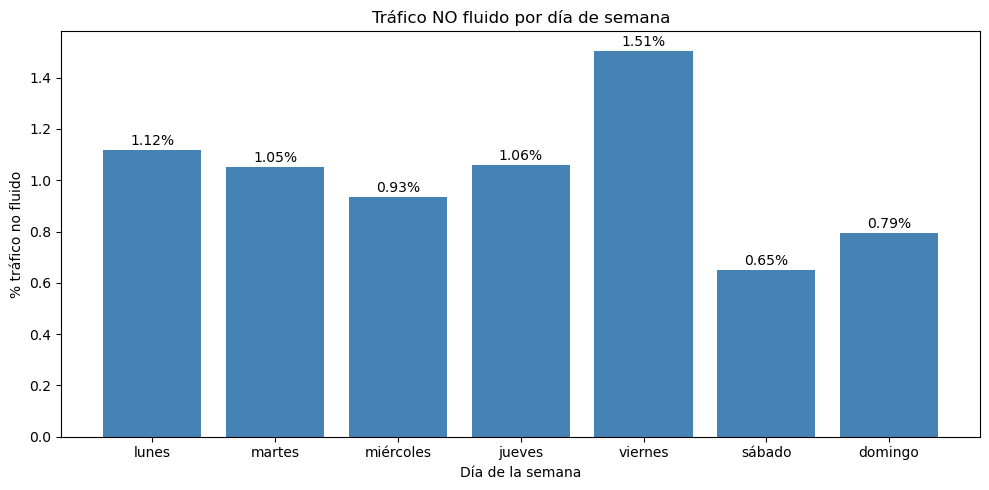

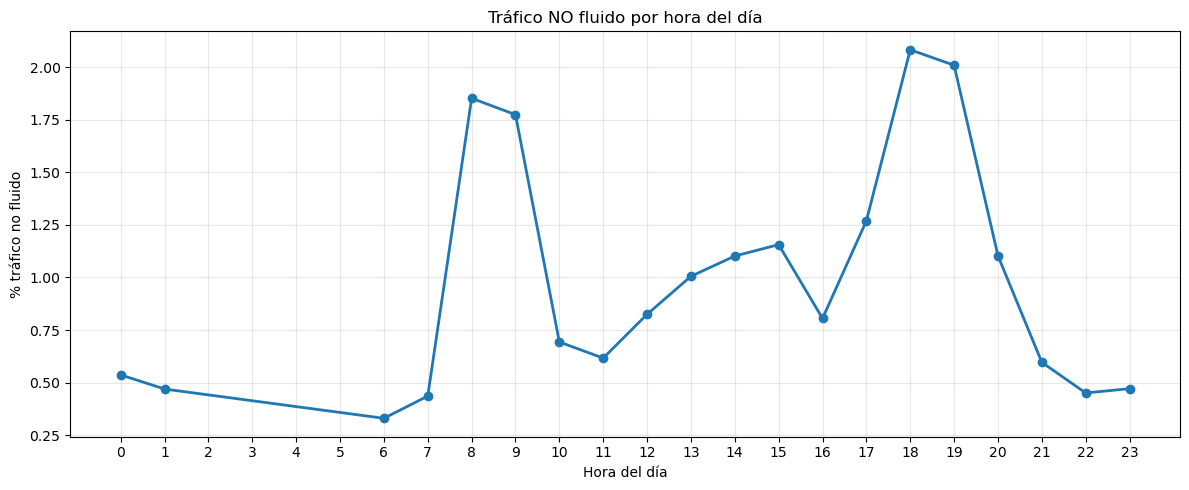

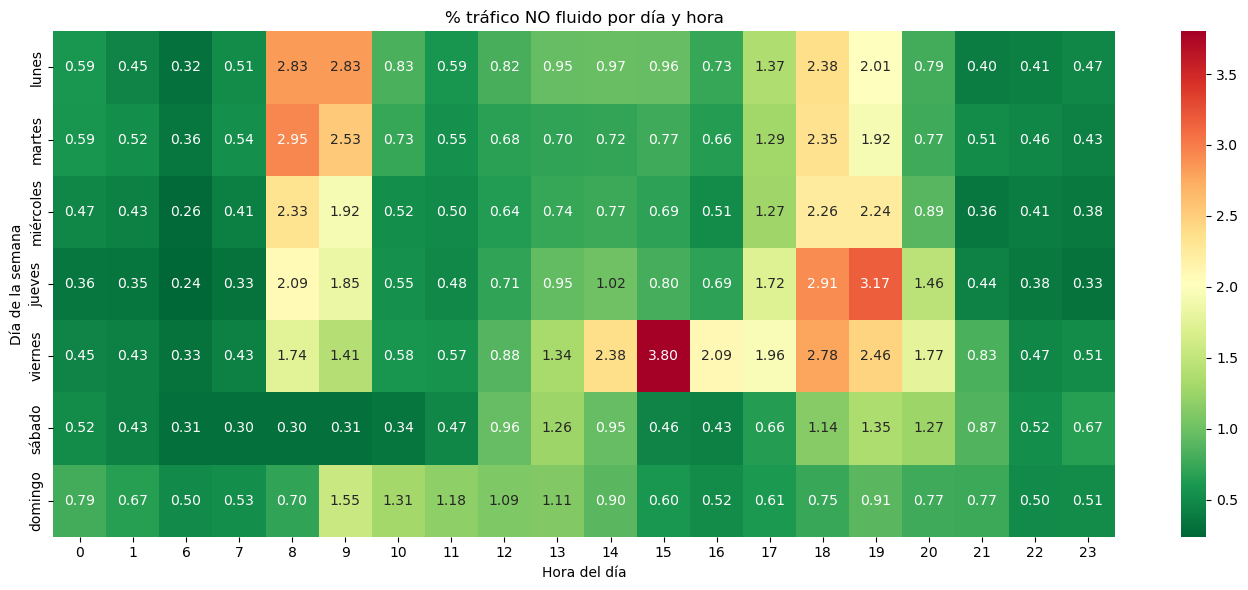

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================
# PREPARACIÓN
# =============================================================

# Variable binaria:
# 0 = fluido
# 1 = no fluido
df['no_fluido'] = (df['Estado'] > 0).astype(int)

# Crear hora_num si no existe
if 'hora_num' not in df.columns:
    df['hora_num'] = pd.to_datetime(
        df['hora'],
        format='%H:%M:%S'
    ).dt.hour

# =============================================================
# LIMPIEZA DÍAS SEMANA
# =============================================================

df['Day_of_week'] = (
    df['Day_of_week']
    .str.lower()
    .replace({
        'miercoles': 'miércoles',
        'sabado': 'sábado'
    })
)

# Orden correcto
orden_dias = [
    'lunes',
    'martes',
    'miércoles',
    'jueves',
    'viernes',
    'sábado',
    'domingo'
]

# =============================================================
# 1. TRÁFICO NO FLUIDO POR DÍA SEMANA
# =============================================================

dia_stats = (
    df.groupby('Day_of_week')['no_fluido']
    .mean()
    .reindex(orden_dias) * 100
)

plt.figure(figsize=(10,5))

plt.bar(
    dia_stats.index,
    dia_stats.values,
    color='steelblue'
)

plt.ylabel('% tráfico no fluido')
plt.xlabel('Día de la semana')

plt.title('Tráfico NO fluido por día de semana')

for i, v in enumerate(dia_stats.values):
    plt.text(i, v + 0.02, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

# =============================================================
# 2. TRÁFICO NO FLUIDO POR HORA
# =============================================================

hora_stats = (
    df.groupby('hora_num')['no_fluido']
    .mean() * 100
)

plt.figure(figsize=(12,5))

plt.plot(
    hora_stats.index,
    hora_stats.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(0,24))

plt.xlabel('Hora del día')
plt.ylabel('% tráfico no fluido')

plt.title('Tráfico NO fluido por hora del día')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================
# 3. HEATMAP DÍA vs HORA
# =============================================================

tabla_heatmap = pd.pivot_table(
    df,
    values='no_fluido',
    index='Day_of_week',
    columns='hora_num',
    aggfunc='mean'
).reindex(orden_dias) * 100

plt.figure(figsize=(14,6))

sns.heatmap(
    tabla_heatmap,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.2f'
)

plt.title('% tráfico NO fluido por día y hora')

plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# CORRELACIÓN POR ESTACIÓN DEL AÑO
# =============================================================

df["no_fluido"] = (df["Estado"] > 0).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

df["season"] = df["fecha"].dt.month.apply(get_season)
por_dia["season"] = por_dia["fecha"].dt.month.apply(get_season)

print("\n--- % tráfico no fluido por estación ---")
season_summary = df.groupby("season")["no_fluido"].mean().mul(100).round(3)
print(season_summary)

print("\n--- CORRELACIONES por estación con % tráfico no fluido ---")
vars_clima = ["tmed", "tmin", "tmax", "prec", "sol"]

for season in ["winter", "spring", "summer", "autumn"]:
    subset = por_dia[por_dia["season"] == season]

    print(f"\n{season.upper()}")
    for v in vars_clima:
        r = subset[v].corr(subset["pct_no_fluido"])
        print(f"  {v:<8}: {r:+.4f}")


--- % tráfico no fluido por estación ---
season
autumn    1.227
spring    1.053
summer    0.955
winter    0.833
Name: no_fluido, dtype: float64

--- CORRELACIONES por estación con % tráfico no fluido ---

WINTER
  tmed    : -0.0115
  tmin    : +0.0548
  tmax    : -0.0736
  prec    : +0.0512
  sol     : +0.0558

SPRING
  tmed    : -0.1840
  tmin    : -0.1645
  tmax    : -0.1635
  prec    : +0.0487
  sol     : -0.0992

SUMMER
  tmed    : +0.1675
  tmin    : +0.1324
  tmax    : +0.1646
  prec    : -0.0599
  sol     : +0.1422

AUTUMN
  tmed    : +0.1411
  tmin    : +0.1322
  tmax    : +0.1321
  prec    : -0.0930
  sol     : +0.0962


MODEL TRAINING

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Selected features (11):
['estado_lag_4', 'Denominació / Denominación', 'hour_sin', 'hour_cos', 'tmed', 'week_of_year', 'Day_of_week', 'School_holiday', 'Mascletá/Crida', 'is_weekend', 'is_night']

After resampling: 200000 rows
Estado_binary
0    100000
1    100000
Name: count, dtype: int64

TRAINING MULTIPLE MODELS

----------------------------------------------------------------------------------------------------
Training model: LightGBM_cw5
----------------------------------------------------------------------------------------------------

Best result:
Threshold:          0.95
Macro F1:           0.7914
Precision minority: 0.5996
Recall minority:    0.5802
F1 minority:        0.5897
Confusion matrix:
[[1236149    8262]
 [   8951   12372]]

----------------------------------------------------------------------------------------------------
Training model: LightGBM_c

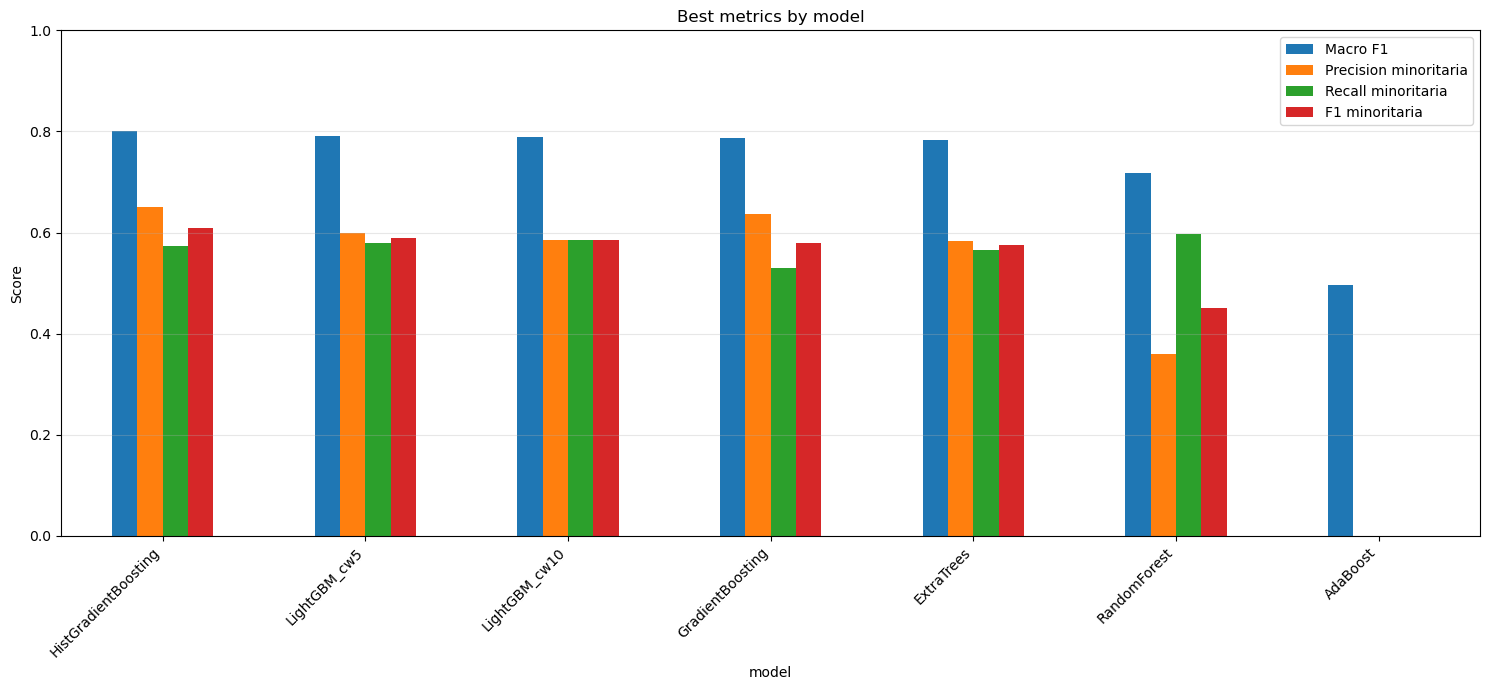

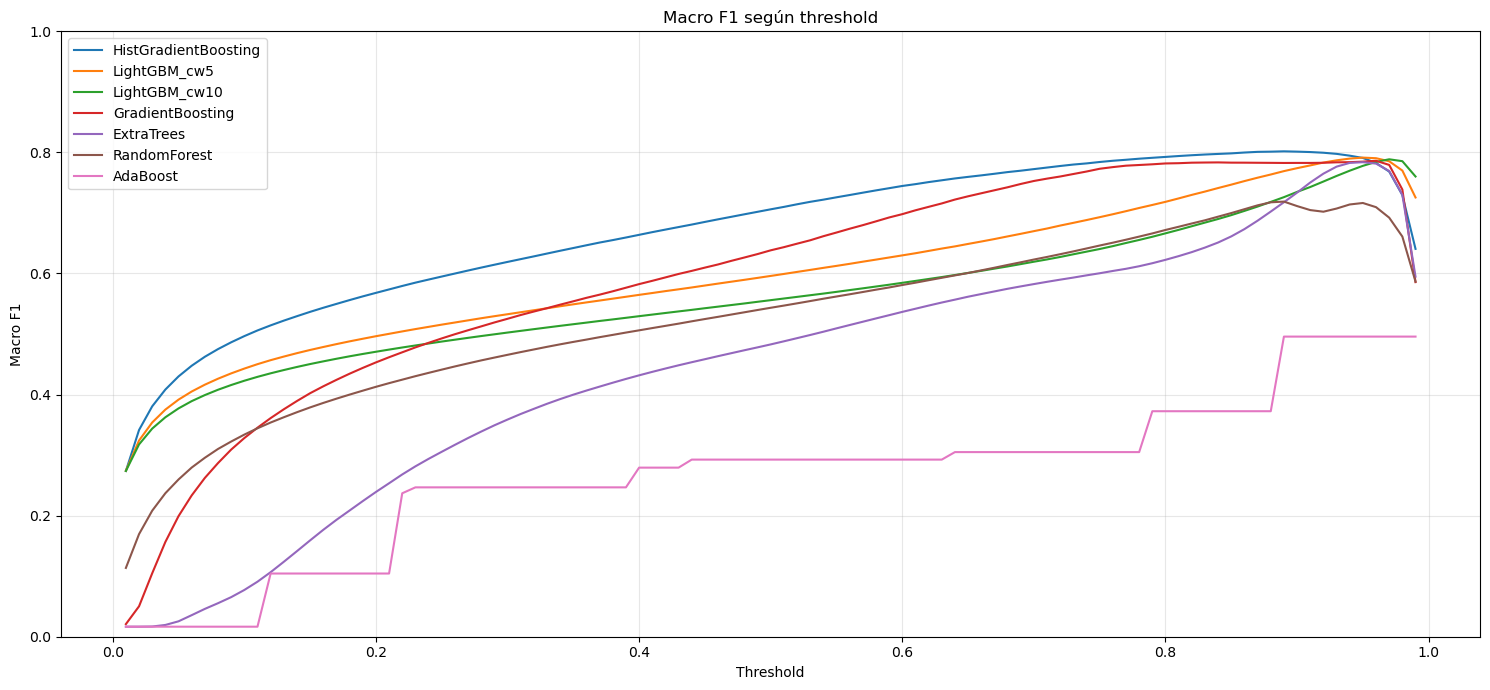

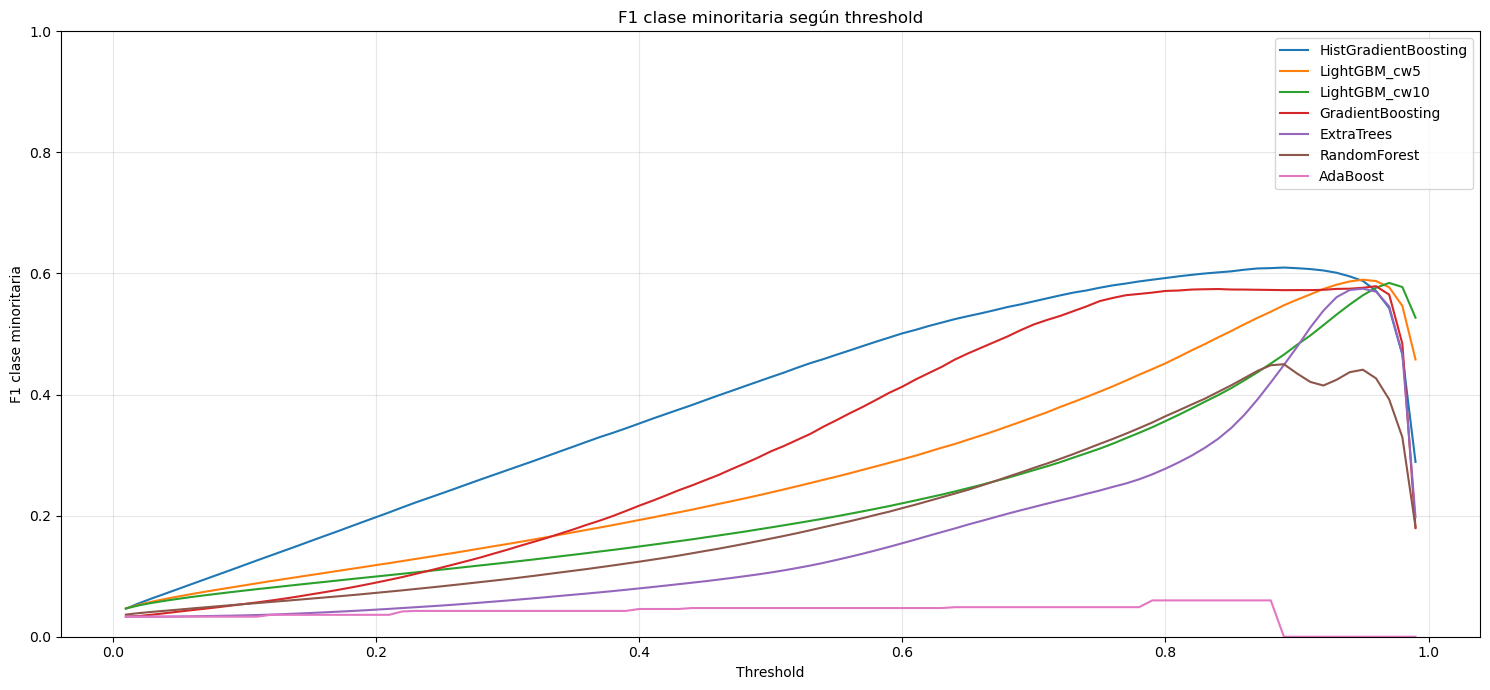

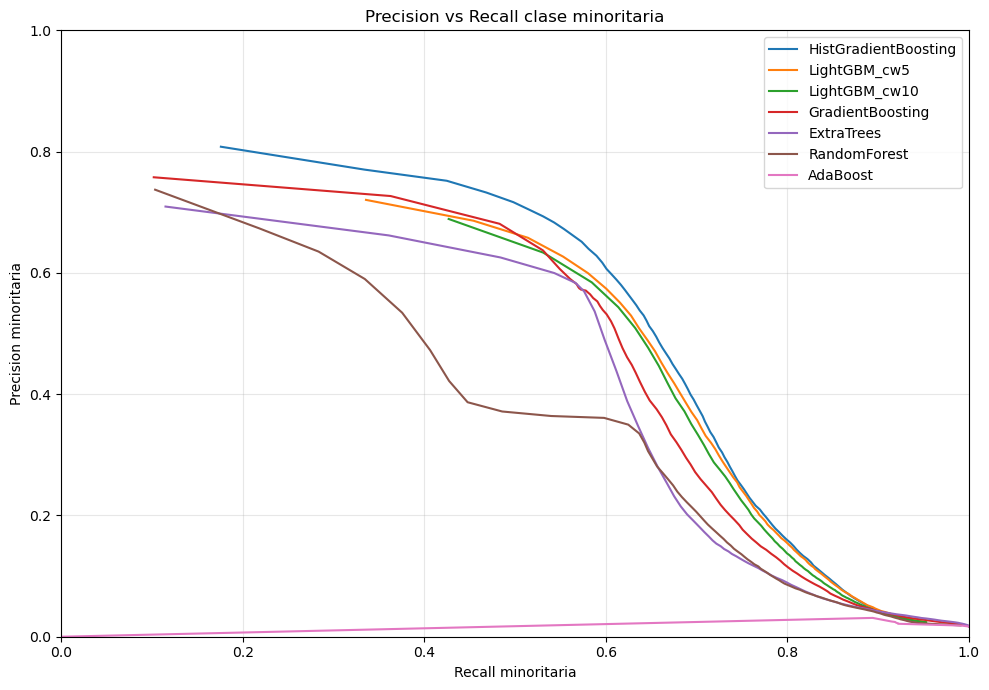


BEST MODEL: HistGradientBoosting
model                 HistGradientBoosting
threshold                             0.89
macro_f1                          0.801775
weighted_f1                       0.987254
accuracy                          0.987642
precision_minority                0.651356
recall_minority                   0.573278
f1_minority                       0.609828
precision_majority                0.992703
recall_majority                   0.994742
f1_majority                       0.993722
tn                                 1237868
fp                                    6543
fn                                    9099
tp                                   12224


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. Create lag_4
# ─────────────────────────────────────────────

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. Train / test split
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. Feature engineering
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["week_of_year"] = (
        df["fecha"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["is_weekend"] = (
        df["fecha"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. Encode categorical
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. Selected features
# ─────────────────────────────────────────────

selected_features = [
    "estado_lag_4",
    "Denominació / Denominación",
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
    "Day_of_week",
    "School_holiday",
    "Mascletá/Crida",
    "is_weekend",
    "is_night",
]

selected_features = [
    f for f in selected_features
    if f in train_df.columns
]

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]


# ─────────────────────────────────────────────
# 7. Scaling
# ─────────────────────────────────────────────

continuous_cols = [
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. Resampling
# ─────────────────────────────────────────────

TARGET_SAMPLES = 100000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. Models
# ─────────────────────────────────────────────

models = {
    "LightGBM_cw5": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=5,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw10": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=10,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=50,
            class_weight={0: 1, 1: 5},
            random_state=42
        ),
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=50,
        subsample=0.8,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. Thresholds 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. Train and evaluate
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING MULTIPLE MODELS")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1": f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

            "weighted_f1": f1_score(
                y_test,
                y_pred,
                average="weighted"
            ),

            "accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        all_results.append(result)

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1"].idxmax()
    ]

    print("\nBest result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1:           {best_row['macro_f1']:.4f}")
    print(f"Precision minority: {best_row['precision_minority']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority']:.4f}")
    print("Confusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. Results DataFrames
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 RESULTS ALL MODELS + THRESHOLDS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1", ascending=False)
)

print("\n" + "=" * 100)
print("BEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. Plot best metrics by model
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best metrics by model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision minoritaria",
    "Recall minoritaria",
    "F1 minoritaria",
])

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. Plot Macro F1 by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1"],
        label=model_name
    )

plt.title("Macro F1 según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 15. Plot F1 minority by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority"],
        label=model_name
    )

plt.title("F1 clase minoritaria según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 clase minoritaria")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 16. Precision vs Recall minority
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 7))

for model_name in results_df["model"].unique():
    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority"],
        tmp["precision_minority"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria")
plt.xlabel("Recall minoritaria")
plt.ylabel("Precision minoritaria")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 17. Feature importance best model
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": selected_features,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df["importance_pct"] = (
        importance_df["importance"]
        / importance_df["importance"].sum()
    )

    print("\n" + "=" * 100)
    print("FEATURE IMPORTANCE")
    print("=" * 100)

    print(importance_df.to_string(index=False))

MODEL TRAINING

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ALL features (39):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MODELS WITH ALL FEATURES

----------------------------------------------------------------------------------------------------
Training model: LightGBM_cw1
-------------------------------------------

c:\Users\vicen\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best TEST result:
Threshold:          0.97
Macro F1 test:      0.7825
Weighted F1 test:   0.9856
Accuracy test:      0.9856
Precision minority: 0.5736
Recall minority:    0.5708
F1 minority:        0.5722
Confusion matrix:
[[1235364    9047]
 [   9151   12172]]

----------------------------------------------------------------------------------------------------
Training model: DecisionTree
----------------------------------------------------------------------------------------------------

Best TEST result:
Threshold:          0.99
Macro F1 test:      0.7527
Weighted F1 test:   0.9848
Accuracy test:      0.9860
Precision minority: 0.6229
Recall minority:    0.4352
F1 minority:        0.5124
Confusion matrix:
[[1238794    5617]
 [  12044    9279]]

----------------------------------------------------------------------------------------------------
Training model: KNN
----------------------------------------------------------------------------------------------------

Best TEST result:


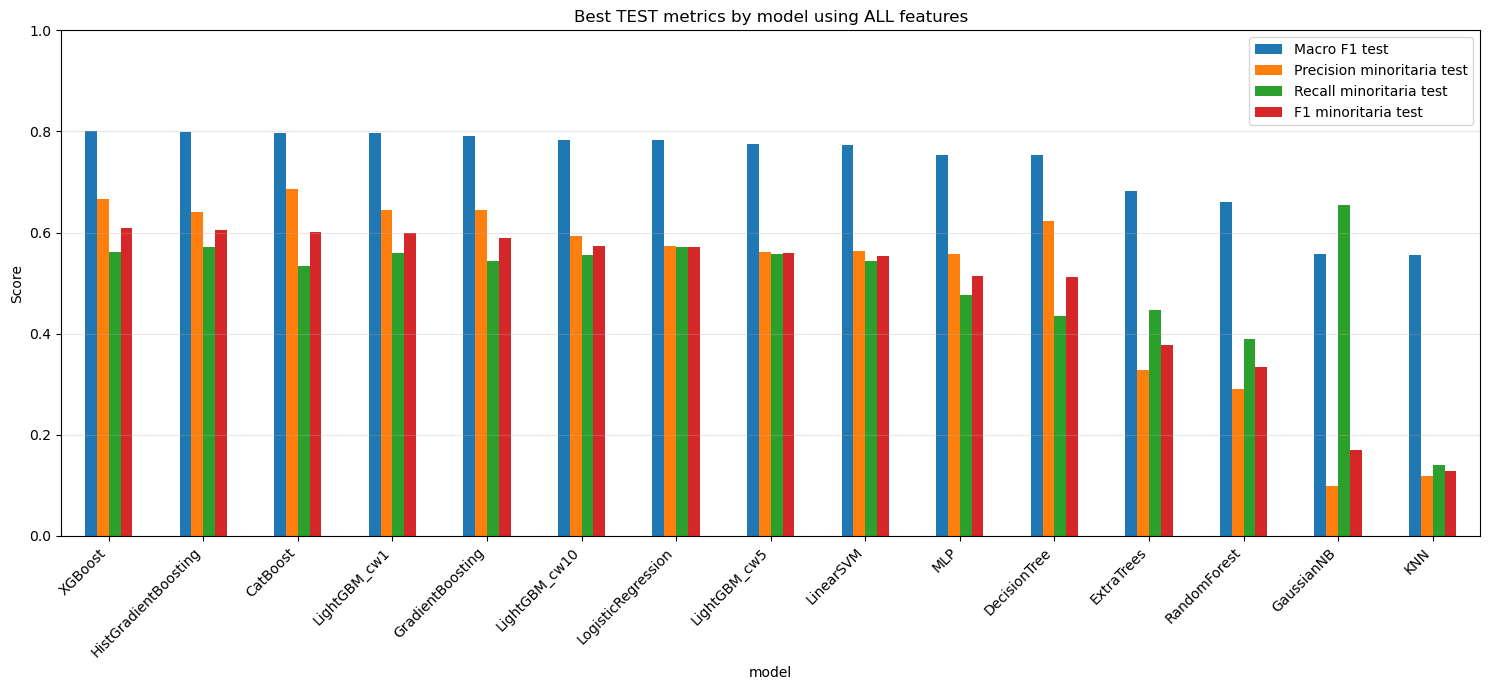

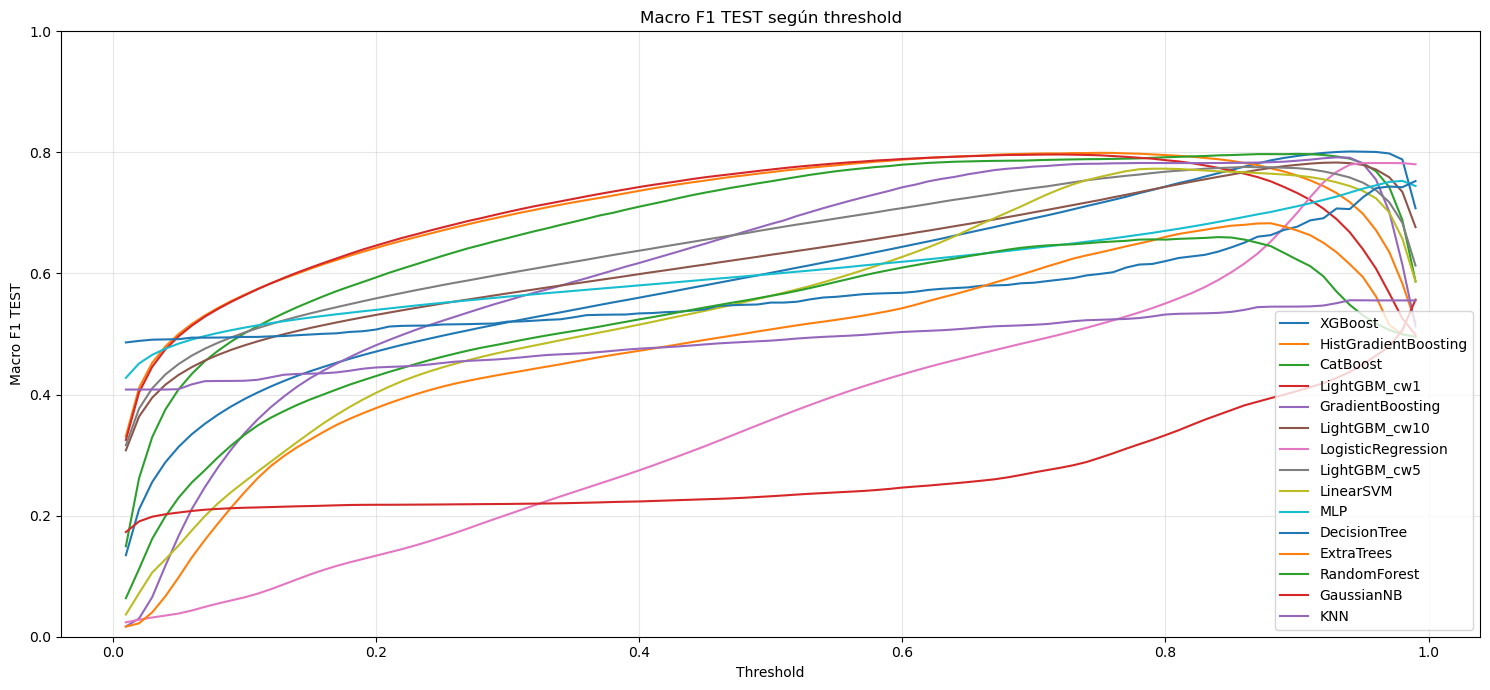

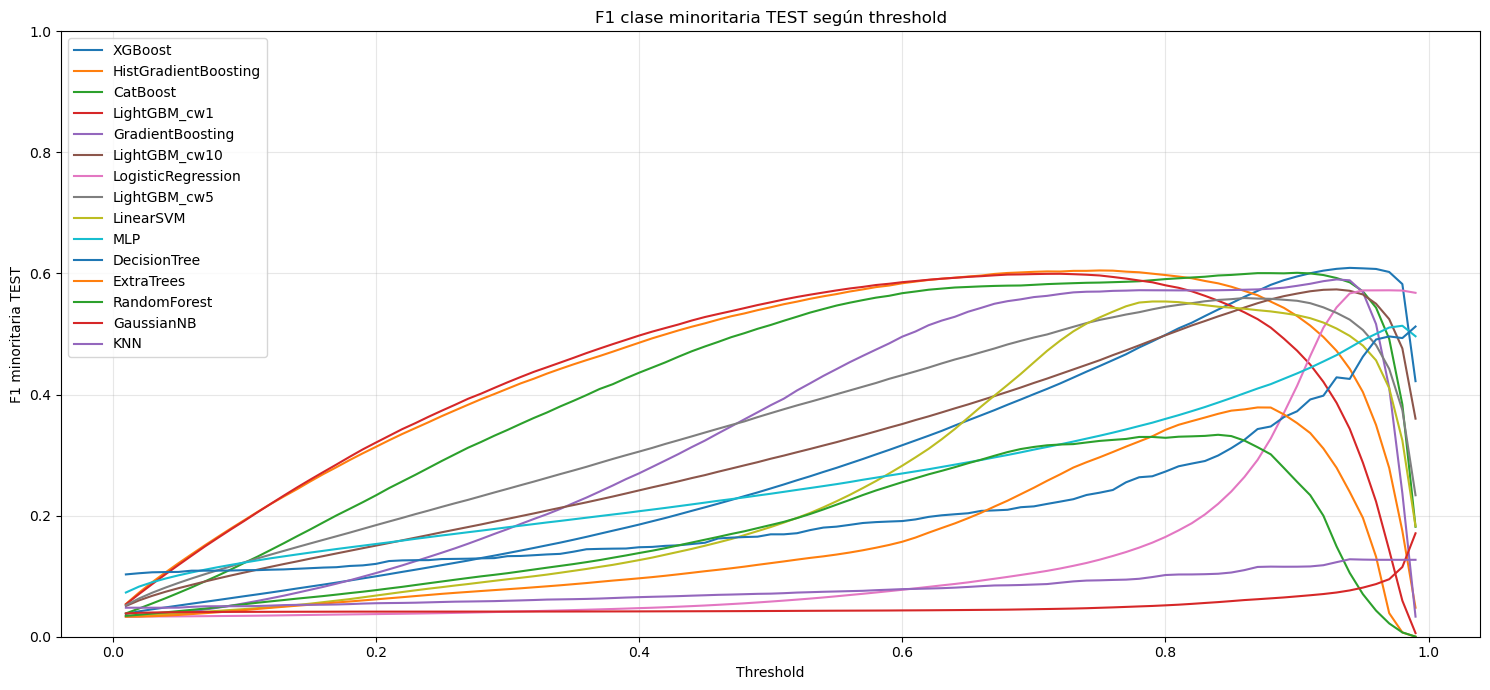

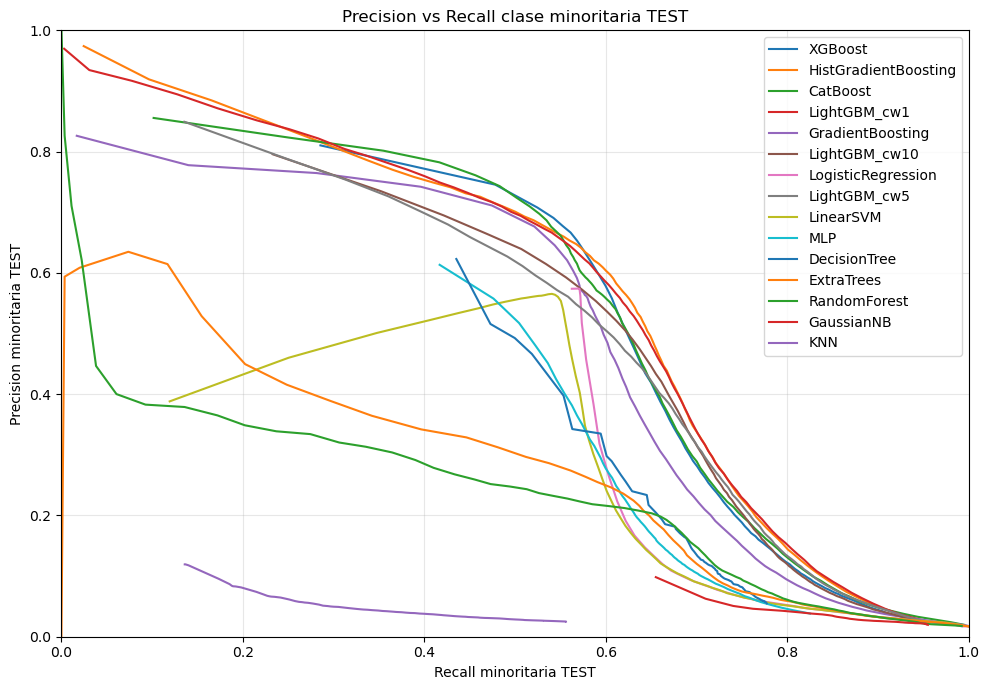


BEST TEST MODEL: XGBoost
model                       XGBoost
threshold                      0.94
macro_f1_test              0.801558
weighted_f1_test           0.987364
accuracy_test              0.987877
precision_minority_test    0.666518
recall_minority_test       0.561084
f1_minority_test           0.609274
precision_majority_test      0.9925
recall_majority_test        0.99519
f1_majority_test           0.993843
tn                          1238425
fp                             5986
fn                             9359
tp                            11964

FEATURE IMPORTANCE BEST MODEL
                   feature  importance  importance_pct
              estado_lag_4    0.249643        0.249643
                  is_night    0.101569        0.101569
            School_holiday    0.052944        0.052944
            Mascletá/Crida    0.043052        0.043052
                  hour_cos    0.040604        0.040604
                  hour_sin    0.035315        0.035315
            Public

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. Create lag_4
# ─────────────────────────────────────────────

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. Train / test split
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. Feature engineering
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = (
        df["fecha"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["is_weekend"] = (
        df["fecha"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. Encode categorical
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. Use ALL features
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. Scaling
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. Resampling train only
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. Models
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 9. MODELS (AMPLIADOS)
# ─────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {

    # =========================================================
    # LIGHTGBM
    # =========================================================

    "LightGBM_cw1": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=1,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw5": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=5,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    "LightGBM_cw10": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=10,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    ),

    # =========================================================
    # XGBOOST
    # =========================================================

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=5,
        random_state=42,
        n_jobs=-1
    ),

    # =========================================================
    # CATBOOST
    # =========================================================

    "CatBoost": CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        random_state=42
    ),

    # =========================================================
    # HIST GRADIENT BOOSTING
    # =========================================================

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    # =========================================================
    # EXTRA TREES
    # =========================================================

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # RANDOM FOREST
    # =========================================================

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight={0: 1, 1: 5},
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # GRADIENT BOOSTING
    # =========================================================

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=50,
        subsample=0.8,
        random_state=42
    ),

    # =========================================================
    # LOGISTIC REGRESSION
    # =========================================================

    "LogisticRegression": LogisticRegression(
        class_weight={0: 1, 1: 5},
        max_iter=3000,
        n_jobs=-1,
        random_state=42
    ),

    # =========================================================
    # DECISION TREE
    # =========================================================

    "DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=20,
        class_weight={0: 1, 1: 5},
        random_state=42
    ),

    # =========================================================
    # KNN
    # =========================================================

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),

    # =========================================================
    # NAIVE BAYES
    # =========================================================

    "GaussianNB": GaussianNB(),

    # =========================================================
    # MLP
    # =========================================================

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        random_state=42
    ),

    # =========================================================
    # LINEAR SVM
    # =========================================================

    "LinearSVM": CalibratedClassifierCV(
        LinearSVC(
            class_weight={0: 1, 1: 5},
            random_state=42,
            max_iter=5000
        )
    ),
}



# ─────────────────────────────────────────────
# 10. Thresholds 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. Train and evaluate on TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING MODELS WITH ALL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        all_results.append(result)

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("Confusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. Results table
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. Plot best metrics by model
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics by model using ALL features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. Macro F1 by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 15. F1 minority by threshold
# ─────────────────────────────────────────────

plt.figure(figsize=(15, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 16. Precision vs Recall minority
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 7))

for model_name in results_df["model"].unique():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 17. Feature importance best model
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df["importance_pct"] = (
        importance_df["importance"] /
        importance_df["importance"].sum()
    )

    print("\n" + "=" * 100)
    print("FEATURE IMPORTANCE BEST MODEL")
    print("=" * 100)

    print(importance_df.to_string(index=False))


FEATURES USADAS EN EL MODELO
Número de features: 39
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

FEATURES USADAS EN EL MODELO
Número de features: 39
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Wint

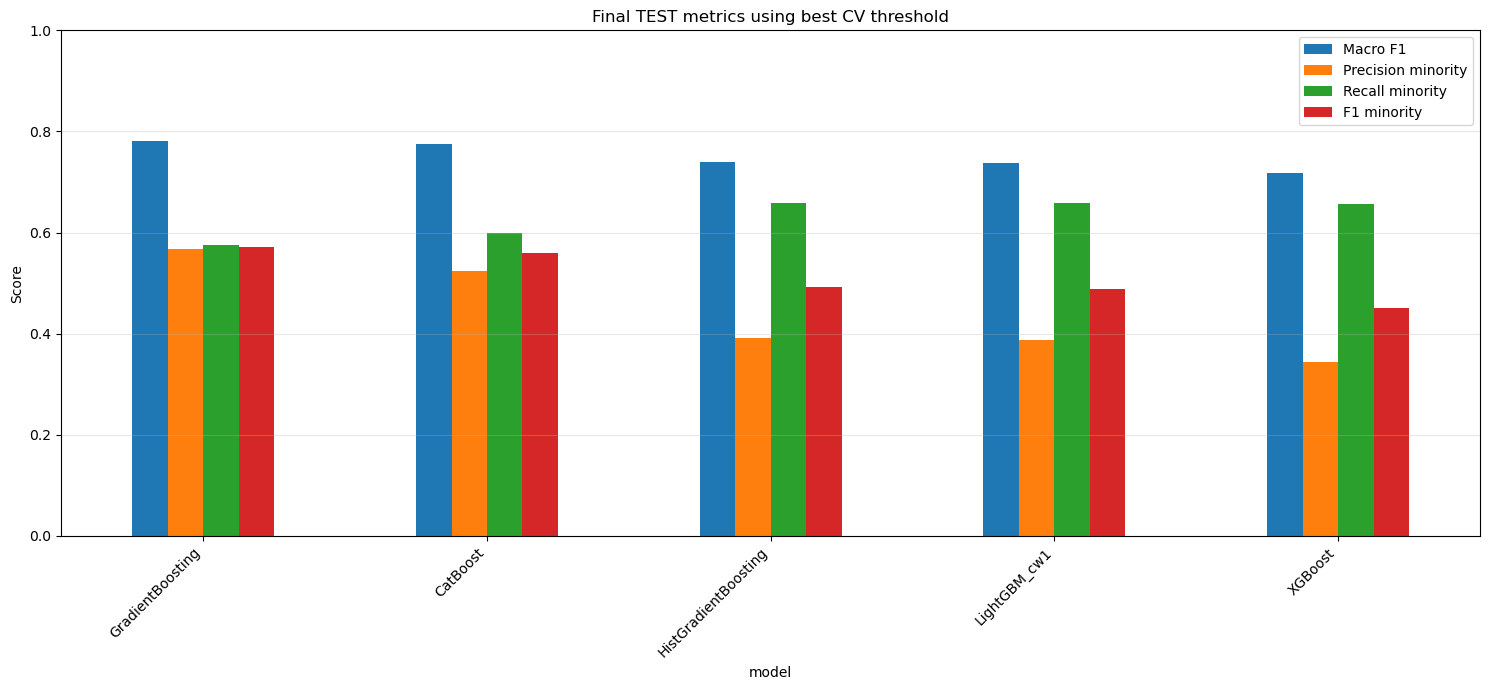

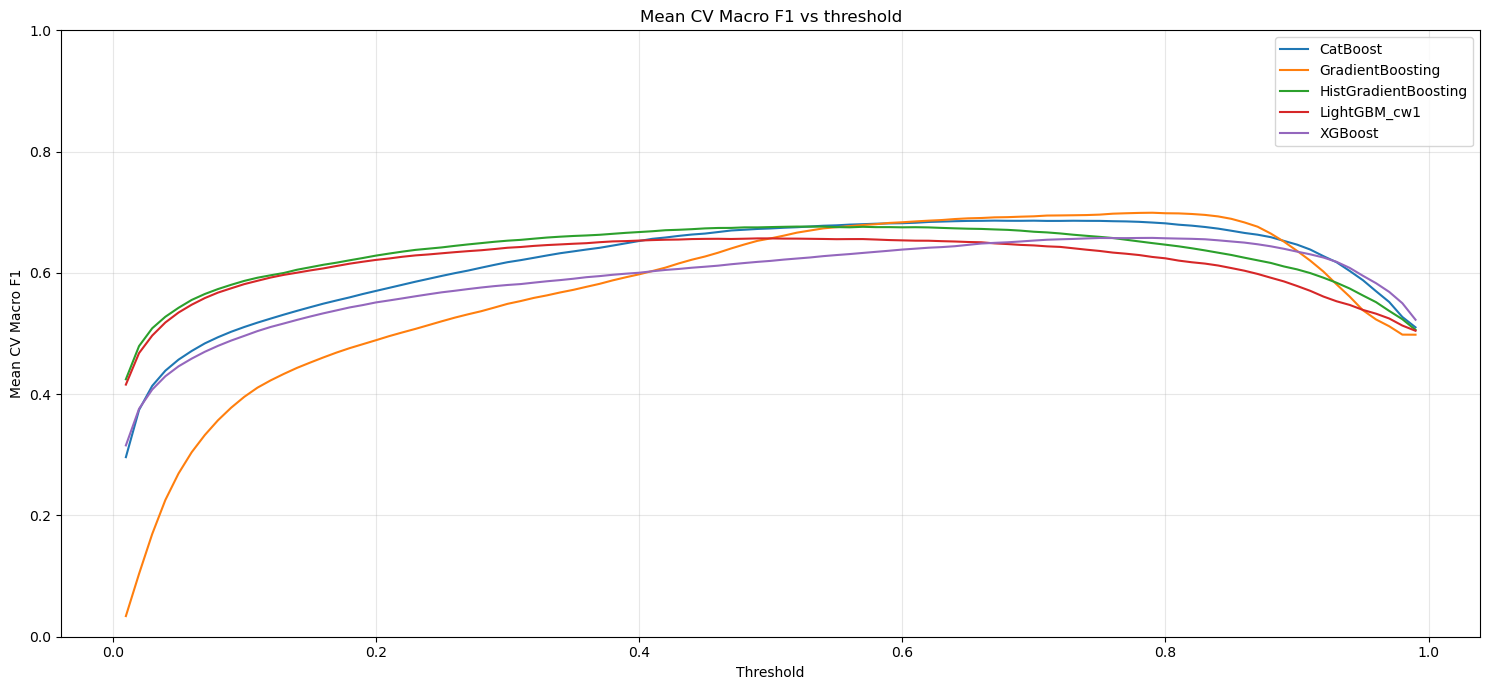

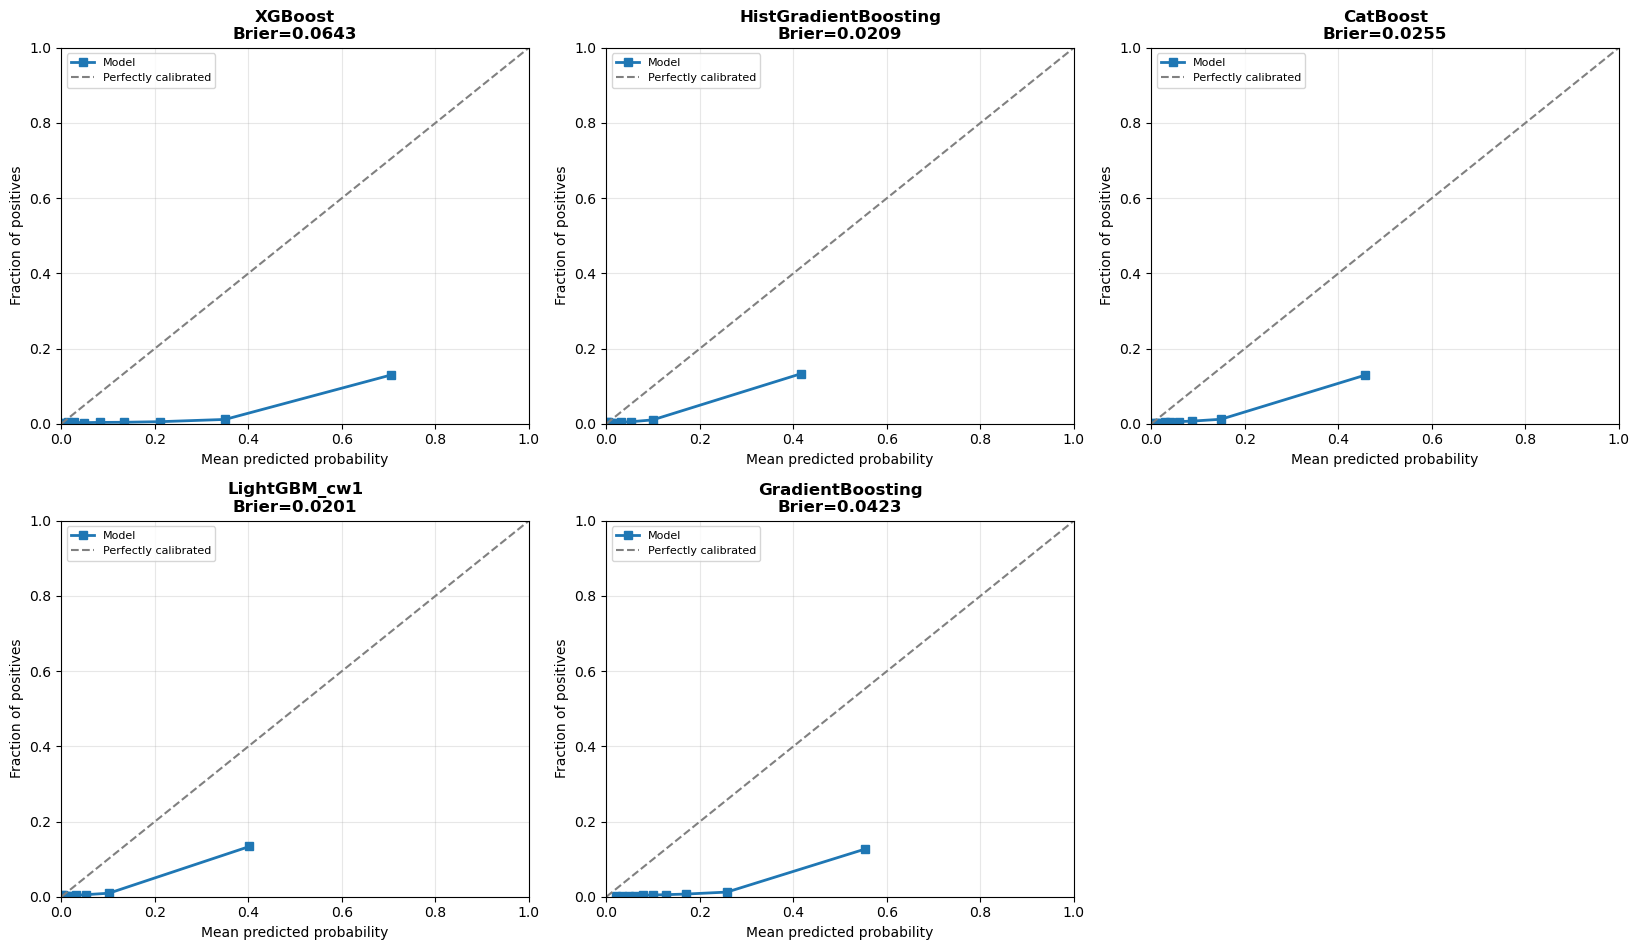


FINAL TEST CALIBRATION
               model  brier_score_test  proba_min  proba_mean  proba_max  n_bins_real
        LightGBM_cw1          0.020110   0.000064    0.063539   0.996841           10
HistGradientBoosting          0.020902   0.000111    0.064747   0.995495           10
            CatBoost          0.025451   0.000071    0.086556   0.999004           10
    GradientBoosting          0.042346   0.003952    0.145028   0.993241           10
             XGBoost          0.064256   0.000028    0.157968   0.998507           10


In [ ]:
# ─────────────────────────────────────────────
# TIME SERIES CV SOLO PARA MODELOS SELECCIONADOS
# ─────────────────────────────────────────────

from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    brier_score_loss
)

from scipy.special import expit
import math

# =========================================================
# CREAR estado_lag_4 Y USAR TODAS LAS FEATURES EXISTENTES
# =========================================================

# =========================================================
# CREAR estado_lag_4 + FEATURES TEMPORALES + USAR TODAS
# =========================================================

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])
df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)

df["estado_lag_4"] = (
    df.groupby("Denominació / Denominación")["Estado_binary"]
    .shift(4)
)

df = df.dropna(subset=["estado_lag_4"]).reset_index(drop=True)


def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = (
        df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)
    )

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

train_df = add_features(train_df)
test_df = add_features(test_df)

# ENCODE CATEGÓRICAS
le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

# ASEGURAR NUMÉRICAS
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("\n" + "=" * 100)
print("FEATURES USADAS EN EL MODELO")
print("=" * 100)
print(f"Número de features: {len(feature_cols)}")
print(feature_cols)
# =========================================================
# FEATURES USADAS
# =========================================================

print("\n" + "=" * 100)
print("FEATURES USADAS EN EL MODELO")
print("=" * 100)

print(f"Número de features: {len(feature_cols)}")
print(feature_cols)

# =========================================================
# CONFIG
# =========================================================

N_SPLITS = 5
TARGET_SAMPLES = 200000
THRESHOLDS = np.arange(0.01, 1.00, 0.01)

# =========================================================
# SELECT MODELS MANUALLY
# =========================================================

models_original = models.copy()

selected_models = [
    "XGBoost",
    "HistGradientBoosting",
    "CatBoost",
    "LightGBM_cw1",
    "GradientBoosting",
]

models = {
    name: models_original[name]
    for name in selected_models
}

print("\n" + "=" * 100)
print("MODELOS SELECCIONADOS PARA FOLDS")
print("=" * 100)
print(list(models.keys()))

# =========================================================
# TIME SERIES SPLIT
# =========================================================

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# =========================================================
# HELPER
# =========================================================

def get_positive_proba(model, X):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    elif hasattr(model, "decision_function"):
        return expit(model.decision_function(X))

    else:
        proba = model.predict(X)
        proba = np.asarray(proba)

        if proba.ndim == 2:
            proba = proba[:, 1]

        return proba

# =========================================================
# CV TRAINING
# =========================================================

cv_results = []

print("\n" + "=" * 100)
print("TIME SERIES CROSS-VALIDATION")
print("=" * 100)

for model_name, base_model in models.items():

    print("\n" + "-" * 100)
    print(f"CV MODEL: {model_name}")
    print("-" * 100)

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

        print(f"Fold {fold}/{N_SPLITS}")

        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()

        X_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx].copy()

        n_majority = int((y_tr == 0).sum())
        n_minority = int((y_tr == 1).sum())

        target_fold = min(TARGET_SAMPLES, n_majority)

        sampler = ImbPipeline(steps=[
            (
                "undersample",
                RandomUnderSampler(
                    sampling_strategy={0: target_fold},
                    random_state=42
                )
            ),
            (
                "oversample",
                SMOTE(
                    sampling_strategy={1: target_fold},
                    random_state=42,
                    k_neighbors=min(5, max(1, n_minority - 1))
                )
            ),
        ])

        X_tr_res, y_tr_res = sampler.fit_resample(X_tr, y_tr)

        model = clone(base_model)
        model.fit(X_tr_res, y_tr_res)

        y_proba_val = get_positive_proba(model, X_val)
        y_proba_val = np.clip(y_proba_val, 0, 1)

        for threshold in THRESHOLDS:

            y_pred_val = (y_proba_val > threshold).astype(int)

            cm = confusion_matrix(
                y_val,
                y_pred_val,
                labels=[0, 1]
            )

            report = classification_report(
                y_val,
                y_pred_val,
                target_names=["fluido(0)", "no_fluido(1)"],
                output_dict=True,
                zero_division=0
            )

            cv_results.append({
                "model": model_name,
                "fold": fold,
                "threshold": round(float(threshold), 2),

                "macro_f1_val": f1_score(
                    y_val,
                    y_pred_val,
                    average="macro"
                ),

                "weighted_f1_val": f1_score(
                    y_val,
                    y_pred_val,
                    average="weighted"
                ),

                "accuracy_val": accuracy_score(
                    y_val,
                    y_pred_val
                ),

                "precision_minority_val":
                    report["no_fluido(1)"]["precision"],

                "recall_minority_val":
                    report["no_fluido(1)"]["recall"],

                "f1_minority_val":
                    report["no_fluido(1)"]["f1-score"],

                "tn": int(cm[0, 0]),
                "fp": int(cm[0, 1]),
                "fn": int(cm[1, 0]),
                "tp": int(cm[1, 1]),
            })

# =========================================================
# CV RESULTS
# =========================================================

cv_results_df = pd.DataFrame(cv_results)

cv_summary = (
    cv_results_df
    .groupby(["model", "threshold"], as_index=False)
    .agg(
        macro_f1_val_mean=("macro_f1_val", "mean"),
        macro_f1_val_std=("macro_f1_val", "std"),
        weighted_f1_val_mean=("weighted_f1_val", "mean"),
        accuracy_val_mean=("accuracy_val", "mean"),
        precision_minority_val_mean=("precision_minority_val", "mean"),
        recall_minority_val_mean=("recall_minority_val", "mean"),
        f1_minority_val_mean=("f1_minority_val", "mean"),
    )
)

best_cv_by_model = (
    cv_summary
    .sort_values("macro_f1_val_mean", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_val_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("BEST CV RESULT BY MODEL")
print("=" * 100)
print(best_cv_by_model.to_string(index=False))

# =========================================================
# FINAL TRAIN ON FULL TRAIN
# =========================================================

final_results = []
trained_models_cv = {}

print("\n" + "=" * 100)
print("FINAL TRAIN 2023-2024 → TEST 2025")
print("=" * 100)

for model_name, base_model in models.items():

    print("\n" + "-" * 100)
    print(f"FINAL MODEL: {model_name}")
    print("-" * 100)

    target_final = min(
        TARGET_SAMPLES,
        int((y_train == 0).sum())
    )

    final_sampler = ImbPipeline(steps=[
        (
            "undersample",
            RandomUnderSampler(
                sampling_strategy={0: target_final},
                random_state=42
            )
        ),
        (
            "oversample",
            SMOTE(
                sampling_strategy={1: target_final},
                random_state=42,
                k_neighbors=min(
                    5,
                    max(1, int((y_train == 1).sum()) - 1)
                )
            )
        ),
    ])

    X_train_res, y_train_res = final_sampler.fit_resample(
        X_train,
        y_train
    )

    model = clone(base_model)

    model.fit(
        X_train_res,
        y_train_res
    )

    trained_models_cv[model_name] = model

    y_proba_test = get_positive_proba(
        model,
        X_test
    )

    y_proba_test = np.clip(
        y_proba_test,
        0,
        1
    )

    best_threshold = float(
        best_cv_by_model.loc[
            best_cv_by_model["model"] == model_name,
            "threshold"
        ].iloc[0]
    )

    y_pred_test = (y_proba_test > best_threshold).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_test,
        labels=[0, 1]
    )

    report = classification_report(
        y_test,
        y_pred_test,
        target_names=["fluido(0)", "no_fluido(1)"],
        output_dict=True,
        zero_division=0
    )

    final_results.append({
        "model": model_name,
        "best_cv_threshold": best_threshold,

        "macro_f1_test": f1_score(
            y_test,
            y_pred_test,
            average="macro"
        ),

        "weighted_f1_test": f1_score(
            y_test,
            y_pred_test,
            average="weighted"
        ),

        "accuracy_test": accuracy_score(
            y_test,
            y_pred_test
        ),

        "precision_minority_test":
            report["no_fluido(1)"]["precision"],

        "recall_minority_test":
            report["no_fluido(1)"]["recall"],

        "f1_minority_test":
            report["no_fluido(1)"]["f1-score"],

        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),

        "brier_test": brier_score_loss(
            y_test,
            y_proba_test
        ),
    })

# =========================================================
# FINAL RESULTS
# =========================================================

final_results_df = (
    pd.DataFrame(final_results)
    .sort_values("macro_f1_test", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FINAL TEST RESULTS")
print("=" * 100)
print(final_results_df.to_string(index=False))

# =========================================================
# PLOT FINAL METRICS
# =========================================================

plot_df = final_results_df.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Final TEST metrics using best CV threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend([
    "Macro F1",
    "Precision minority",
    "Recall minority",
    "F1 minority"
])

plt.tight_layout()
plt.show()

# =========================================================
# PLOT CV MACRO F1 VS THRESHOLD
# =========================================================

plt.figure(figsize=(15, 7))

for model_name in cv_summary["model"].unique():

    tmp = cv_summary[
        cv_summary["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_val_mean"],
        label=model_name
    )

plt.title("Mean CV Macro F1 vs threshold")
plt.xlabel("Threshold")
plt.ylabel("Mean CV Macro F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# CALIBRATION TABLE
# =========================================================

calibration_df = (
    pd.DataFrame(calibration_rows)
    .sort_values("brier_score_test", ascending=True)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FINAL TEST CALIBRATION")
print("=" * 100)
print(calibration_df.to_string(index=False))

LIGHT GBM CON 11 FEATURES

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Selected features (11):
['estado_lag_4', 'Denominació / Denominación', 'hour_sin', 'hour_cos', 'tmed', 'week_of_year', 'Day_of_week', 'School_holiday', 'Mascletá/Crida', 'is_weekend', 'is_night']

After resampling: 200000 rows
Estado_binary
0    100000
1    100000
Name: count, dtype: int64

TRAINING MULTIPLE LIGHTGBM MODELS

------------------------------------------------------------------------------------------
Training LGBM_cw_1
------------------------------------------------------------------------------------------
Best threshold:      0.86
Macro F1:            0.7984
Weighted F1:         0.9871
Accuracy:            0.9875
Precision minority:  0.6509
Recall minority:     0.5618
F1 minority:         0.6031

Confusion matrix:
[[1237987    6424]
 [   9344   11979]]

------------------------------------------------------------------------------------------
Training 

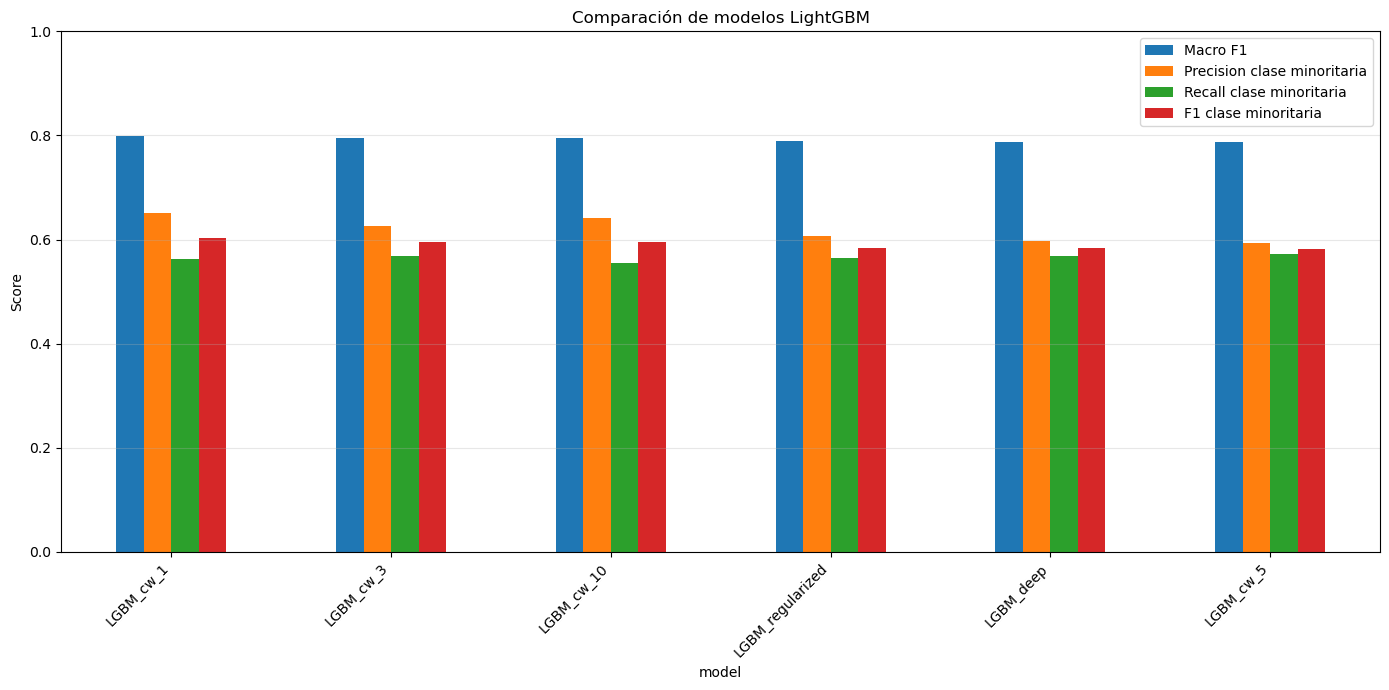


FEATURE IMPORTANCE - BEST MODEL: LGBM_cw_1
                   feature          gain  split  gain_pct
              estado_lag_4 662678.173098    348  0.289395
                  hour_cos 374295.612350   2328  0.163457
Denominació / Denominación 339737.203279   3529  0.148365
                  hour_sin 319844.482227   1918  0.139678
              week_of_year 183110.318634   2516  0.079965
                      tmed 173270.781050   2398  0.075668
            School_holiday  75012.484361    304  0.032758
               Day_of_week  61038.531134   1022  0.026656
                  is_night  38628.110626    187  0.016869
            Mascletá/Crida  34840.894932    143  0.015215
                is_weekend  27419.124341    307  0.011974


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──

selected_features = [
    "estado_lag_4",
    "Denominació / Denominación",
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
    "Day_of_week",
    "School_holiday",
    "Mascletá/Crida",
    "is_weekend",
    "is_night",
]

selected_features = [
    f for f in selected_features
    if f in train_df.columns
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──

continuous_cols = [
    "hour_sin",
    "hour_cos",
    "tmed",
    "week_of_year",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 100000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

LIGHT GBM CON FEATURES Y ESTADO LAG4

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Selected ALL numeric features (39):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Scaled continuous columns (17):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year']

After resampling: 400000 rows
Estado_binary
0    200000
1    2000

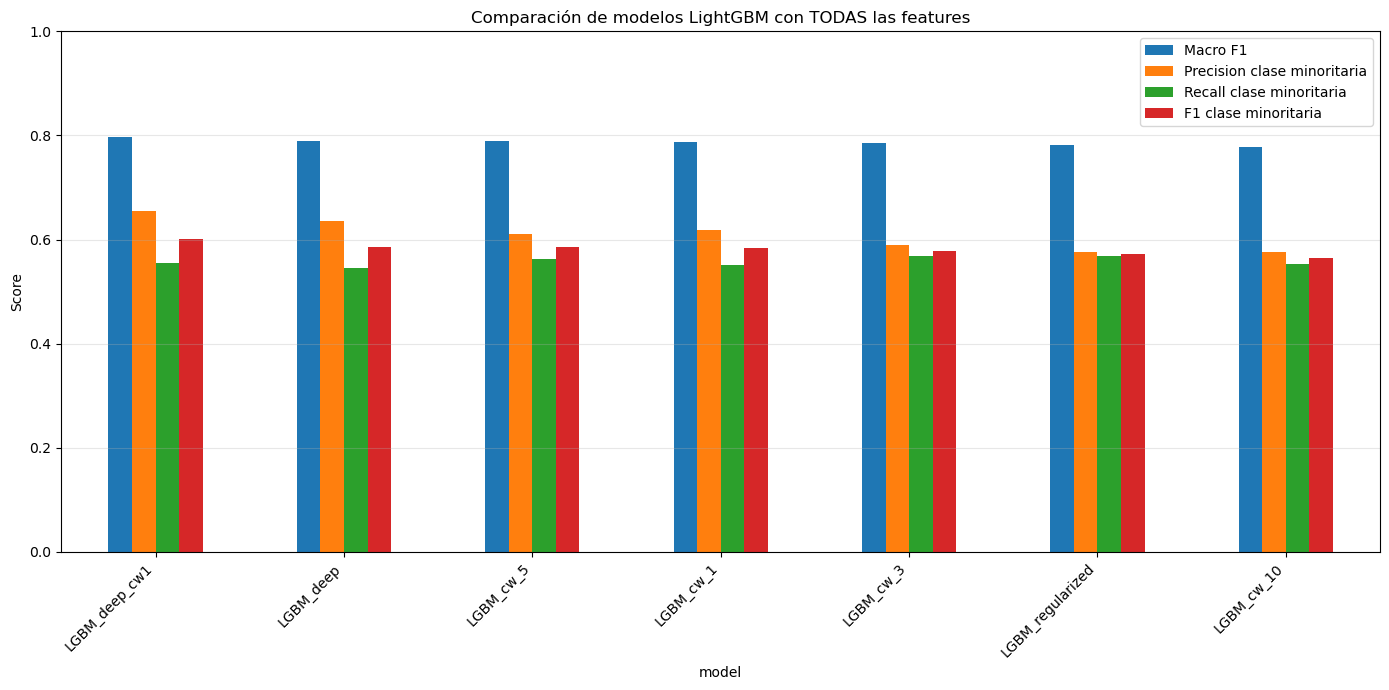


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep_cw1
                   feature         gain  split  gain_pct
              estado_lag_4 2.104746e+06   1038  0.252297
Denominació / Denominación 9.677459e+05  18520  0.116004
                  hour_cos 9.493344e+05   6591  0.113797
                  hour_sin 9.186268e+05   6535  0.110116
                   minutes 8.130395e+05   7534  0.097459
              week_of_year 2.712820e+05   3979  0.032519
                      tmed 2.606695e+05   4762  0.031247
                      tmax 2.527717e+05   4978  0.030300
                      tmin 2.451451e+05   5354  0.029386
            School_holiday 2.360593e+05    844  0.028297
               Day_of_week 1.978822e+05   3702  0.023720
                       sol 1.973796e+05   5770  0.023660
                       day 1.322000e+05   3421  0.015847
            Mascletá/Crida 1.045721e+05    367  0.012535
                   day_cos 9.881205e+04   3007  0.011845
                   day_sin 9.405131e+04 

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# TODAS LAS FEATURES MENOS OBJETIVO Y COLUMNAS NO USABLES DIRECTAMENTE

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

selected_features = [
    c for c in train_df.columns
    if c not in drop_cols
]

# Mantener solo columnas numéricas para LightGBM + SMOTE
selected_features = [
    c for c in selected_features
    if pd.api.types.is_numeric_dtype(train_df[c])
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected ALL numeric features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

LIGHTBGM CON ESTADO LAG_4 SOLO

Creating lag feature estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Selected features (1):
['estado_lag_4']

Scaled continuous columns (0):
[]

After resampling: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MULTIPLE LIGHTGBM MODELS - ONLY estado_lag_4

------------------------------------------------------------------------------------------
Training LGBM_cw_1
------------------------------------------------------------------------------------------
Best threshold:      0.38
Macro F1:            0.7823
Weighted F1:         0.9856
Accuracy:            0.9856
Precision minority:  0.5722
Recall minority:     0.5717
F1 minority:         0.5719

Confusion matrix:
[[1235295    9116]
 [   9132   12191]]

------------------------------------------------------------------------------------------
Training LGBM_cw_3
------------------------------------------------------------------------------------------


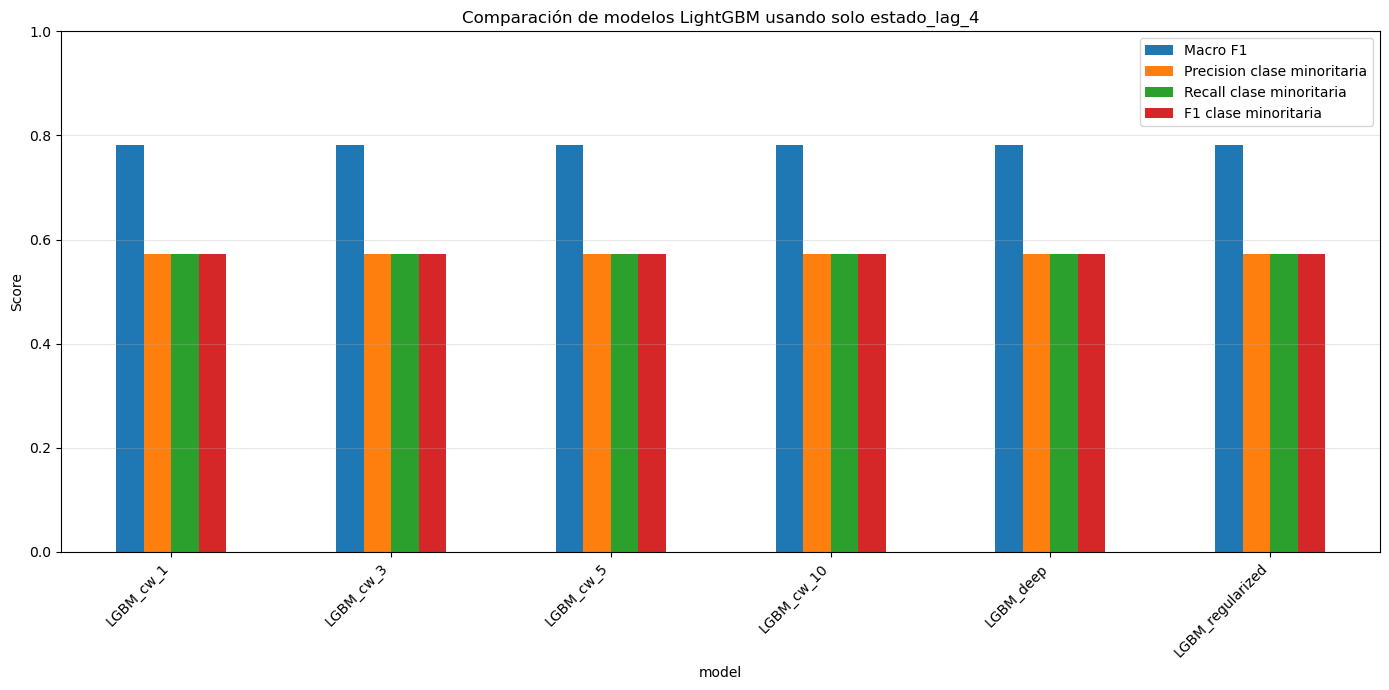


FEATURE IMPORTANCE - BEST MODEL: LGBM_cw_1
     feature         gain  split  gain_pct
estado_lag_4 1.293753e+06    439       1.0


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

print("Creating lag feature estado_lag_4...")

grouped = df.groupby("Denominació / Denominación")

df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Features / target ──

selected_features = ["estado_lag_4"]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)


# ── 5. Scaling ──
# No hace falta escalar porque estado_lag_4 es binaria

continuous_cols = []

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 6. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 7. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 8. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 9. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS - ONLY estado_lag_4")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 1.0,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 10. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON - ONLY estado_lag_4")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 11. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM usando solo estado_lag_4")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 12. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

LIGHTGBM CON MAS TEMPORAL FEATURES

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected ALL numeric features (44):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_nigh

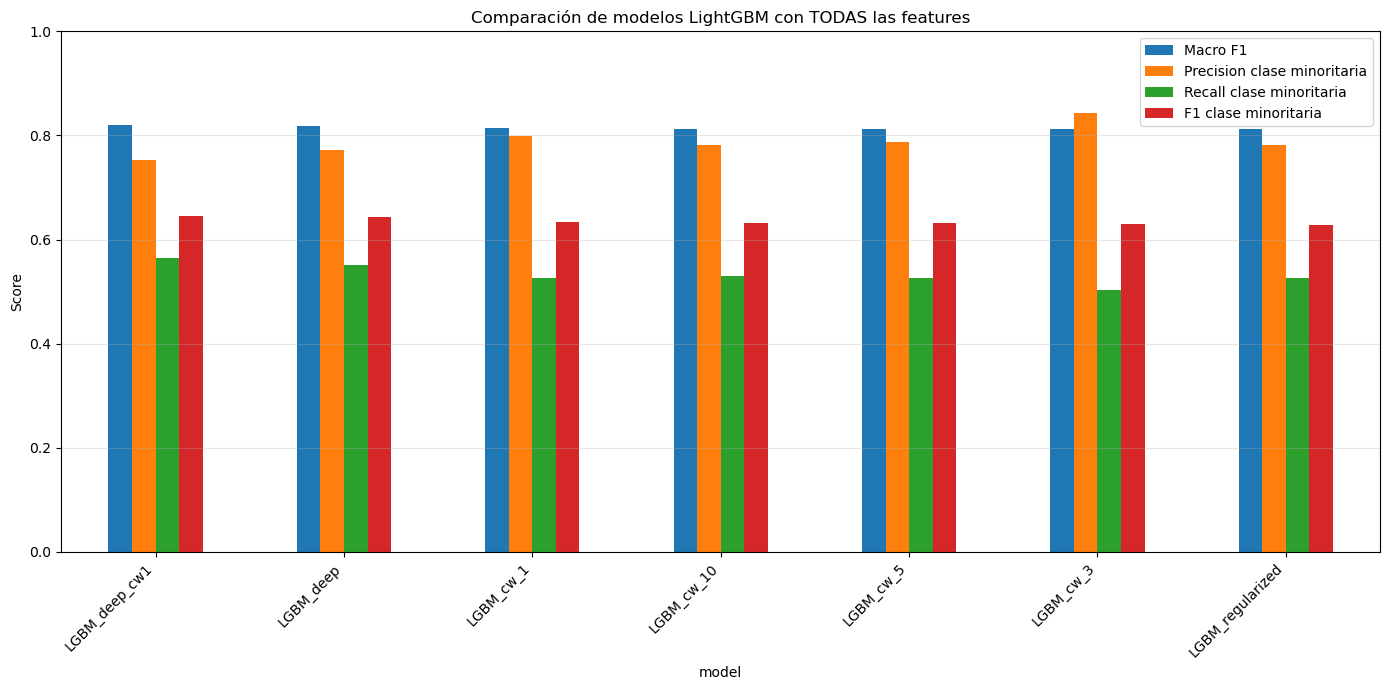


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep_cw1
                    feature         gain  split  gain_pct
 time_since_last_congestion 3.635627e+06   8538  0.425090
                   hour_sin 7.463621e+05   7400  0.087267
      estado_rolling_4_to_8 7.154641e+05    439  0.083655
                   hour_cos 7.009709e+05   6681  0.081960
                    minutes 5.628422e+05   7127  0.065809
 Denominació / Denominación 3.201749e+05  13139  0.037436
               estado_lag_4 1.834306e+05    335  0.021447
                Day_of_week 1.774427e+05   3947  0.020747
               week_of_year 1.345245e+05   3477  0.015729
                       tmax 1.276195e+05   4395  0.014922
                       tmed 1.183851e+05   3697  0.013842
             School_holiday 1.173152e+05    797  0.013717
                        sol 1.027883e+05   4514  0.012018
                       tmin 1.024819e+05   3896  0.011983
                        day 9.668429e+04   3385  0.011305
                    day_

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# TODAS LAS FEATURES MENOS OBJETIVO Y COLUMNAS NO USABLES DIRECTAMENTE

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

selected_features = [
    c for c in train_df.columns
    if c not in drop_cols
]

# Mantener solo columnas numéricas para LightGBM + SMOTE
selected_features = [
    c for c in selected_features
    if pd.api.types.is_numeric_dtype(train_df[c])
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected ALL numeric features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected ONLY time_since_last_congestion (1):
['time_since_last_congestion']

Scaled continuous columns (1):
['time_since_last_congestion']

After resampling: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MULTIPLE LIGHTGBM MODELS

------------------------------------------------------------------------------------------
Training LGBM_cw_1
------------------------------------------------------------------------------------------
Best threshold:      0.94
Macro F1:            0.7823
Weighted F1:         0.9856
Accuracy:            0.9856
Precision minority:  0.5722
Recall minority:     0.5717
F1 minority:         0.5719

Confusion matrix:
[[1235295    9116]
 [

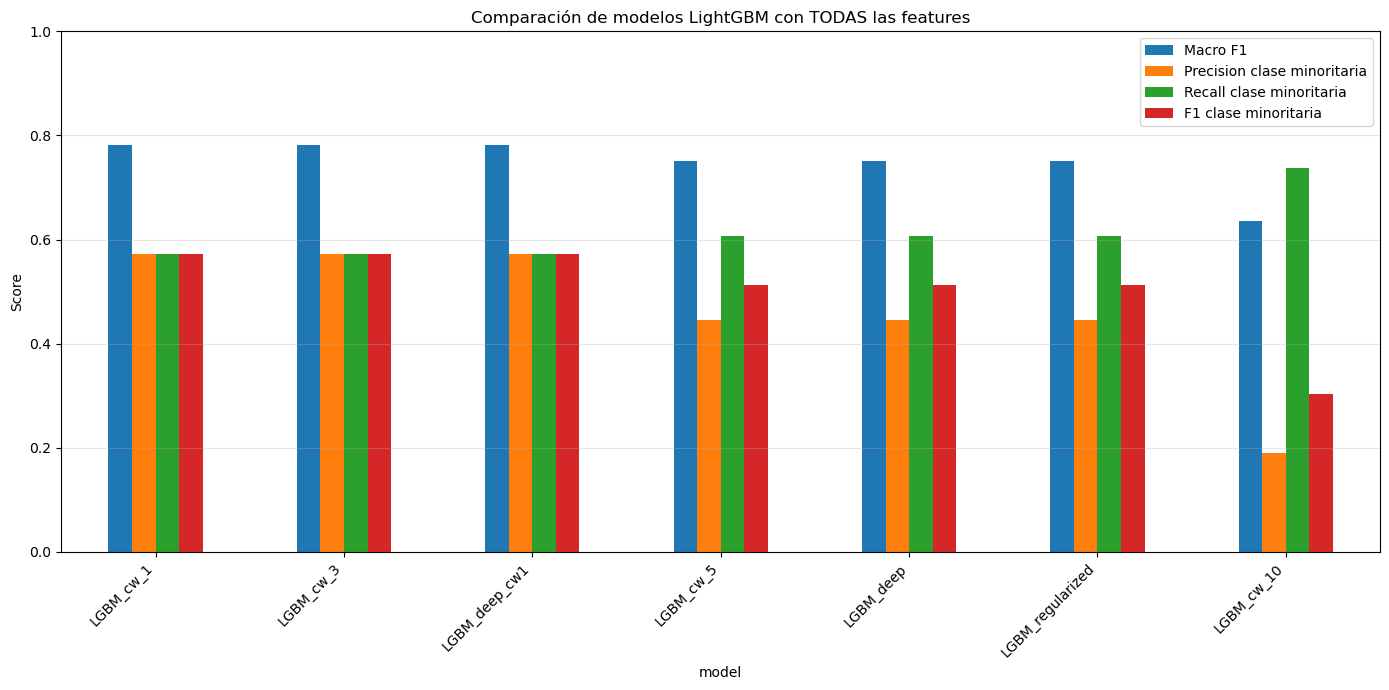


FEATURE IMPORTANCE - BEST MODEL: LGBM_cw_1
                   feature         gain  split  gain_pct
time_since_last_congestion 3.042189e+06  15000       1.0


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# SOLO time_since_last_congestion

selected_features = [
    "time_since_last_congestion"
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected ONLY time_since_last_congestion ({len(selected_features)}):")
print(selected_features)

# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

BACKWARD SELECTION

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected ALL numeric features (44):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_nigh

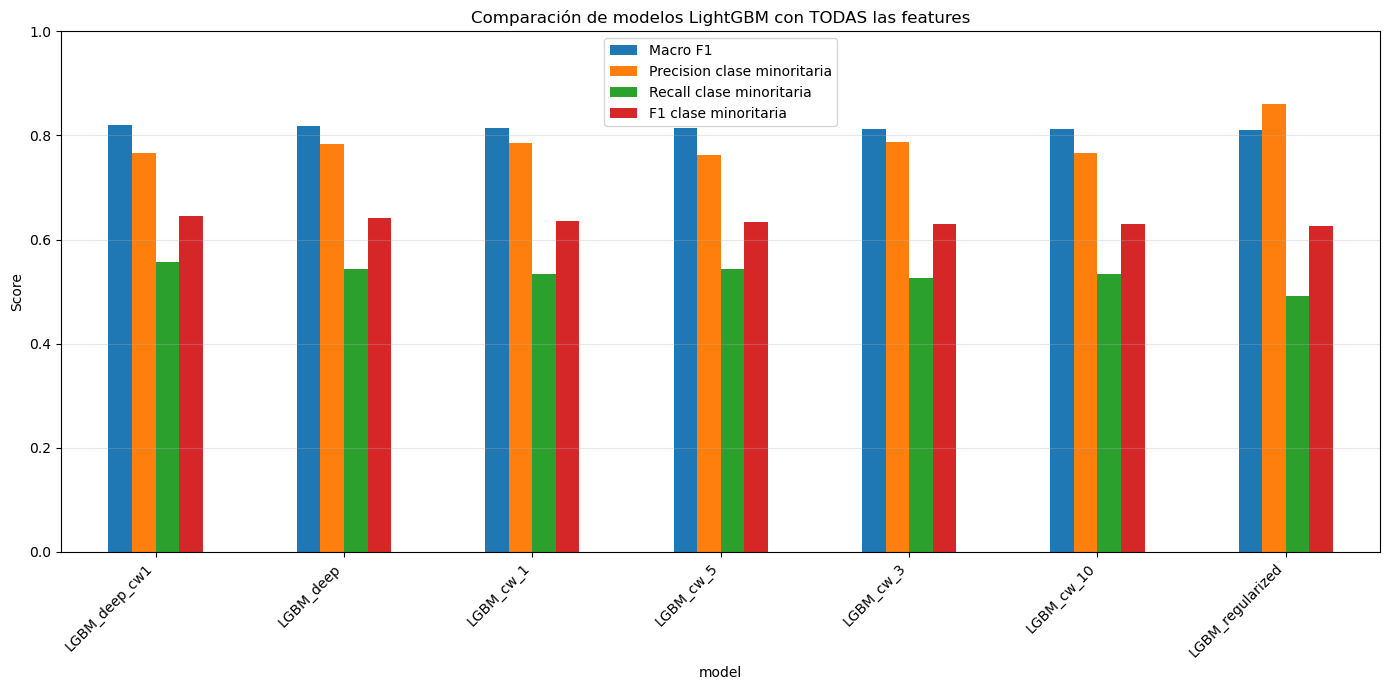


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep_cw1
                    feature         gain  split  gain_pct
 time_since_last_congestion 4.055743e+06   8466  0.474553
                   hour_sin 6.605280e+05   7220  0.077287
                   hour_cos 6.554614e+05   6842  0.076694
                    minutes 5.892935e+05   7263  0.068952
               estado_lag_4 3.306100e+05    313  0.038684
 Denominació / Denominación 3.190795e+05  13114  0.037335
      estado_rolling_4_to_8 3.176801e+05    513  0.037171
                Day_of_week 1.890043e+05   4112  0.022115
               week_of_year 1.425091e+05   3534  0.016675
                       tmed 1.241697e+05   4200  0.014529
                       tmax 1.147003e+05   4452  0.013421
                       tmin 1.134356e+05   4467  0.013273
                        sol 1.117841e+05   5010  0.013080
                        day 1.112043e+05   3449  0.013012
             School_holiday 9.907663e+04    799  0.011593
consecutive_congested_st

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# TODAS LAS FEATURES MENOS OBJETIVO Y COLUMNAS NO USABLES DIRECTAMENTE

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

selected_features = [
    c for c in train_df.columns
    if c not in drop_cols
]

# Mantener solo columnas numéricas para LightGBM + SMOTE
selected_features = [
    c for c in selected_features
    if pd.api.types.is_numeric_dtype(train_df[c])
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected ALL numeric features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)

# ── 7B. Backward selection ──

print("\n" + "=" * 90)
print("BACKWARD SELECTION - ALL FEATURES")
print("=" * 90)

# Usamos 2023 para selección-entrenamiento y 2024 para selección-validación
selection_train_mask = train_df["fecha"].dt.year == 2023
selection_val_mask = train_df["fecha"].dt.year == 2024

X_bs_train_raw = train_df.loc[selection_train_mask, selected_features].copy()
y_bs_train = train_df.loc[selection_train_mask, "Estado_binary"].copy()

X_bs_val_raw = train_df.loc[selection_val_mask, selected_features].copy()
y_bs_val = train_df.loc[selection_val_mask, "Estado_binary"].copy()

print(f"Backward train 2023 rows: {len(X_bs_train_raw)}")
print(f"Backward val 2024 rows:   {len(X_bs_val_raw)}")

TARGET_SAMPLES_BS = 200000
THRESHOLDS_BS = np.arange(0.05, 0.99, 0.01)

params_bs = {
    "objective": "binary",
    "metric": "binary_logloss",
    "scale_pos_weight": 1,
    "num_leaves": 127,
    "learning_rate": 0.03,
    "min_child_samples": 30,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

NUM_BOOST_ROUND_BS = 700


def evaluate_thresholds_bs(y_true, y_proba):
    best_result = None

    for threshold in THRESHOLDS_BS:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),
            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],
            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],
            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


def train_eval_feature_subset_bs(current_features):
    X_tr = X_bs_train_raw[current_features].copy()
    X_va = X_bs_val_raw[current_features].copy()

    current_continuous_cols = [
        c for c in current_features
        if X_tr[c].nunique() > 2
    ]

    scaler_bs = StandardScaler()

    if len(current_continuous_cols) > 0:
        X_tr[current_continuous_cols] = scaler_bs.fit_transform(
            X_tr[current_continuous_cols]
        )

        X_va[current_continuous_cols] = scaler_bs.transform(
            X_va[current_continuous_cols]
        )

    target_samples_current = min(
        TARGET_SAMPLES_BS,
        int((y_bs_train == 0).sum())
    )

    pipeline_bs = ImbPipeline(steps=[
        (
            "undersample",
            RandomUnderSampler(
                sampling_strategy={0: target_samples_current},
                random_state=42
            )
        ),
        (
            "oversample",
            SMOTE(
                sampling_strategy={1: target_samples_current},
                random_state=42,
                k_neighbors=5
            )
        ),
    ])

    X_res_bs, y_res_bs = pipeline_bs.fit_resample(
        X_tr,
        y_bs_train
    )

    dtrain_bs = lgb.Dataset(
        X_res_bs,
        label=y_res_bs,
        feature_name=current_features
    )

    model_bs = lgb.train(
        params_bs,
        dtrain_bs,
        num_boost_round=NUM_BOOST_ROUND_BS
    )

    y_proba_val = model_bs.predict(X_va)

    result_bs = evaluate_thresholds_bs(
        y_bs_val,
        y_proba_val
    )

    importance_bs = pd.DataFrame({
        "feature": current_features,
        "gain": model_bs.feature_importance(
            importance_type="gain"
        ),
        "split": model_bs.feature_importance(
            importance_type="split"
        ),
    }).sort_values("gain", ascending=True)

    weakest_feature = importance_bs.iloc[0]["feature"]
    weakest_gain = importance_bs.iloc[0]["gain"]

    return {
        "result": result_bs,
        "importance": importance_bs,
        "weakest_feature": weakest_feature,
        "weakest_gain": weakest_gain,
    }


current_features = selected_features.copy()

MIN_FEATURES = 15
MAX_NO_IMPROVEMENT = 999999
TOLERANCE = 0.0005

backward_history = []

best_bs_score = -1
best_bs_features = current_features.copy()
best_bs_iteration = 0
best_bs_threshold = 0.5

no_improvement_rounds = 0
iteration = 0

while len(current_features) > MIN_FEATURES:

    iteration += 1

    print("\n" + "-" * 90)
    print(f"Backward iteration {iteration}")
    print(f"Number of features: {len(current_features)}")
    print("-" * 90)

    output_bs = train_eval_feature_subset_bs(
        current_features
    )

    result_bs = output_bs["result"]

    current_macro_f1 = result_bs["macro_f1"]
    weakest_feature = output_bs["weakest_feature"]
    weakest_gain = output_bs["weakest_gain"]

    print(f"Validation Macro F1:       {current_macro_f1:.5f}")
    print(f"Threshold:                 {result_bs['threshold']}")
    print(f"Precision minority:        {result_bs['precision_minority']:.5f}")
    print(f"Recall minority:           {result_bs['recall_minority']:.5f}")
    print(f"F1 minority:               {result_bs['f1_minority']:.5f}")
    print(f"FP:                        {result_bs['fp']}")
    print(f"FN:                        {result_bs['fn']}")
    print(f"Feature candidate to drop: {weakest_feature}")
    print(f"Gain:                      {weakest_gain:.2f}")

    backward_history.append({
        "iteration": iteration,
        "n_features": len(current_features),
        "macro_f1": float(result_bs["macro_f1"]),
        "weighted_f1": float(result_bs["weighted_f1"]),
        "accuracy": float(result_bs["accuracy"]),
        "threshold": float(result_bs["threshold"]),
        "precision_minority": float(result_bs["precision_minority"]),
        "recall_minority": float(result_bs["recall_minority"]),
        "f1_minority": float(result_bs["f1_minority"]),
        "tn": int(result_bs["tn"]),
        "fp": int(result_bs["fp"]),
        "fn": int(result_bs["fn"]),
        "tp": int(result_bs["tp"]),
        "removed_feature_next": weakest_feature,
        "removed_feature_gain": float(weakest_gain),
        "features": current_features.copy(),
    })

    if current_macro_f1 > best_bs_score + TOLERANCE:
        best_bs_score = current_macro_f1
        best_bs_features = current_features.copy()
        best_bs_iteration = iteration
        best_bs_threshold = result_bs["threshold"]
        no_improvement_rounds = 0

        print("New best feature subset found.")

    else:
        no_improvement_rounds += 1

        print(
            f"No clear improvement. "
            f"Rounds without improvement: {no_improvement_rounds}"
        )

    if no_improvement_rounds >= MAX_NO_IMPROVEMENT:
        print("\nEarly stopping: no improvement.")
        break

    current_features.remove(weakest_feature)


backward_history_df = pd.DataFrame(backward_history)

print("\n" + "=" * 90)
print("BACKWARD SELECTION RESULT")
print("=" * 90)

print(f"Best iteration:              {best_bs_iteration}")
print(f"Best validation Macro F1:    {best_bs_score:.5f}")
print(f"Best validation threshold:   {best_bs_threshold}")
print(f"Number selected features:    {len(best_bs_features)}")

print("\nSelected features:")
for f in best_bs_features:
    print(f"  - {f}")

print("\nBackward selection history:")
print(
    backward_history_df[
        [
            "iteration",
            "n_features",
            "macro_f1",
            "threshold",
            "precision_minority",
            "recall_minority",
            "f1_minority",
            "fp",
            "fn",
            "removed_feature_next",
            "removed_feature_gain",
        ]
    ].to_string(index=False)
)
# ── 8. SMOTE + undersampling ──

# ── 8. Final features after backward selection + SMOTE ──

selected_features = best_bs_features.copy()

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

if len(continuous_cols) > 0:
    X_train[continuous_cols] = scaler.fit_transform(
        X_train[continuous_cols]
    )

    X_test[continuous_cols] = scaler.transform(
        X_test[continuous_cols]
    )

print(f"\nFinal selected features after backward selection ({len(selected_features)}):")
print(selected_features)

print(f"\nFinal scaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)

TARGET_SAMPLES = 200000

target_samples_final = min(
    TARGET_SAMPLES,
    int((y_train == 0).sum())
)

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: target_samples_final},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: target_samples_final},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter final resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

LIGHTGBM SOLO CON FEATURES MAS IMPORTANTES

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected TOP LightGBM features (9):
['time_since_last_congestion', 'hour_sin', 'hour_cos', 'minutes', 'estado_lag_4', 'Denominació / Denominación', 'estado_rolling_4_to_8', 'Day_of_week', 'week_of_year']

Scaled continuous columns (8):
['time_since_last_congestion', 'hour_sin', 'hour_cos', 'minutes', 'Denominació / Denominación', 'estado_rolling_4_to_8', 'Day_of_week', 'week_of_year']

After resampling: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MULTIPLE LIGHTGBM MODELS

------------------------------------------------------------------------------------------
Training LGBM_cw_1
-----------------------------------------------------------------------------

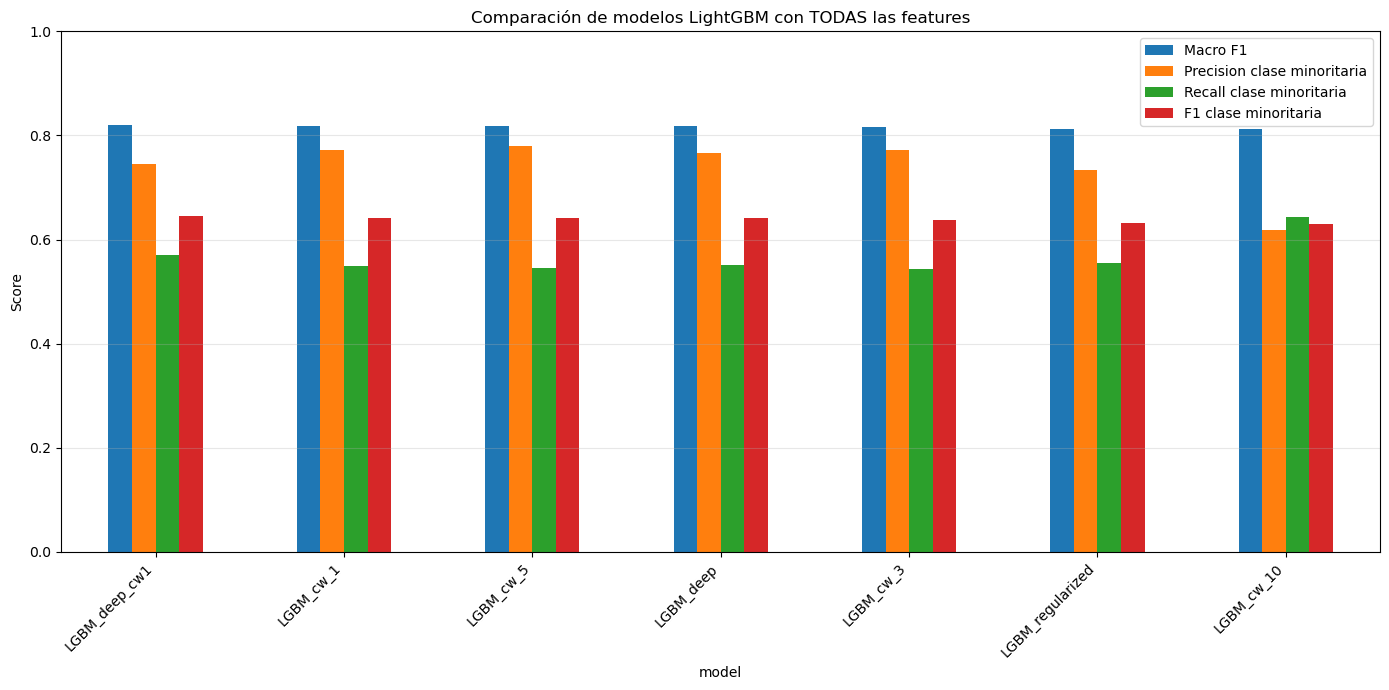


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep_cw1
                   feature         gain  split  gain_pct
time_since_last_congestion 4.207541e+06  13814  0.497640
              week_of_year 8.650085e+05  16806  0.102308
                  hour_cos 6.067903e+05   9094  0.071767
                  hour_sin 6.052102e+05   9544  0.071580
                   minutes 5.339988e+05   6370  0.063158
     estado_rolling_4_to_8 5.334048e+05   1100  0.063088
Denominació / Denominación 4.963845e+05  20895  0.058709
               Day_of_week 4.562860e+05  10324  0.053967
              estado_lag_4 1.503618e+05    253  0.017784


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# FEATURES SELECCIONADAS TOP LIGHTGBM

selected_features = [
    "time_since_last_congestion",
    "hour_sin",
    "hour_cos",
    "minutes",
    "estado_lag_4",
    "Denominació / Denominación",
    "estado_rolling_4_to_8",
    "Day_of_week",
    "week_of_year",
]

# Comprobación por si alguna no existe
missing_features = [
    c for c in selected_features
    if c not in train_df.columns
]

if len(missing_features) > 0:
    print("\nWARNING - Missing selected features:")
    print(missing_features)

selected_features = [
    c for c in selected_features
    if c in train_df.columns
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected TOP LightGBM features ({len(selected_features)}):")
print(selected_features)

# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

In [ ]:
# ─────────────────────────────────────────────
# RESULTS BY THRESHOLD - ONLY LGBM_cw_1
# ─────────────────────────────────────────────

model_name = "LGBM_cw_1"
model = trained_models[model_name]

y_proba_cw1 = model.predict(X_test)

threshold_results_cw1 = []

for threshold in np.arange(0.01, 1.00, 0.01):

    y_pred_t = (y_proba_cw1 > threshold).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_t,
        labels=[0, 1]
    )

    report = classification_report(
        y_test,
        y_pred_t,
        target_names=["fluido(0)", "no_fluido(1)"],
        output_dict=True,
        zero_division=0
    )

    threshold_results_cw1.append({
        "model": model_name,
        "threshold": round(float(threshold), 2),

        "macro_f1": f1_score(
            y_test,
            y_pred_t,
            average="macro"
        ),

        "weighted_f1": f1_score(
            y_test,
            y_pred_t,
            average="weighted"
        ),

        "accuracy": accuracy_score(
            y_test,
            y_pred_t
        ),

        "precision_0": report["fluido(0)"]["precision"],
        "recall_0": report["fluido(0)"]["recall"],
        "f1_0": report["fluido(0)"]["f1-score"],

        "precision_1": report["no_fluido(1)"]["precision"],
        "recall_1": report["no_fluido(1)"]["recall"],
        "f1_1": report["no_fluido(1)"]["f1-score"],

        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

threshold_results_cw1_df = pd.DataFrame(threshold_results_cw1)

print("\n" + "=" * 120)
print("LGBM_cw_1 - RESULTS FOR EACH THRESHOLD 0.01")
print("=" * 120)

print(threshold_results_cw1_df.to_string(index=False))


LGBM_cw_1 - RESULTS FOR EACH THRESHOLD 0.01
    model  threshold  macro_f1  weighted_f1  accuracy  precision_0  recall_0     f1_0  precision_1  recall_1     f1_1      tn      fp    fn    tp
LGBM_cw_1       0.01  0.179363     0.313553  0.202863     0.999864  0.189229 0.318232     0.020666  0.998499 0.040495  235479 1008932    32 21291
LGBM_cw_1       0.02  0.277266     0.497907  0.349404     0.999670  0.338367 0.505600     0.025084  0.993481 0.048932  421068  823343   139 21184
LGBM_cw_1       0.03  0.331229     0.596681  0.444070     0.999545  0.434741 0.605937     0.029092  0.988463 0.056521  540997  703414   246 21077
LGBM_cw_1       0.04  0.366321     0.658989  0.511081     0.999424  0.502994 0.669193     0.032782  0.983070 0.063448  625931  618480   361 20962
LGBM_cw_1       0.05  0.391935     0.702992  0.562346     0.999327  0.555221 0.713838     0.036316  0.978193 0.070032  690923  553488   465 20858
LGBM_cw_1       0.06  0.411884     0.736124  0.603327     0.999227  0.596992 0.

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected CLEAN LightGBM features (33):
['time_since_last_congestion', 'hour_sin', 'estado_rolling_4_to_8', 'hour_cos', 'minutes', 'Denominació / Denominación', 'estado_lag_4', 'Day_of_week', 'week_of_year', 'tmax', 'tmed', 'School_holiday', 'sol', 'tmin', 'day', 'day_sin', 'month_sin', 'day_cos', 'consecutive_congested_steps', 'is_weekend', 'Mascletá/Crida', 'month_cos', 'is_rush_hour', 'month', 'Marathons', 'estado_rolling_8_to_12', 'is_night', 'Spring', 'prec', 'Football_Matches', 'Fallas', 'Public_holiday', 'Demonstrations']

Scaled continuous columns (21):
['time_since_last_congestion', 'hour_sin', 'estado_rolling_4_to_8', 'hour_cos', 'minutes', 'Denominació / Denominación', 'Day_of_week', 'we

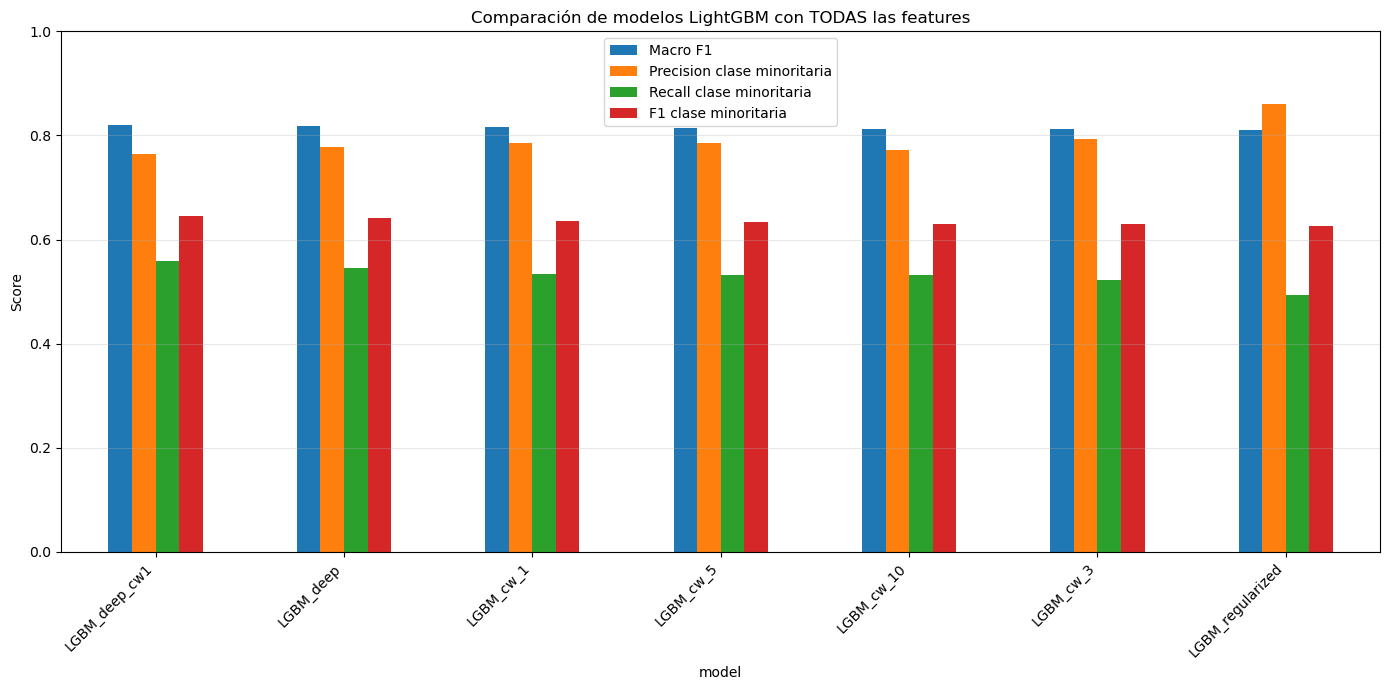


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep_cw1
                    feature         gain  split  gain_pct
 time_since_last_congestion 3.835900e+06   9013  0.448287
                   hour_cos 7.774476e+05   7855  0.090857
                   hour_sin 6.814364e+05   8085  0.079637
      estado_rolling_4_to_8 5.140726e+05    484  0.060078
                    minutes 5.002208e+05   5686  0.058459
 Denominació / Denominación 3.247614e+05  13070  0.037954
               estado_lag_4 2.471147e+05    228  0.028879
                Day_of_week 1.737813e+05   3955  0.020309
               week_of_year 1.366110e+05   3707  0.015965
                       tmax 1.277923e+05   4365  0.014935
                       tmin 1.135661e+05   3988  0.013272
                        sol 1.134824e+05   4874  0.013262
             School_holiday 1.093512e+05    736  0.012779
                       tmed 1.055968e+05   3516  0.012341
                        day 9.116170e+04   3180  0.010654
consecutive_congested_st

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# TODAS LAS FEATURES MENOS OBJETIVO Y COLUMNAS NO USABLES DIRECTAMENTE

# ── 6. Features / target ──
# FEATURES SELECCIONADAS SEGÚN IMPORTANCE DEL MEJOR LIGHTGBM

selected_features_lgbm_clean = [
    "time_since_last_congestion",
    "hour_sin",
    "estado_rolling_4_to_8",
    "hour_cos",
    "minutes",
    "Denominació / Denominación",
    "estado_lag_4",
    "Day_of_week",
    "week_of_year",
    "tmax",
    "tmed",
    "School_holiday",
    "sol",
    "tmin",
    "day",
    "day_sin",
    "month_sin",
    "day_cos",
    "consecutive_congested_steps",
    "is_weekend",
    "Mascletá/Crida",
    "month_cos",
    "is_rush_hour",
    "month",
    "Marathons",
    "estado_rolling_8_to_12",
    "is_night",
    "Spring",
    "prec",
    "Football_Matches",
    "Fallas",
    "Public_holiday",
    "Demonstrations",
]

selected_features = [
    c for c in selected_features_lgbm_clean
    if c in train_df.columns
]

missing_features = [
    c for c in selected_features_lgbm_clean
    if c not in train_df.columns
]

if len(missing_features) > 0:
    print("\nWARNING - Missing selected features:")
    print(missing_features)

# Mantener solo columnas numéricas para LightGBM + SMOTE
selected_features = [
    c for c in selected_features
    if pd.api.types.is_numeric_dtype(train_df[c])
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected CLEAN LightGBM features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

Creating temporal and lag features...
Dropped 1728 rows
Remaining rows: 5455514

Created temporal features:
['estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion']

Train rows: 4189780
Test rows: 1265734

Selected TOP clean features (9):
['time_since_last_congestion', 'hour_cos', 'hour_sin', 'estado_rolling_4_to_8', 'minutes', 'Denominació / Denominación', 'estado_lag_4', 'Day_of_week', 'week_of_year']

Scaled continuous columns (8):
['time_since_last_congestion', 'hour_cos', 'hour_sin', 'estado_rolling_4_to_8', 'minutes', 'Denominació / Denominación', 'Day_of_week', 'week_of_year']

After resampling: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING MULTIPLE LIGHTGBM MODELS

------------------------------------------------------------------------------------------
Training LGBM_cw_1
--------------------------------------------------------------------------------

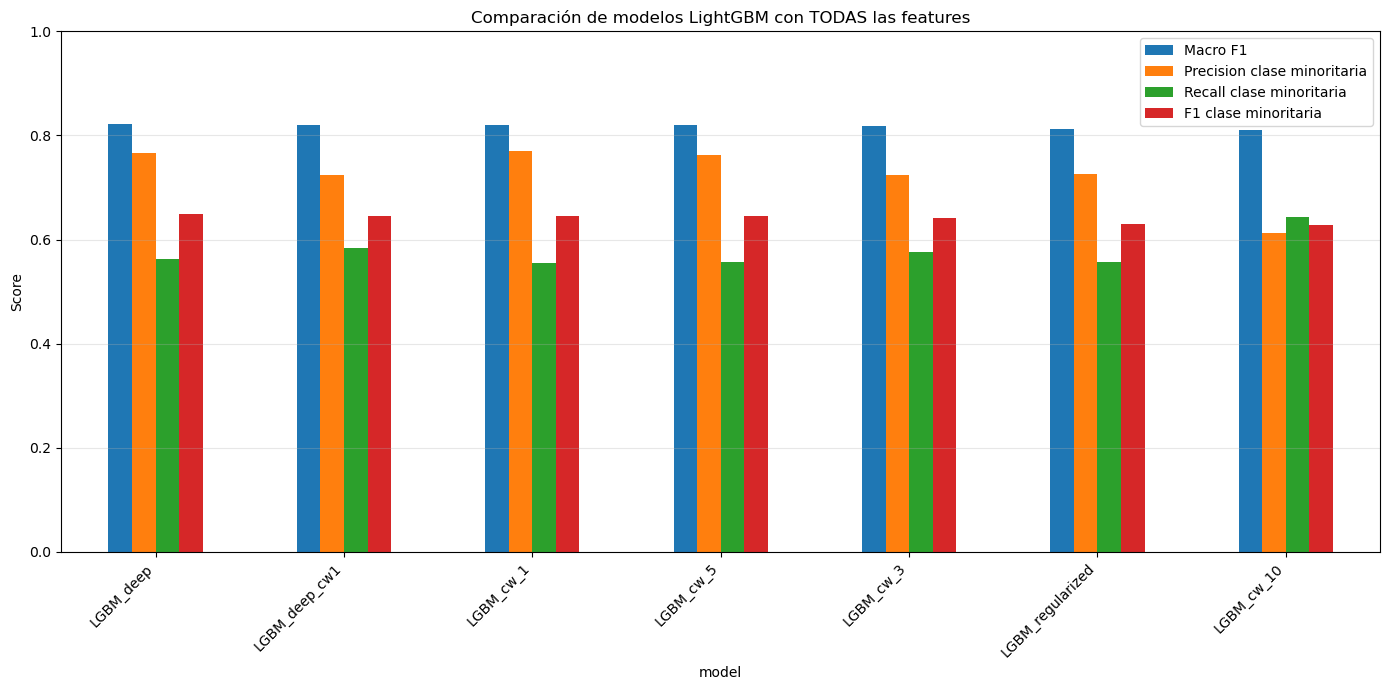


FEATURE IMPORTANCE - BEST MODEL: LGBM_deep
                   feature         gain  split  gain_pct
time_since_last_congestion 7.261135e+06  13700  0.472664
              week_of_year 1.830000e+06  16960  0.119124
                  hour_sin 1.329497e+06   9332  0.086544
                  hour_cos 1.308903e+06  10042  0.085203
Denominació / Denominación 1.070795e+06  20382  0.069703
               Day_of_week 1.019298e+06  10368  0.066351
                   minutes 7.986210e+05   6487  0.051986
     estado_rolling_4_to_8 5.594283e+05    681  0.036416
              estado_lag_4 1.844829e+05    248  0.012009


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    classification_report,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ── 1. Load dataset ──
df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(
    df["fecha"].astype(str) + " " + df["hora"]
)

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ── 2. Create lag_4 ──

# ── 2. Create temporal / lag features ──

print("Creating temporal and lag features...")

grouped = df.groupby("Denominació / Denominación")

# 1. Estado 1 hora antes, porque tus datos son cada 15 min:
# lag_4 = 4 pasos de 15 minutos = 1 hora
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2. Media de congestión entre T-1h y T-2h aprox.
# Usa lags 4, 5, 6, 7, 8
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 3. Media de congestión en una ventana anterior
# Usa lags 8, 9, 10, 11, 12
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(
        window=5,
        min_periods=5
    ).mean()
)

# 4. Tendencia:
# positivo = la congestión reciente está aumentando
# negativo = la congestión reciente está bajando
df["estado_trend"] = (
    df["estado_rolling_4_to_8"]
    - df["estado_rolling_8_to_12"]
)

# 5. Número de pasos consecutivos congestionados hasta T-1h
lag4_state = grouped["Estado_binary"].shift(4)

prev_lag4_state = lag4_state.groupby(
    df["Denominació / Denominación"]
).shift(1)

new_run = (
    lag4_state != prev_lag4_state
).astype(int)

run_id = new_run.groupby(
    df["Denominació / Denominación"]
).cumsum()

df["consecutive_congested_steps"] = (
    lag4_state
    .groupby([
        df["Denominació / Denominación"],
        run_id
    ])
    .cumsum()
    .fillna(0)
)

# 6. Tiempo desde la última congestión observada hasta T-1h
df["_last_congested_dt"] = df["datetime"].where(
    lag4_state == 1
)

df["_last_congested_dt"] = df.groupby(
    "Denominació / Denominación"
)["_last_congested_dt"].ffill()

df["time_since_last_congestion"] = (
    (
        df["datetime"] - df["_last_congested_dt"]
    ).dt.total_seconds()
    / (60 * 15)
)

df = df.drop(
    columns=["_last_congested_dt"]
)

# Drop de filas donde no se pueden calcular las ventanas temporales
before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
    ]
).reset_index(drop=True)

# Si nunca hubo congestión anterior, ponemos un valor alto:
# 672 pasos de 15 min = 7 días
df["time_since_last_congestion"] = (
    df["time_since_last_congestion"]
    .fillna(672)
)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")

print("\nCreated temporal features:")
print([
    "estado_lag_4",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
])


# ── 3. Train/test split ──

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ── 4. Feature engineering ──

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 14) & (hour <= 16))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ── 5. Encode categorical ──

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ── 6. Features / target ──
# TODAS LAS FEATURES MENOS OBJETIVO Y COLUMNAS NO USABLES DIRECTAMENTE

# ── 6. Features / target ──
# TOP FEATURES CLEAN LIGHTGBM

selected_features_lgbm_clean = [
    "time_since_last_congestion",
    "hour_cos",
    "hour_sin",
    "estado_rolling_4_to_8",
    "minutes",
    "Denominació / Denominación",
    "estado_lag_4",
    "Day_of_week",
    "week_of_year",
]

selected_features = [
    c for c in selected_features_lgbm_clean
    if c in train_df.columns
]

X_train = train_df[selected_features].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[selected_features].copy()
y_test = test_df["Estado_binary"]

print(f"\nSelected TOP clean features ({len(selected_features)}):")
print(selected_features)


# ── 7. Scaling ──
# Escalamos automáticamente todas las numéricas no binarias

continuous_cols = [
    c for c in selected_features
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ── 8. SMOTE + undersampling ──

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ── 9. Model configs ──

models_config = {
    "LGBM_cw_1": {
        "scale_pos_weight": 1,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_3": {
        "scale_pos_weight": 3,
        "num_leaves": 31,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_5": {
        "scale_pos_weight": 5,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_cw_10": {
        "scale_pos_weight": 10,
        "num_leaves": 63,
        "learning_rate": 0.05,
        "min_child_samples": 50,
        "num_boost_round": 500,
    },

    "LGBM_deep": {
        "scale_pos_weight": 5,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_deep_cw1": {
        "scale_pos_weight": 1,
        "num_leaves": 127,
        "learning_rate": 0.03,
        "min_child_samples": 30,
        "num_boost_round": 700,
    },

    "LGBM_regularized": {
        "scale_pos_weight": 5,
        "num_leaves": 31,
        "learning_rate": 0.03,
        "min_child_samples": 100,
        "reg_alpha": 0.5,
        "reg_lambda": 1.0,
        "num_boost_round": 700,
    },
}


# ── 10. Evaluation function ──

THRESHOLDS = np.arange(0.05, 0.99, 0.01)


def evaluate_model(y_true, y_proba, thresholds=THRESHOLDS):
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        report = classification_report(
            y_true,
            y_pred,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        result = {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "precision_minority": report["no_fluido(1)"]["precision"],
            "recall_minority": report["no_fluido(1)"]["recall"],
            "f1_minority": report["no_fluido(1)"]["f1-score"],

            "precision_majority": report["fluido(0)"]["precision"],
            "recall_majority": report["fluido(0)"]["recall"],
            "f1_majority": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        }

        if best_result is None or result["macro_f1"] > best_result["macro_f1"]:
            best_result = result

    return best_result


# ── 11. Train models ──

all_results = []
trained_models = {}

print("\n" + "=" * 90)
print("TRAINING MULTIPLE LIGHTGBM MODELS")
print("=" * 90)

for model_name, config in models_config.items():

    print("\n" + "-" * 90)
    print(f"Training {model_name}")
    print("-" * 90)

    config = config.copy()
    num_boost_round = config.pop("num_boost_round")

    params = {
        "objective": "binary",
        "metric": "binary_logloss",

        "max_depth": -1,

        "subsample": 0.8,
        "colsample_bytree": 0.8,

        "reg_alpha": 0.1,
        "reg_lambda": 0.1,

        "verbose": -1,
        "n_jobs": -1,
    }

    params.update(config)

    dtrain = lgb.Dataset(
        X_train_res,
        label=y_train_res,
        feature_name=selected_features
    )

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round
    )

    y_proba = model.predict(X_test)

    best_result = evaluate_model(
        y_test,
        y_proba
    )

    best_result["model"] = model_name
    best_result["num_boost_round"] = num_boost_round
    best_result["scale_pos_weight"] = params.get("scale_pos_weight")
    best_result["num_leaves"] = params.get("num_leaves")
    best_result["learning_rate"] = params.get("learning_rate")
    best_result["min_child_samples"] = params.get("min_child_samples")

    all_results.append(best_result)
    trained_models[model_name] = model

    print(f"Best threshold:      {best_result['threshold']}")
    print(f"Macro F1:            {best_result['macro_f1']:.4f}")
    print(f"Weighted F1:         {best_result['weighted_f1']:.4f}")
    print(f"Accuracy:            {best_result['accuracy']:.4f}")
    print(f"Precision minority:  {best_result['precision_minority']:.4f}")
    print(f"Recall minority:     {best_result['recall_minority']:.4f}")
    print(f"F1 minority:         {best_result['f1_minority']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_result["tn"], best_result["fp"]],
        [best_result["fn"], best_result["tp"]]
    ]))


# ── 12. Results table ──

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "model",
        "threshold",
        "macro_f1",
        "weighted_f1",
        "accuracy",
        "precision_minority",
        "recall_minority",
        "f1_minority",
        "precision_majority",
        "recall_majority",
        "f1_majority",
        "tn",
        "fp",
        "fn",
        "tp",
        "scale_pos_weight",
        "num_leaves",
        "learning_rate",
        "min_child_samples",
        "num_boost_round",
    ]
].sort_values("macro_f1", ascending=False)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

print(results_df.to_string(index=False))


# ── 13. Plot metrics ──

plot_df = results_df.set_index("model")

metrics_to_plot = [
    "macro_f1",
    "precision_minority",
    "recall_minority",
    "f1_minority",
]

ax = plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparación de modelos LightGBM con TODAS las features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1",
    "Precision clase minoritaria",
    "Recall clase minoritaria",
    "F1 clase minoritaria",
])

plt.tight_layout()
plt.show()


# ── 14. Best model feature importance ──

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

importance_df = pd.DataFrame({
    "feature": selected_features,
    "gain": best_model.feature_importance(importance_type="gain"),
    "split": best_model.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

importance_df["gain_pct"] = (
    importance_df["gain"] / importance_df["gain"].sum()
)

print("\n" + "=" * 90)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 90)

print(importance_df.to_string(index=False))

LIGHTGBM con FEATURES + CLIMA

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load FULL dataset (need continuity for lag features) ──
df = pd.read_csv("dataset_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag + temporal features (no leakage: all anchored at ≤ T-1h) ──
print("Creating lag and temporal features...")
grouped = df.groupby("Denominació / Denominación")

# 2a. estado_lag_4: state 1 hour ago
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2b. estado_rolling_4_to_8: mean of states from lag_4 to lag_8 (5 obs, 1.25h window ending 1h ago)
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=5, min_periods=5).mean()
)

# 2c. estado_rolling_4_to_12: mean of states from lag_4 to lag_12 (9 obs, 2h+ window ending 1h ago)
df["estado_rolling_4_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=9, min_periods=9).mean()
)

# 2c2. estado_rolling_8_to_12: older 1h window (used for trend computation)
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=5, min_periods=5).mean()
)

# 2c3. estado_trend: recent congestion rate minus older rate (positive = getting worse)
df["estado_trend"] = df["estado_rolling_4_to_8"] - df["estado_rolling_8_to_12"]

# 2d. consecutive_congested_steps: length of current congestion streak ending at T-1h
# Trick: within each road, mark run starts (where state changes) and cumsum within runs of 1s
lag4_state = grouped["Estado_binary"].shift(4)
prev_lag4 = lag4_state.groupby(df["Denominació / Denominación"]).shift(1)
new_run = (lag4_state != prev_lag4).astype(int)
run_id = new_run.groupby(df["Denominació / Denominación"]).cumsum()
df["consecutive_congested_steps"] = (
    lag4_state.groupby([df["Denominació / Denominación"], run_id]).cumsum().fillna(0)
)

# 2e. time_since_last_congestion: 15-min steps since last observed congestion (at T-1h or earlier)
df["_last_congested_dt"] = df["datetime"].where(lag4_state == 1)
df["_last_congested_dt"] = df.groupby("Denominació / Denominación")["_last_congested_dt"].ffill()
df["time_since_last_congestion"] = (
    (df["datetime"] - df["_last_congested_dt"]).dt.total_seconds() / (60 * 15)
)
df = df.drop(columns=["_last_congested_dt"])

# Drop rows with NaN for short-window features
before = len(df)
df = df.dropna(subset=[
    "estado_lag_4", "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]).reset_index(drop=True)

# Fill NaN for features where missingness has meaning
df["time_since_last_congestion"] = df["time_since_last_congestion"].fillna(672)

print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 4. Feature engineering (full v4 set) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Full v4 + temporal features (WITHOUT estado_lag_96 and estado_lag_672), MINUS 21 low-importance features ──
drop_cols = [
    "Estado", "Estado_binary", "fecha", "hora", "datetime",
    # Low-importance features removed based on previous run's gain ranking
    "day_sin", "Mascletá/Crida", "month_cos", "Marathons", "Spring",
    "month", "Fallas", "Public_holiday", "prec", "Football_Matches",
    "Demonstrations", "Summer", "Autumn", "Winter", "BigSound_Concerts",
    "Davis_Cup", "Elections", "University_Entrance_Exams",
    "Festival_de_les_arts", "Roig_Arena_Events", "San_Juan",
]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 5. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

continuous_cols = [
    "tmed", "tmin", "tmax", "sol",
    "minutes", "hour_sin", "hour_cos", "month_sin",
    "day_cos",
    "time_since_last_congestion", "consecutive_congested_steps",
    "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 6. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train model ──
print(f"── Training model ({len(feature_names)} features) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 12. Save ──
final_model.save_model("lightgbm_lag_v4_no_long_lags_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "22 base features + estado_trend, estado_rolling_8_to_12 = 24 features (removed estado_lag_96 and estado_lag_672)",
}
with open("lightgbm_lag_v4_no_long_lags_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_lag_v4_no_long_lags_model.txt")
print("Results saved to lightgbm_lag_v4_no_long_lags_results.json")

# Guardar referencias del modelo CON climatología
model_climate = final_model
X_test_climate = X_test.copy()
feature_names_climate = feature_names.copy()
proba_climate = y_test_proba.copy()
best_threshold_climate = best_threshold
y_pred_climate = y_best_pred.copy()

Creating lag and temporal features...
Dropped 1728 rows with NaN lags (5455514 remaining)

Train: 4189780 rows, Test: 1265734 rows

Features (24): ['Denominació / Denominación', 'tmed', 'tmin', 'tmax', 'sol', 'Day_of_week', 'School_holiday', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_4_to_12', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month_sin', 'day', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4155647
no_fluido      34133
Name: count, dtype: int64


C:\Users\vicen\AppData\Local\Temp\ipykernel_12644\4169019215.py:157: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
C:\Users\vicen\AppData\Local\Temp\ipykernel_12644\4169019215.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (24 features) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7469

Confusion matrix:
[[1219469   24942]
 [   5648   15675]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       1.00      0.98      0.99   1244411
no_fluido(1)       0.39      0.74      0.51     21323

    accuracy                           0.98   1265734
   macro avg       0.69      0.86      0.75   1265734
weighted avg       0.99      0.98      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.9242       0.0669         0.1248     0.5001       274715         1617      
  0.10         0.8898       0.1053         0.1882     0.5590       161286         2350      
  0.15         0.8626       0.1420         0.2

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import json

# ── 1. Load FULL dataset (need continuity for lag features) ──
df = pd.read_csv("dataset_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = df["fecha"].astype(str) + " " + df["hora"]
df["datetime"] = pd.to_datetime(df["datetime"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(["Denominació / Denominación", "datetime"]).reset_index(drop=True)

# ── 2. Create lag + temporal features (no leakage: all anchored at ≤ T-1h) ──
print("Creating lag and temporal features...")
grouped = df.groupby("Denominació / Denominación")

# 2a. estado_lag_4: state 1 hour ago
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# 2b. estado_rolling_4_to_8: mean of states from lag_4 to lag_8 (5 obs, 1.25h window ending 1h ago)
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=5, min_periods=5).mean()
)

# 2c. estado_rolling_4_to_12: mean of states from lag_4 to lag_12 (9 obs, 2h+ window ending 1h ago)
df["estado_rolling_4_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=9, min_periods=9).mean()
)

# 2c2. estado_rolling_8_to_12: older 1h window (used for trend computation)
df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=5, min_periods=5).mean()
)

# 2c3. estado_trend: recent congestion rate minus older rate (positive = getting worse)
df["estado_trend"] = df["estado_rolling_4_to_8"] - df["estado_rolling_8_to_12"]

# 2d. consecutive_congested_steps: length of current congestion streak ending at T-1h
# Trick: within each road, mark run starts (where state changes) and cumsum within runs of 1s
lag4_state = grouped["Estado_binary"].shift(4)
prev_lag4 = lag4_state.groupby(df["Denominació / Denominación"]).shift(1)
new_run = (lag4_state != prev_lag4).astype(int)
run_id = new_run.groupby(df["Denominació / Denominación"]).cumsum()
df["consecutive_congested_steps"] = (
    lag4_state.groupby([df["Denominació / Denominación"], run_id]).cumsum().fillna(0)
)

# 2e. time_since_last_congestion: 15-min steps since last observed congestion (at T-1h or earlier)
df["_last_congested_dt"] = df["datetime"].where(lag4_state == 1)
df["_last_congested_dt"] = df.groupby("Denominació / Denominación")["_last_congested_dt"].ffill()
df["time_since_last_congestion"] = (
    (df["datetime"] - df["_last_congested_dt"]).dt.total_seconds() / (60 * 15)
)
df = df.drop(columns=["_last_congested_dt"])

# Drop rows with NaN for short-window features
before = len(df)
df = df.dropna(subset=[
    "estado_lag_4", "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]).reset_index(drop=True)

# Fill NaN for features where missingness has meaning
df["time_since_last_congestion"] = df["time_since_last_congestion"].fillna(672)

print(f"Dropped {before - len(df)} rows with NaN lags ({len(df)} remaining)\n")

# ── 3. Train/test split (temporal: 2023-2024 train, 2025 test) ──
train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

# ── 4. Feature engineering (full v4 set) ──
def add_features(df):
    df = df.copy()
    time_parts = df["hora"].str.split(":", expand=True).astype(int)

    df["minutes"] = time_parts[0] * 60 + time_parts[1]
    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    hour = time_parts[0]
    df["is_rush_hour"] = (((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 20))).astype(int)
    df["is_night"] = ((hour >= 22) | (hour <= 6)).astype(int)

    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

le_denom = LabelEncoder()
train_df["Denominació / Denominación"] = le_denom.fit_transform(train_df["Denominació / Denominación"])
test_df["Denominació / Denominación"] = le_denom.transform(test_df["Denominació / Denominación"])

le_day = LabelEncoder()
train_df["Day_of_week"] = le_day.fit_transform(train_df["Day_of_week"])
test_df["Day_of_week"] = le_day.transform(test_df["Day_of_week"])

# ── Drop climatology features + low-importance features ──
drop_cols = [
    "Estado", "Estado_binary", "fecha", "hora", "datetime",
    # Climatology features (REMOVED)
    "tmed", "tmin", "tmax", "sol", "prec",
    # Low-importance features removed based on previous run's gain ranking
    "day_sin", "Mascletá/Crida", "month_cos", "Marathons", "Spring",
    "month", "Fallas", "Public_holiday", "Football_Matches",
    "Demonstrations", "Summer", "Autumn", "Winter", "BigSound_Concerts",
    "Davis_Cup", "Elections", "University_Entrance_Exams",
    "Festival_de_les_arts", "Roig_Arena_Events", "San_Juan",
]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Estado_binary"]
X_test = test_df[feature_cols]
y_test = test_df["Estado_binary"]

feature_names = X_train.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}\n")

# ── 5. Undersample + SMOTE ──
print("Class distribution before resampling:")
print(y_train.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))

TARGET_SAMPLES = 200000

# Removed climatology features from continuous_cols
continuous_cols = [
    "minutes", "hour_sin", "hour_cos", "month_sin",
    "day_cos",
    "time_since_last_congestion", "consecutive_congested_steps",
    "estado_rolling_4_to_8", "estado_rolling_4_to_12",
    "estado_rolling_8_to_12", "estado_trend",
]
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

pipeline = ImbPipeline(steps=[
    ("undersample", RandomUnderSampler(sampling_strategy={0: TARGET_SAMPLES}, random_state=42)),
    ("oversample", SMOTE(sampling_strategy={1: TARGET_SAMPLES}, random_state=42, k_neighbors=5)),
])

X_train_res, y_train_res = pipeline.fit_resample(X_train, y_train)

print("\nClass distribution after resampling:")
print(y_train_res.value_counts().sort_index().rename({0: "fluido", 1: "no_fluido"}))
print(f"Total training rows: {len(X_train_res)}\n")

# ── 6. LightGBM parameters ──
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# ── 7. Train model ──
print(f"── Training model ({len(feature_names)} features) ──\n")
dtrain = lgb.Dataset(X_train_res, label=y_train_res, feature_name=feature_names)
final_model = lgb.train(params, dtrain, num_boost_round=500)

# ── 8. Initial evaluation (threshold = 0.5) ──
y_test_proba = final_model.predict(X_test)
y_test_pred_default = (y_test_proba > 0.5).astype(int)

print("── Test Set Results (threshold=0.5) ──")
print(f"Macro F1: {f1_score(y_test, y_test_pred_default, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_test_pred_default, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 9. Threshold optimization ──
print("── Threshold Optimization ──")
print(f"{'threshold':<12} {'recall_nf':<12} {'precision_nf':<14} {'f1_nf':<10} {'f1_macro':<12} {'false_alarms':<14} {'missed':<10}")

best_threshold = 0.5
best_macro_f1 = 0

for threshold in np.arange(0.05, 0.99, 0.01):
    y_pred_t = (y_test_proba > threshold).astype(int)
    f1_t = f1_score(y_test, y_pred_t, average="macro")
    if f1_t > best_macro_f1:
        best_macro_f1 = f1_t
        best_threshold = round(threshold, 2)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    recall_nf = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    precision_nf = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1_nf = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    false_alarms = cm_t[0, 1]
    missed = cm_t[1, 0]
    if int(threshold * 100) % 5 == 0:
        print(f"  {threshold:<12.2f} {recall_nf:<12.4f} {precision_nf:<14.4f} {f1_nf:<10.4f} {f1_t:<12.4f} {false_alarms:<14} {missed:<10}")

print(f"\n** Best threshold: {best_threshold} (Macro F1: {best_macro_f1:.4f}) **")

# ── 10. Evaluate with best threshold ──
y_best_pred = (y_test_proba > best_threshold).astype(int)
print(f"\n── Test Set Results (threshold={best_threshold}) ──")
print(f"Macro F1: {f1_score(y_test, y_best_pred, average='macro'):.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_best_pred, labels=[0, 1])}")
print(f"\nClassification report:\n{classification_report(y_test, y_best_pred, target_names=['fluido(0)', 'no_fluido(1)'])}")

# ── 11. Feature importance ──
importance = final_model.feature_importance(importance_type="gain")
feat_imp = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
print("\n── Feature Importance (gain) ──")
for name, imp in feat_imp:
    print(f"  {name}: {imp:.0f}")

# ── 12. Save ──
final_model.save_model("lightgbm_no_climate_model.txt")

results = {
    "test_macro_f1": float(best_macro_f1),
    "best_threshold": best_threshold,
    "boost_rounds": 500,
    "features_used": feature_names,
    "n_features": len(feature_names),
    "changes": "20 features total (removed tmed, tmin, tmax, sol, estado_lag_96, estado_lag_672)",
}
with open("lightgbm_no_climate_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nModel saved to lightgbm_no_climate_model.txt")
print("Results saved to lightgbm_no_climate_results.json")

# Guardar referencias del modelo SIN climatología
model_no_climate = final_model
X_test_no_climate = X_test.copy()
feature_names_no_climate = feature_names.copy()
proba_no_climate = y_test_proba.copy()
best_threshold_no_climate = best_threshold
y_pred_no_climate = y_best_pred.copy()

Creating lag and temporal features...
Dropped 1728 rows with NaN lags (5455514 remaining)

Train: 4189780 rows, Test: 1265734 rows

Features (20): ['Denominació / Denominación', 'Day_of_week', 'School_holiday', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_4_to_12', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month_sin', 'day', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

Class distribution before resampling:
Estado_binary
fluido       4155647
no_fluido      34133
Name: count, dtype: int64


C:\Users\vicen\AppData\Local\Temp\ipykernel_12644\135483953.py:159: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
C:\Users\vicen\AppData\Local\Temp\ipykernel_12644\135483953.py:160: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



Class distribution after resampling:
Estado_binary
fluido       200000
no_fluido    200000
Name: count, dtype: int64
Total training rows: 400000

── Training model (20 features) ──

── Test Set Results (threshold=0.5) ──
Macro F1: 0.7315

Confusion matrix:
[[1212457   31954]
 [   4595   16728]]

Classification report:
              precision    recall  f1-score   support

   fluido(0)       1.00      0.97      0.99   1244411
no_fluido(1)       0.34      0.78      0.48     21323

    accuracy                           0.97   1265734
   macro avg       0.67      0.88      0.73   1265734
weighted avg       0.99      0.97      0.98   1265734

── Threshold Optimization ──
threshold    recall_nf    precision_nf   f1_nf      f1_macro     false_alarms   missed    
  0.05         0.9624       0.0569         0.1074     0.4743       340417         802       
  0.10         0.9350       0.0895         0.1633     0.5370       202902         1387      
  0.15         0.9107       0.1201         0.2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score
)

# =========================================================
# 1. MÉTRICAS COMPARATIVAS
# =========================================================

metrics_df = pd.DataFrame({
    "Modelo": ["Sin climatología", "Con climatología"],

    "Threshold óptimo": [
        best_threshold_no_climate,
        best_threshold_climate
    ],

    "Macro F1": [
        f1_score(y_test, y_pred_no_climate, average="macro"),
        f1_score(y_test, y_pred_climate, average="macro")
    ],

    "Recall no fluido": [
        recall_score(y_test, y_pred_no_climate, pos_label=1),
        recall_score(y_test, y_pred_climate, pos_label=1)
    ],

    "Precision no fluido": [
        precision_score(y_test, y_pred_no_climate, pos_label=1),
        precision_score(y_test, y_pred_climate, pos_label=1)
    ],

    "F1 no fluido": [
        f1_score(y_test, y_pred_no_climate, pos_label=1),
        f1_score(y_test, y_pred_climate, pos_label=1)
    ]
})

display(metrics_df)

,Modelo,Threshold óptimo,Macro F1,Recall no fluido,Precision no fluido,F1 no fluido
0,Sin climatología,0.86,0.826856,0.582517,0.758257,0.658869
1,Con climatología,0.84,0.822302,0.556629,0.780239,0.649733


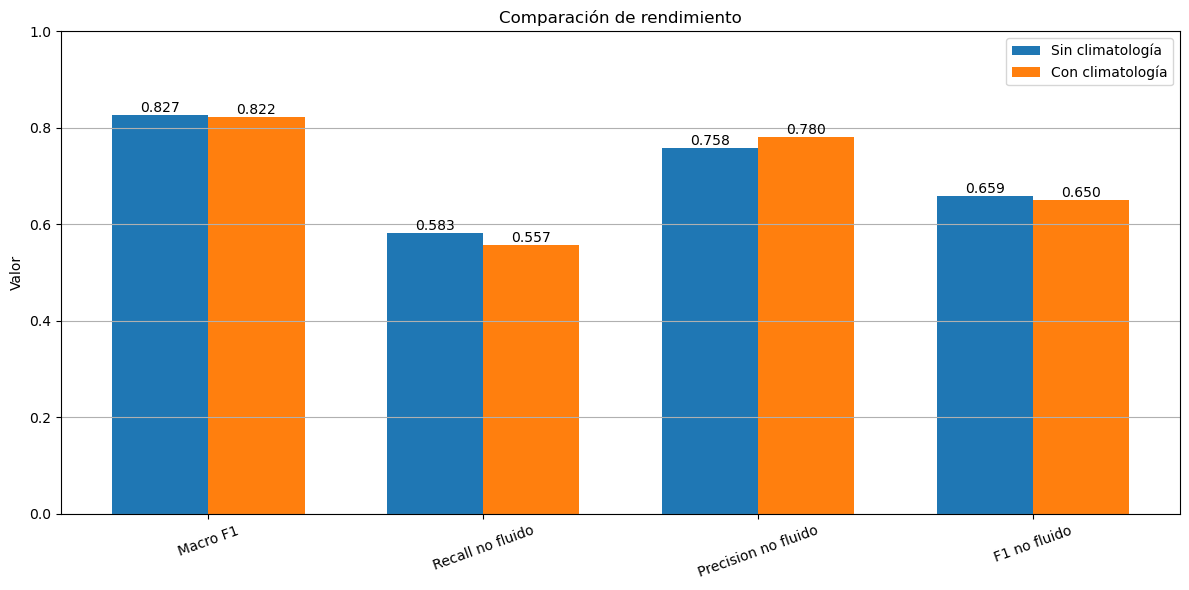

In [ ]:
metric_names = [
    "Macro F1",
    "Recall no fluido",
    "Precision no fluido",
    "F1 no fluido"
]

x = np.arange(len(metric_names))
width = 0.35

values_no_climate = metrics_df.loc[0, metric_names].values
values_climate = metrics_df.loc[1, metric_names].values

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    values_no_climate,
    width,
    label="Sin climatología"
)

bars2 = plt.bar(
    x + width / 2,
    values_climate,
    width,
    label="Con climatología"
)

plt.xticks(x, metric_names, rotation=20)
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.title("Comparación de rendimiento")
plt.legend()
plt.grid(axis="y")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

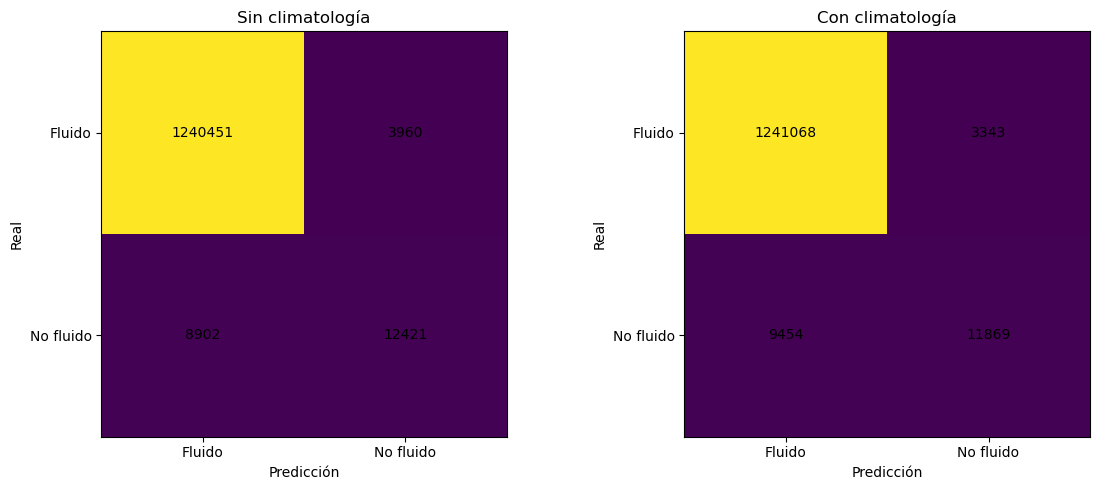

In [ ]:
cm_no_climate = confusion_matrix(y_test, y_pred_no_climate, labels=[0, 1])
cm_climate = confusion_matrix(y_test, y_pred_climate, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cm_no_climate)
axes[0].set_title("Sin climatología")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Fluido", "No fluido"])
axes[0].set_yticklabels(["Fluido", "No fluido"])

for i in range(2):
    for j in range(2):
        axes[0].text(
            j, i,
            cm_no_climate[i, j],
            ha="center",
            va="center"
        )

axes[1].imshow(cm_climate)
axes[1].set_title("Con climatología")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Fluido", "No fluido"])
axes[1].set_yticklabels(["Fluido", "No fluido"])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i,
            cm_climate[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

HISTGRADIENTBOOSTING CON LAG_4 Y TODOS FEATURES

Creating temporal feature: estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ALL features (39):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

----------------------------------------------------------------------------------------------------
Training model: HGB_base
----------------------

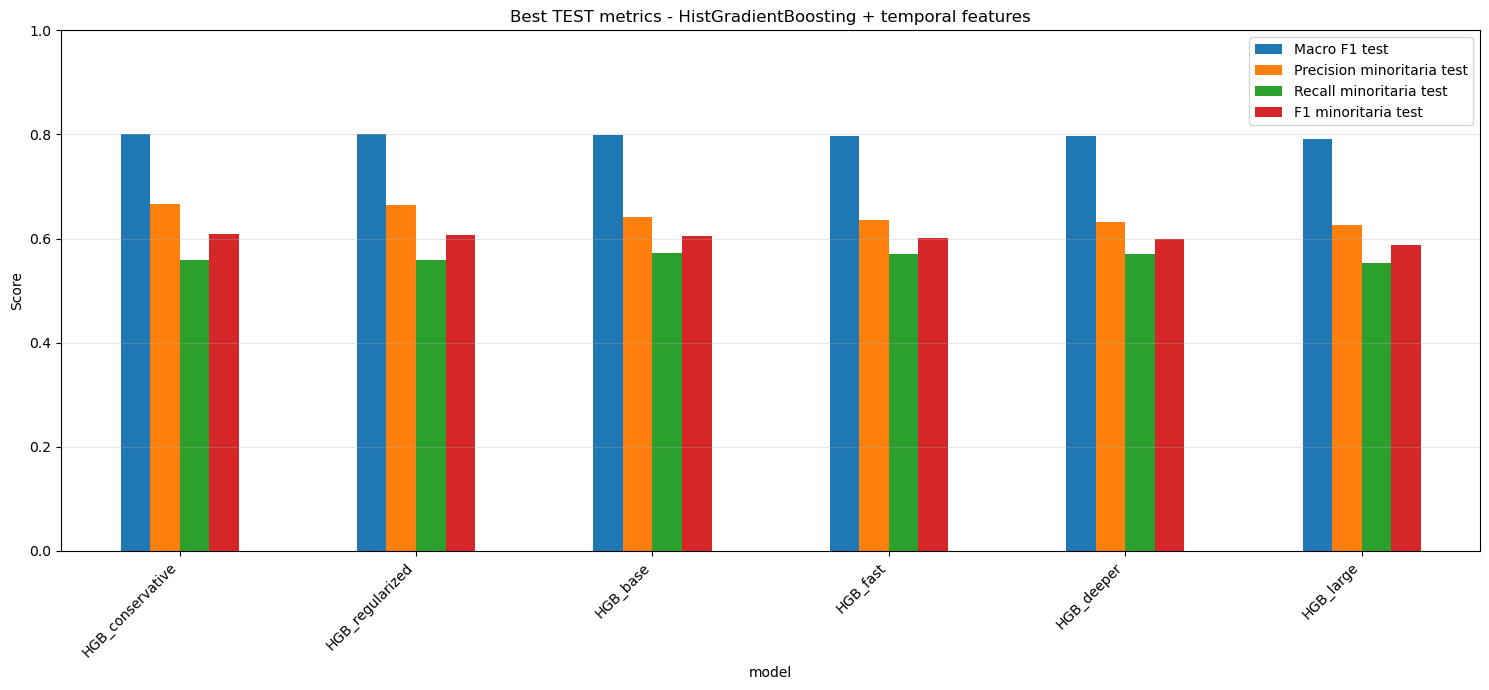

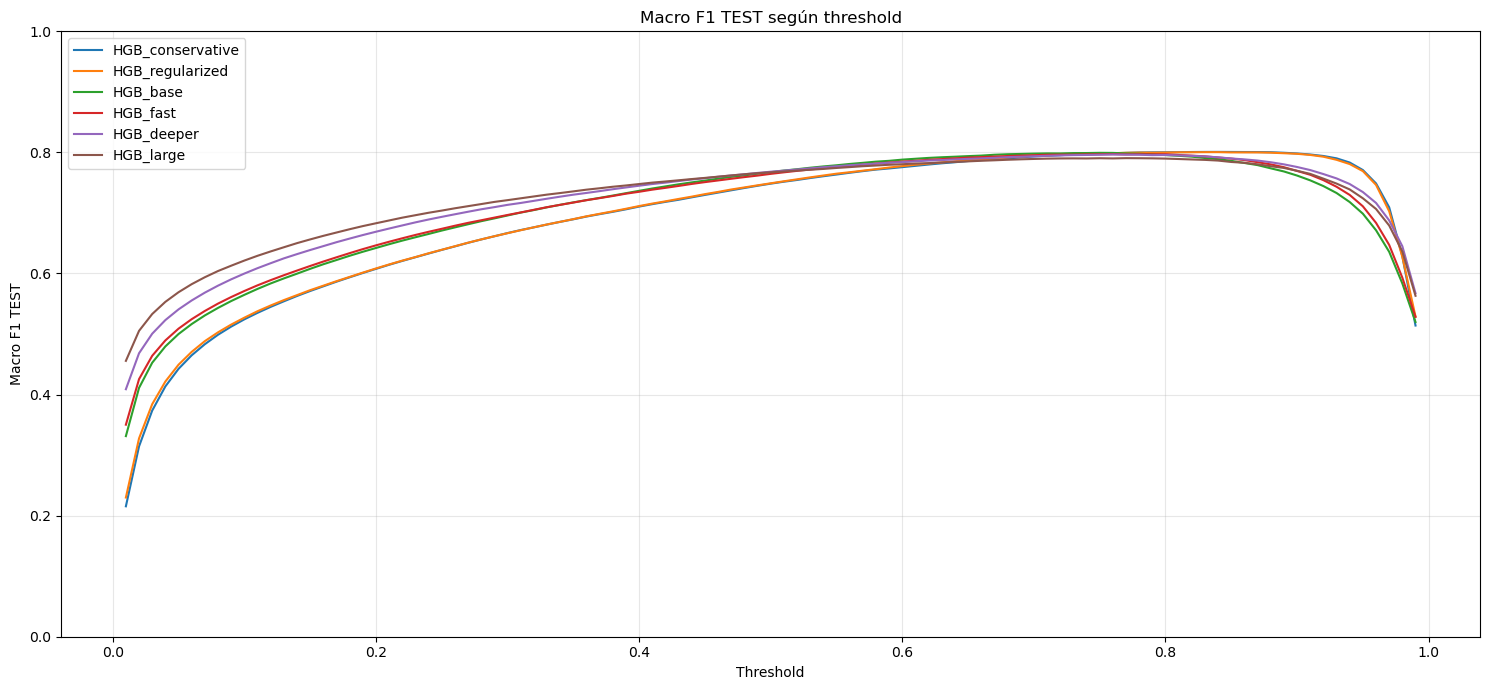

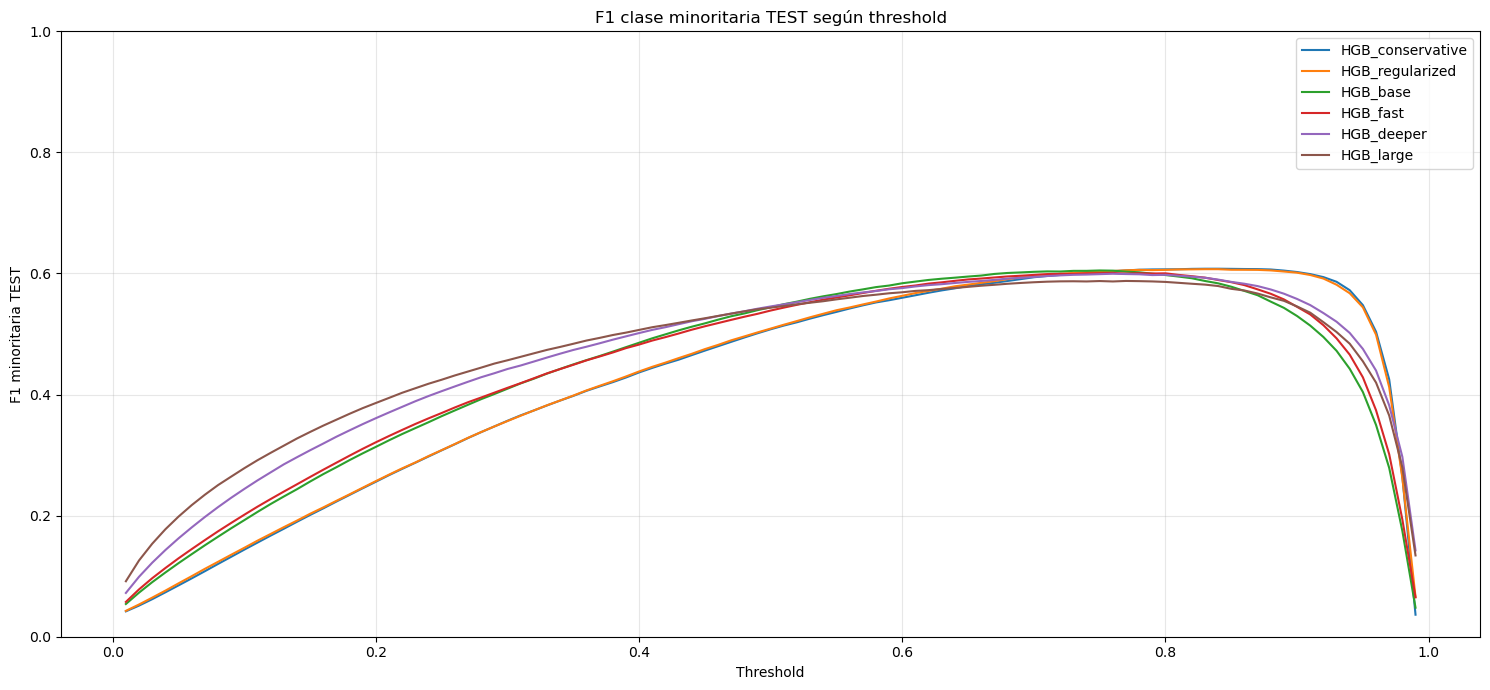

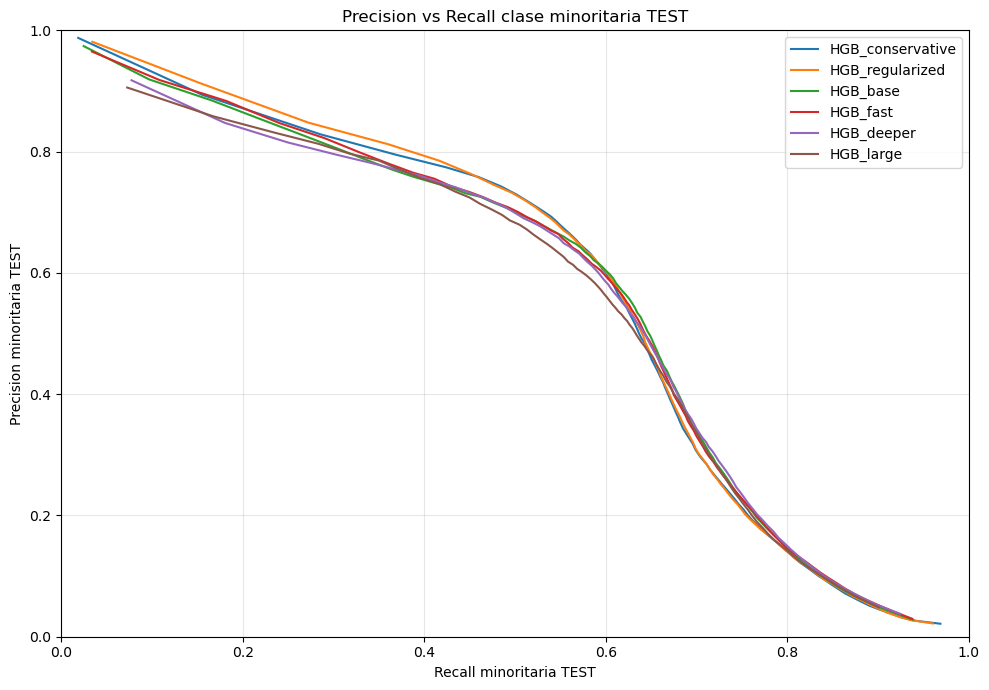


BEST TEST MODEL: HGB_conservative
model                      HGB_conservative
threshold                              0.84
macro_f1_test                      0.800859
weighted_f1_test                   0.987326
accuracy_test                      0.987846
precision_minority_test            0.665792
recall_minority_test               0.559255
f1_minority_test                   0.607891
precision_majority_test            0.992468
recall_majority_test                0.99519
f1_majority_test                   0.993827
tn                                  1238425
fp                                     5986
fn                                     9398
tp                                    11925


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURE: ONLY estado_lag_4
# ─────────────────────────────────────────────

print("Creating temporal feature: estado_lag_4...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Only temporal feature:
# lag_4 = estado observado 4 pasos antes = 1 hora antes si tus datos son cada 15 min
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

HISTGRADIENTBOOSTING SOLO CON ESTADO_LAG4

Creating temporal feature: estado_lag_4...
Dropped 576 rows
Remaining rows: 5456666

Train rows: 4190932
Test rows: 1265734

Using ONLY estado_lag_4 as feature (1):
['estado_lag_4']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

----------------------------------------------------------------------------------------------------
Training model: HGB_base
----------------------------------------------------------------------------------------------------

Best TEST result:
Threshold:          0.38
Macro F1 test:      0.7823
Weighted F1 test:   0.9856
Accuracy test:      0.9856
Precision minority: 0.5722
Recall minority:    0.5717
F1 minority:        0.5719

Confusion matrix:
[[1235295    9116]
 [   9132   12191]]

----------------------------------------------------------------------------------------------------
Training model: HGB_deeper
------------------------------------------

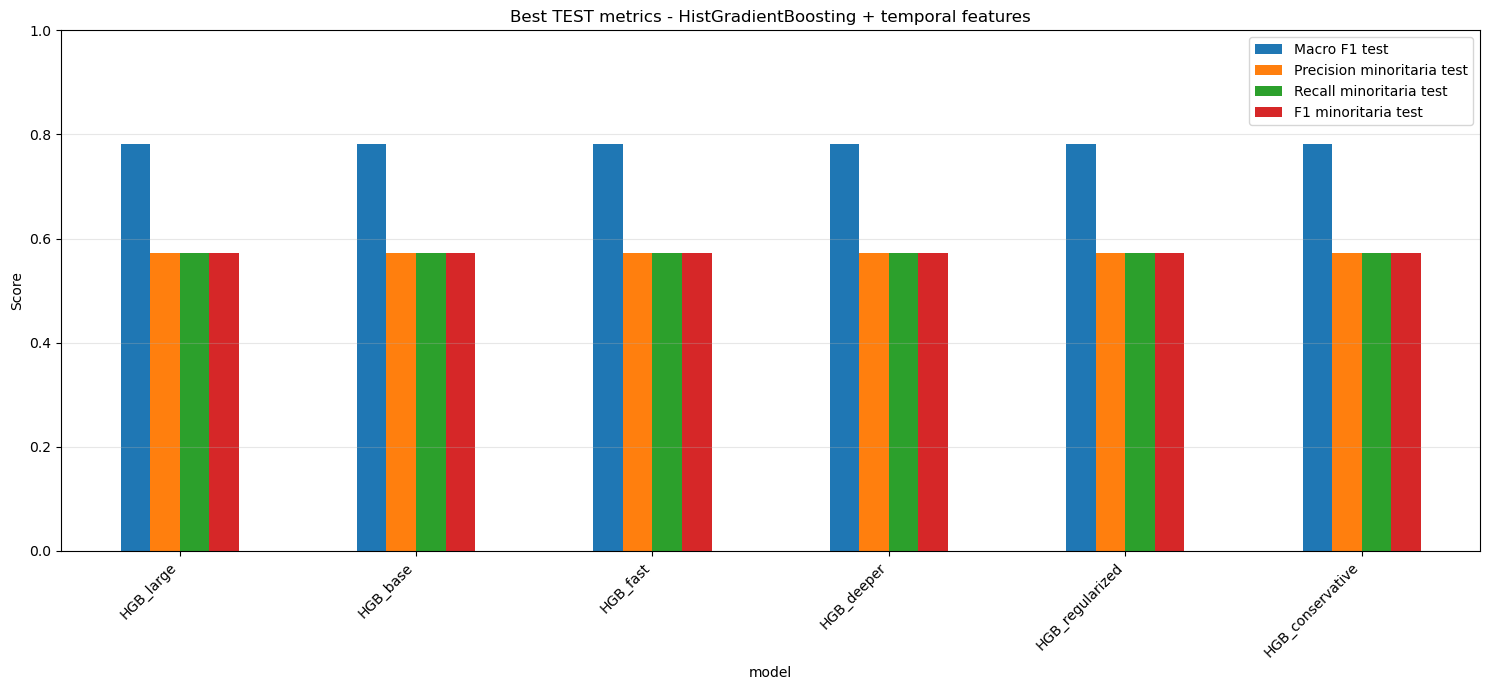

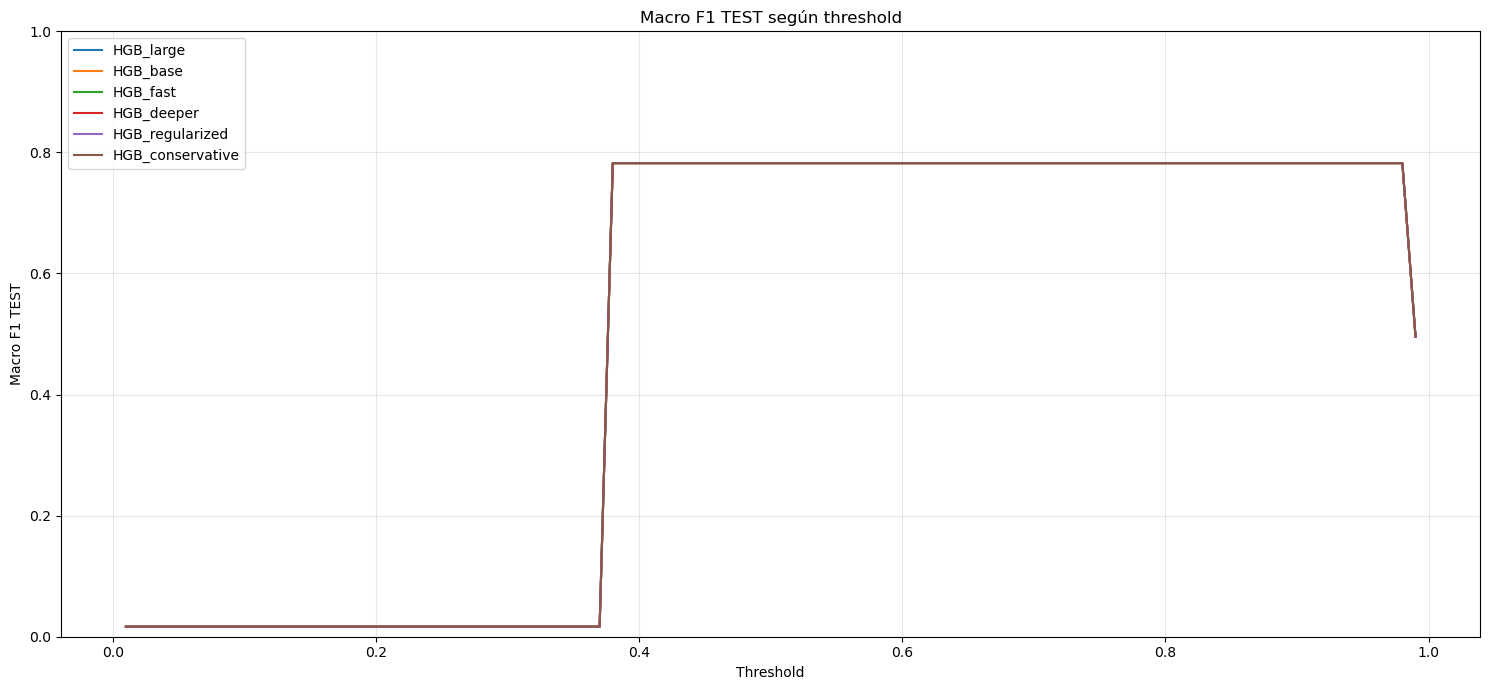

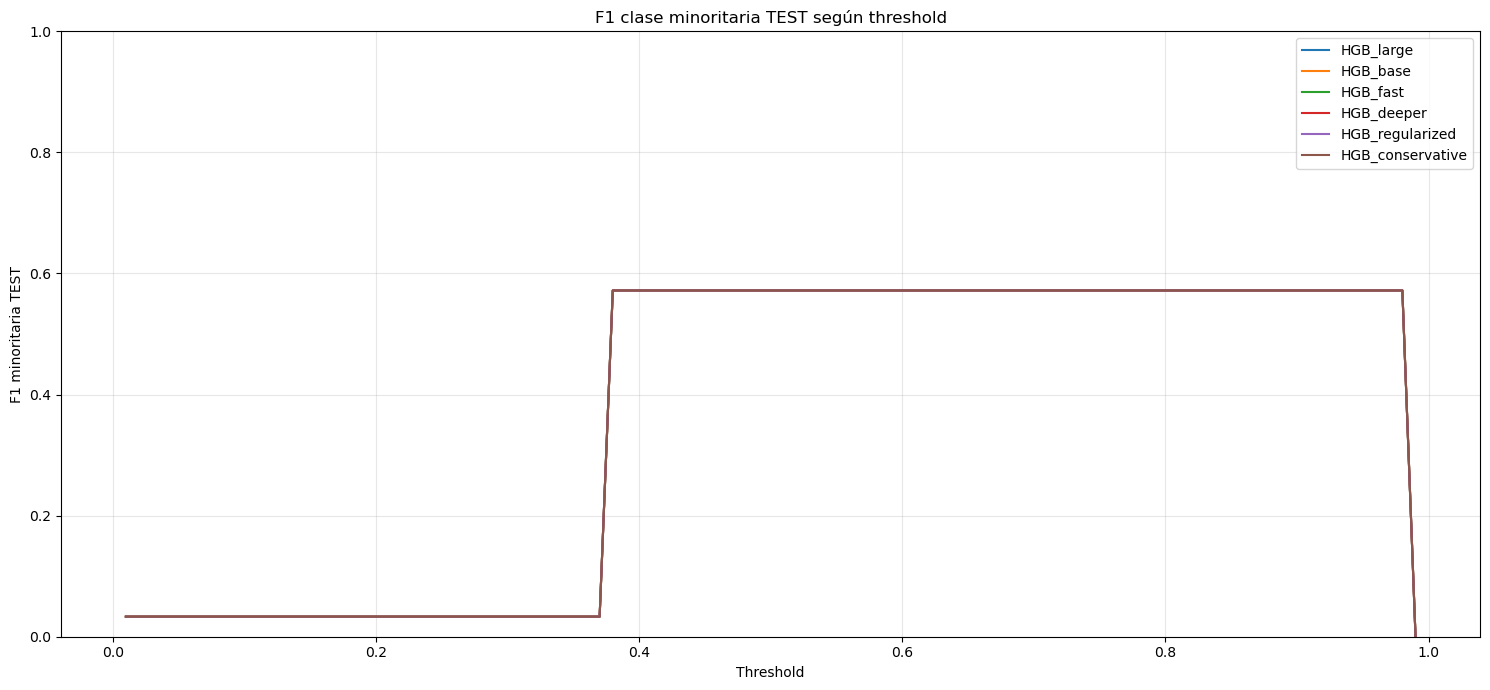

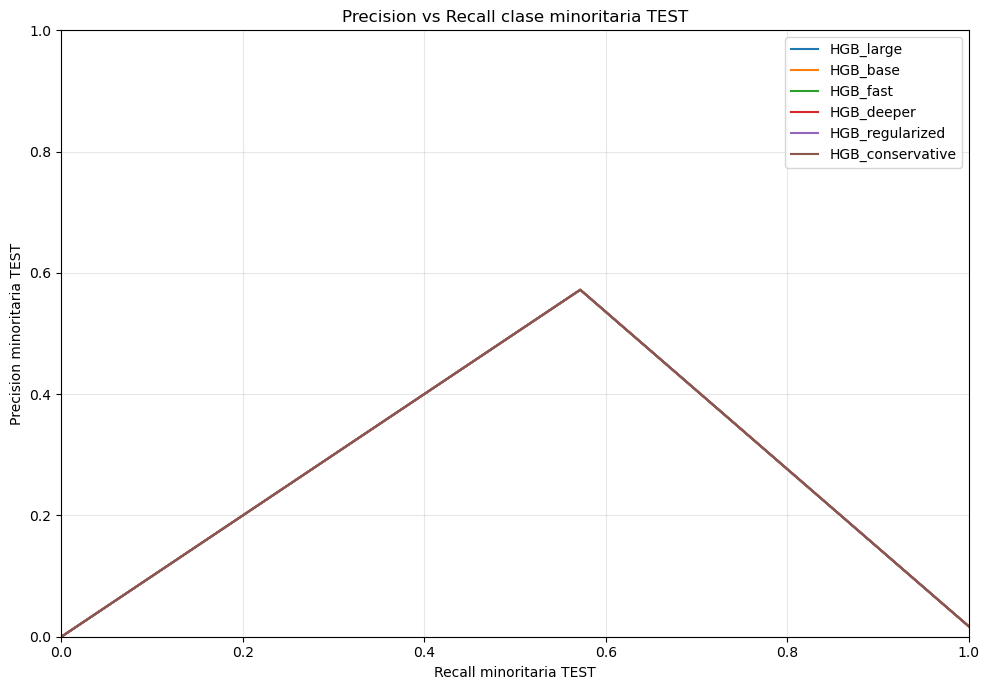


BEST TEST MODEL: HGB_large
model                      HGB_large
threshold                       0.98
macro_f1_test               0.782306
weighted_f1_test             0.98558
accuracy_test               0.985583
precision_minority_test     0.572159
recall_minority_test         0.57173
f1_minority_test            0.571945
precision_majority_test     0.992662
recall_majority_test        0.992674
f1_majority_test            0.992668
tn                           1235295
fp                              9116
fn                              9132
tp                             12191


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURE: ONLY estado_lag_4
# ─────────────────────────────────────────────

print("Creating temporal feature: estado_lag_4...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Only temporal feature:
# lag_4 = estado observado 4 pasos antes = 1 hora antes si tus datos son cada 15 min
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

before = len(df)

df = df.dropna(
    subset=["estado_lag_4"]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 6. USE ONLY estado_lag_4
# ─────────────────────────────────────────────

feature_cols = [
    "estado_lag_4"
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ONLY estado_lag_4 as feature ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = []

scaler = StandardScaler()

# No scaling needed because estado_lag_4 is binary


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

HISTGRADIENT BOOSTING CON TEMPORAL FEATURES

Creating temporal features...
Dropped 1152 rows
Remaining rows: 5456090

Train rows: 4190356
Test rows: 1265734

Using ALL features (44):
['Denominació / Denominación', 'tmed', 'prec', 'tmin', 'tmax', 'sol', 'Day_of_week', 'Public_holiday', 'School_holiday', 'Festival_de_les_arts', 'Davis_Cup', 'Elections', 'Demonstrations', 'Marathons', 'Fallas', 'Mascletá/Crida', 'University_Entrance_Exams', 'BigSound_Concerts', 'Roig_Arena_Events', 'Football_Matches', 'San_Juan', 'Summer', 'Winter', 'Autumn', 'Spring', 'estado_lag_4', 'estado_rolling_4_to_8', 'estado_rolling_8_to_12', 'estado_trend', 'consecutive_congested_steps', 'time_since_last_congestion', 'minutes', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'day', 'day_sin', 'day_cos', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

--------------------------------

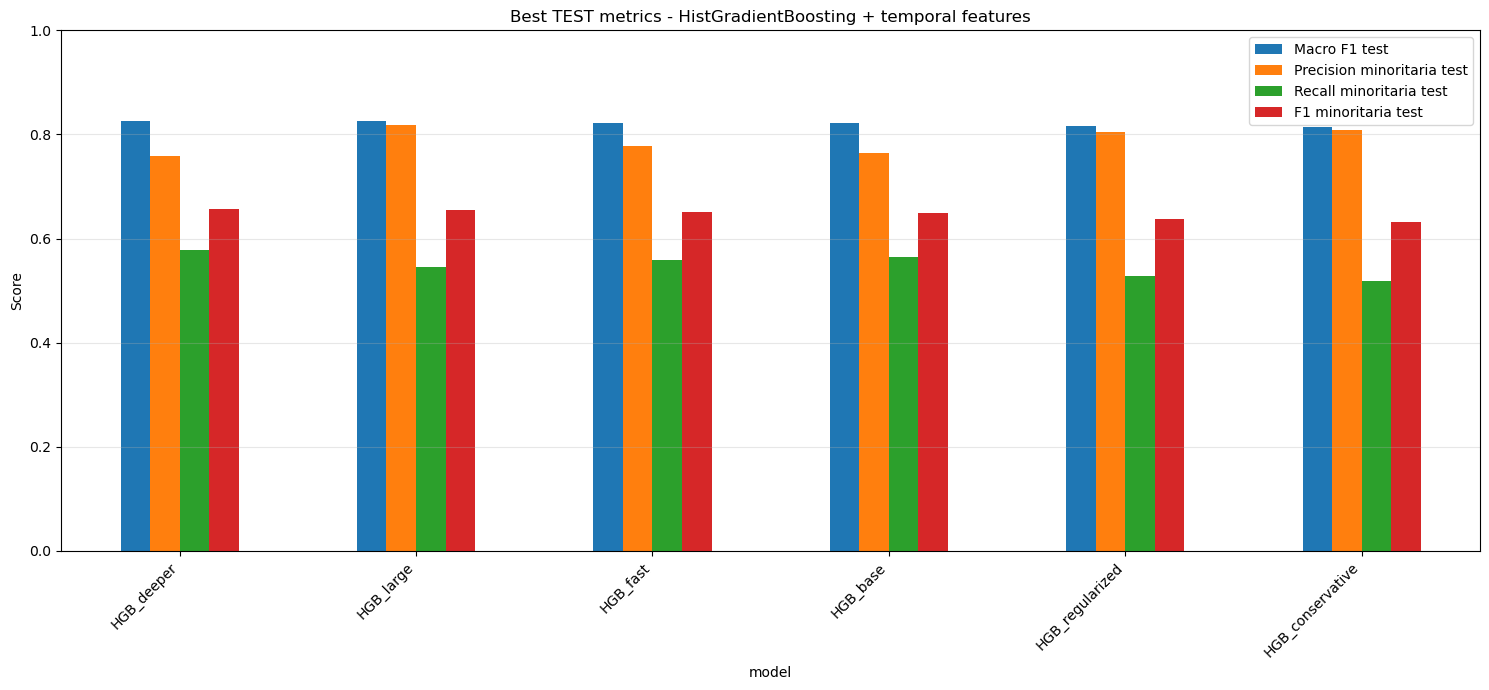

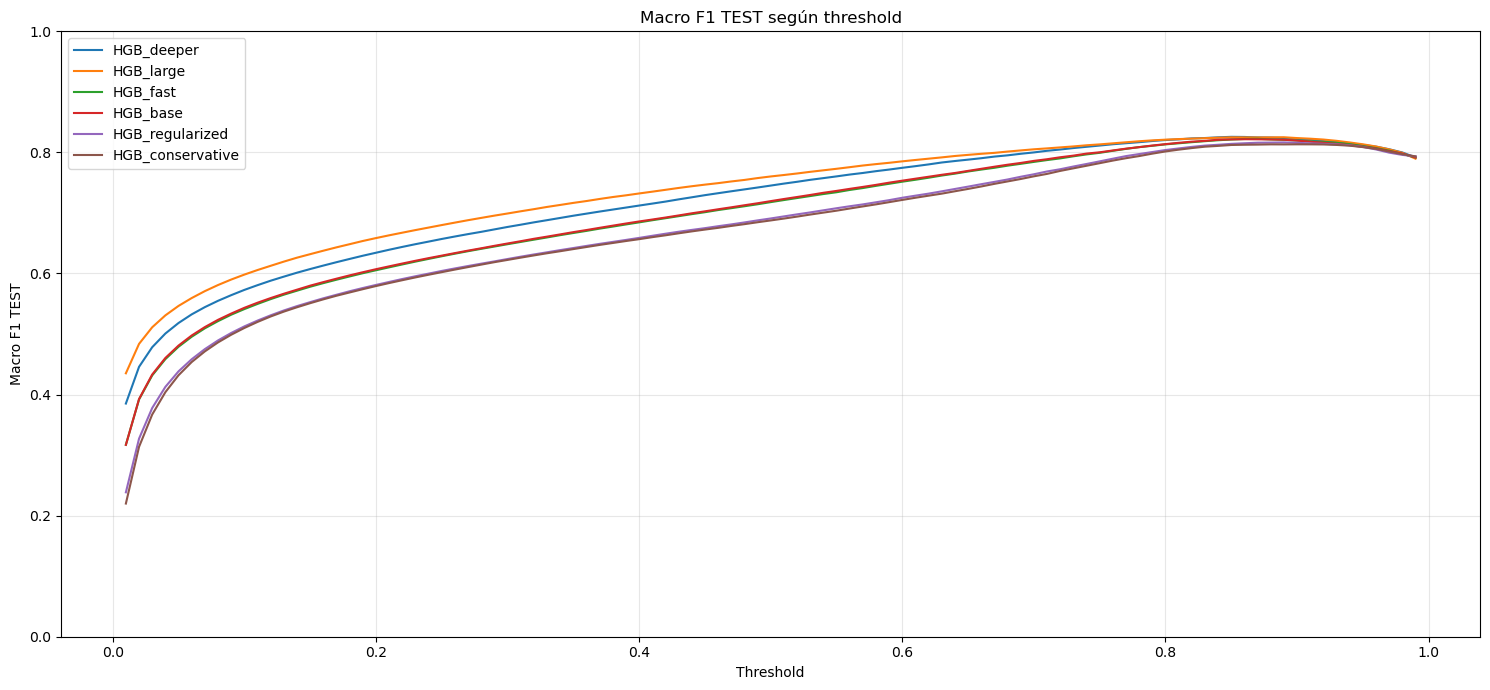

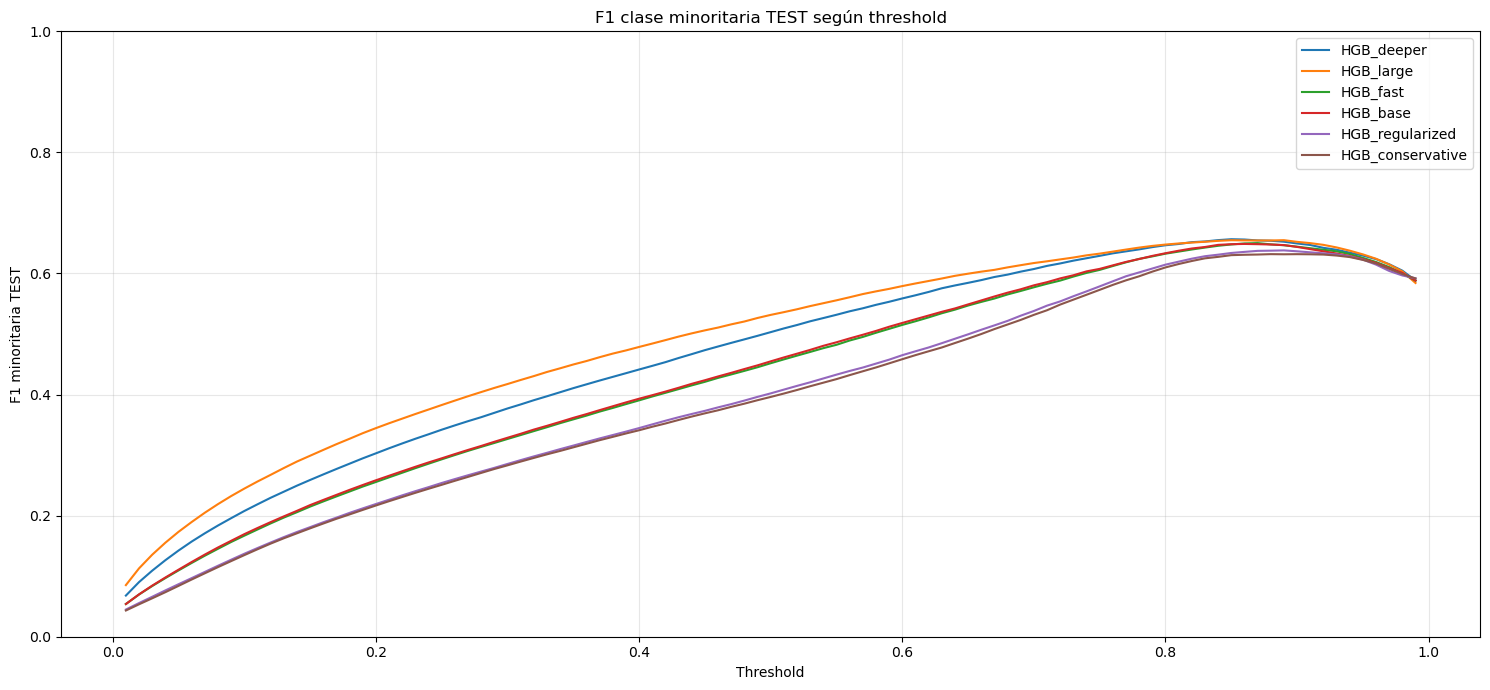

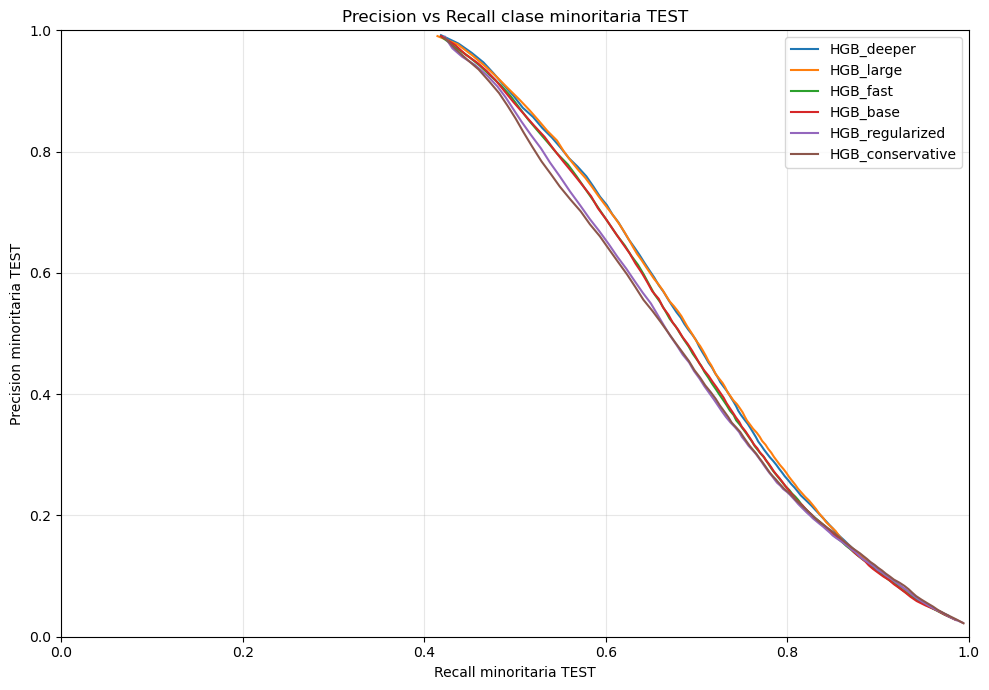


BEST TEST MODEL: HGB_deeper
model                      HGB_deeper
threshold                        0.85
macro_f1_test                0.825716
weighted_f1_test             0.989129
accuracy_test                0.989807
precision_minority_test      0.759202
recall_minority_test         0.578436
f1_minority_test             0.656605
precision_majority_test      0.992806
recall_majority_test         0.996856
f1_majority_test             0.994827
tn                            1240499
fp                               3912
fn                               8989
tp                              12334

FEATURE IMPORTANCE - BEST MODEL: HGB_deeper
                    feature  importance  importance_std  importance_pct
                   hour_sin    0.256006        0.000375        0.229263
                   hour_cos    0.238761        0.000401        0.213819
                    minutes    0.229583        0.000723        0.205600
               is_rush_hour    0.094032        0.000508        0.084

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

print("Creating temporal features...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Main lag
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# Rolling windows before lag_4
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=4, min_periods=1).mean()
)

df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=4, min_periods=1).mean()
)

# Trend: positive = worsening, negative = clearing
df["estado_trend"] = (
    df["estado_rolling_4_to_8"] -
    df["estado_rolling_8_to_12"]
)


# Consecutive congested steps ending at lag_4

def consecutive_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)
    count = 0

    for i, v in enumerate(values):
        if v == 1:
            count += 1
        else:
            count = 0
        result[i] = count

    return pd.Series(result, index=x.index)


df["consecutive_congested_steps"] = grouped["Estado_binary"].transform(
    consecutive_congestion_lag4
)


# Time since last congestion, measured in 15-min steps, using info available before lag_4

def time_since_last_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)

    last_seen = None

    for i, v in enumerate(values):
        if v == 1:
            last_seen = i
            result[i] = 0
        else:
            if last_seen is None:
                result[i] = 999
            else:
                result[i] = i - last_seen

    return pd.Series(result, index=x.index)


df["time_since_last_congestion"] = grouped["Estado_binary"].transform(
    time_since_last_congestion_lag4
)


before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
        "consecutive_congested_steps",
        "time_since_last_congestion",
    ]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

drop_cols = [
    "Estado",
    "Estado_binary",
    "fecha",
    "hora",
    "datetime"
]

feature_cols = [
    c for c in train_df.columns
    if c not in drop_cols
]

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing ALL features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = [
    "tmed",
    "prec",
    "tmin",
    "tmax",
    "sol",
    "minutes",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "estado_rolling_4_to_8",
    "estado_rolling_8_to_12",
    "estado_trend",
    "consecutive_congested_steps",
    "time_since_last_congestion",
]


continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

# ─────────────────────────────────────────────
# 15. PERMUTATION IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 15. FEATURE IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

from sklearn.inspection import permutation_importance

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

# Para que no tarde demasiado
X_importance = X_test.sample(
    n=min(50000, len(X_test)),
    random_state=42
)

y_importance = y_test.loc[X_importance.index]

perm_importance = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    scoring="f1_macro",
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

print("\n" + "=" * 100)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 100)

print(importance_df.to_string(index=False))

SOLO FEATURES MAS IMPORTANTES

Creating temporal features...
Dropped 1152 rows
Remaining rows: 5456090

Train rows: 4190356
Test rows: 1265734

Using CLEAN selected features (15):
['hour_sin', 'hour_cos', 'minutes', 'is_rush_hour', 'is_night', 'is_weekend', 'Day_of_week', 'estado_lag_4', 'consecutive_congested_steps', 'time_since_last_congestion', 'estado_trend', 'estado_rolling_4_to_8', 'sol', 'day', 'Public_holiday']

Scaled continuous columns (9):
['hour_sin', 'hour_cos', 'minutes', 'time_since_last_congestion', 'consecutive_congested_steps', 'estado_trend', 'estado_rolling_4_to_8', 'sol', 'day']

After resampling TRAIN: 400000 rows
Estado_binary
0    200000
1    200000
Name: count, dtype: int64

TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES

----------------------------------------------------------------------------------------------------
Training model: HGB_base
----------------------------------------------------------------------------------------------------

Best TEST result:
Threshold:          0.

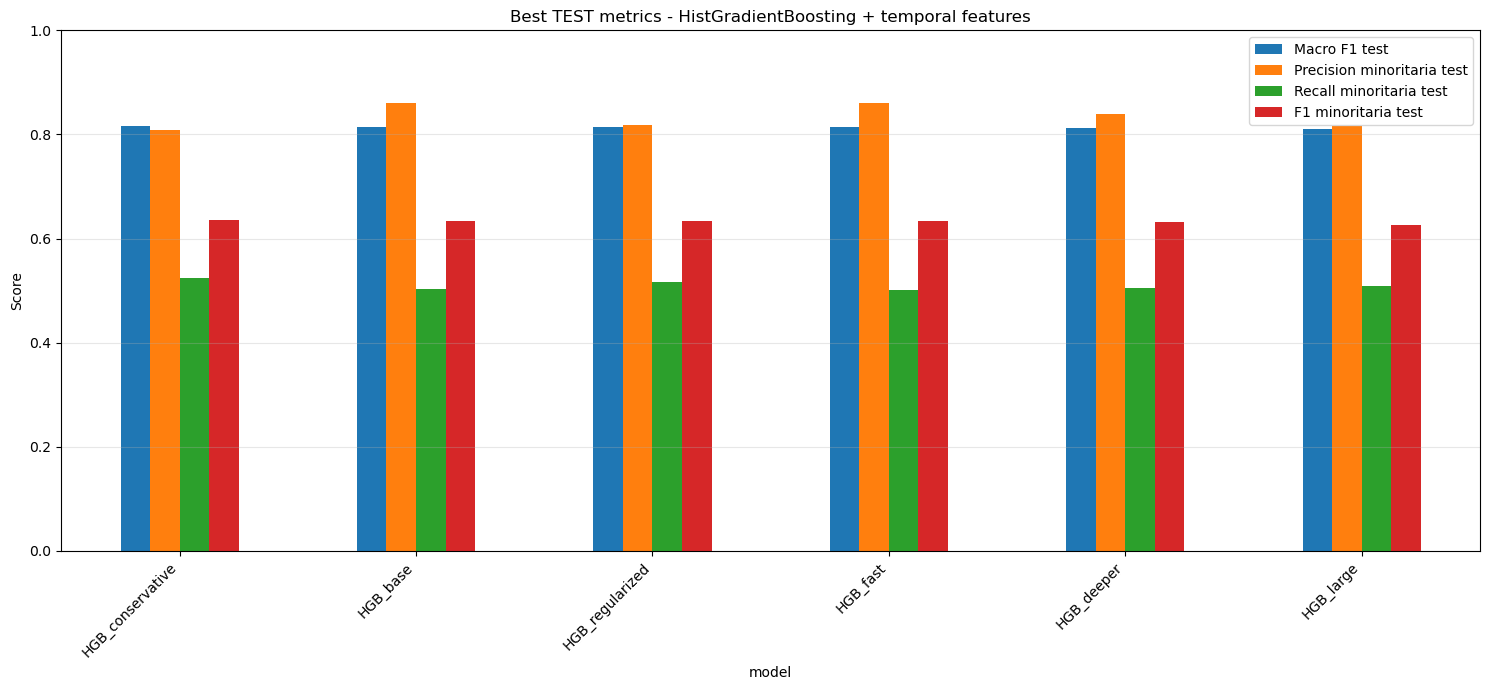

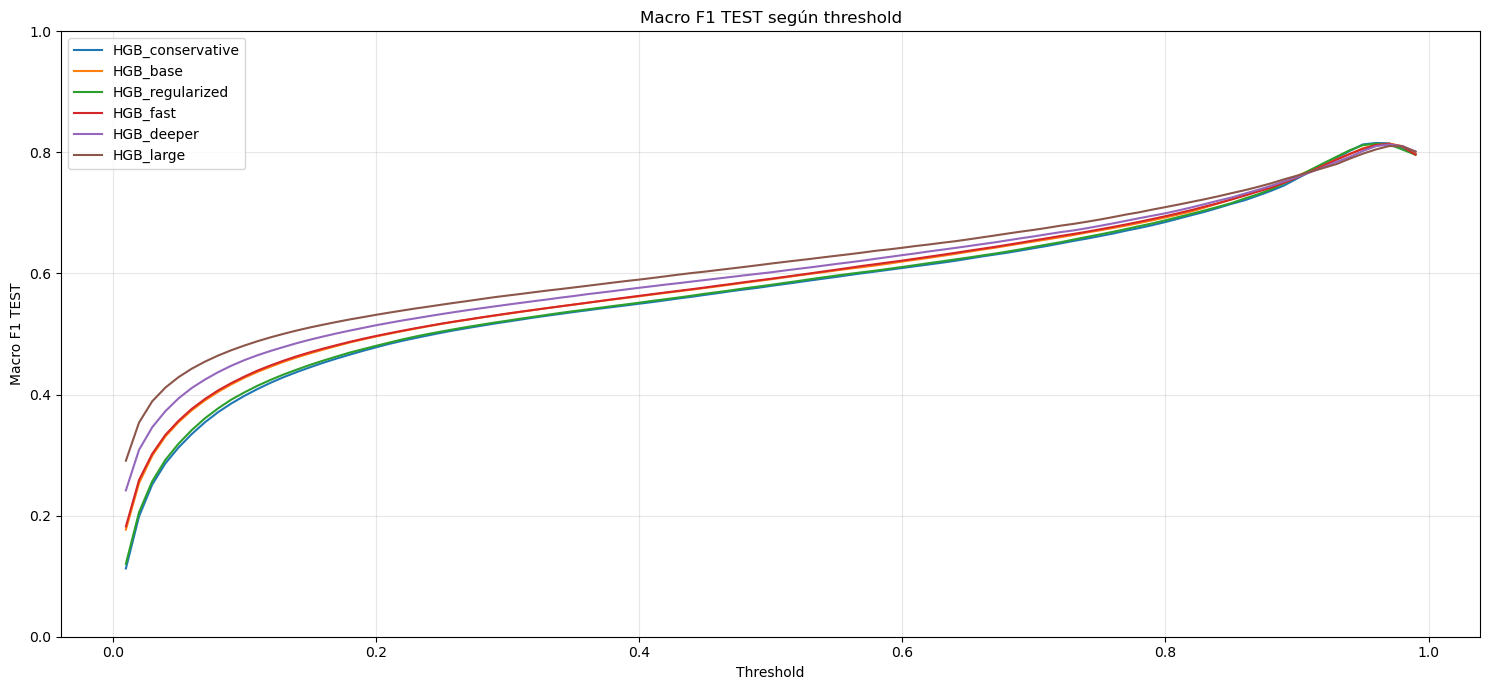

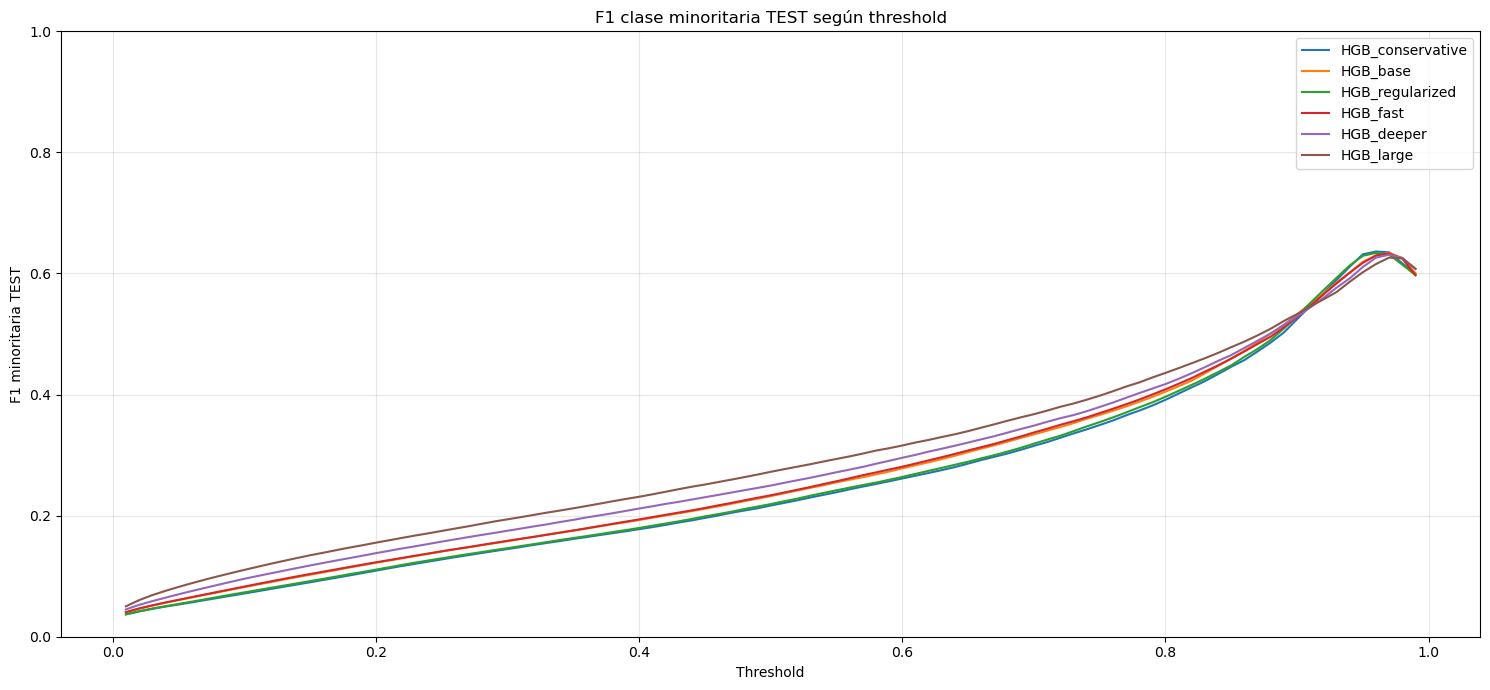

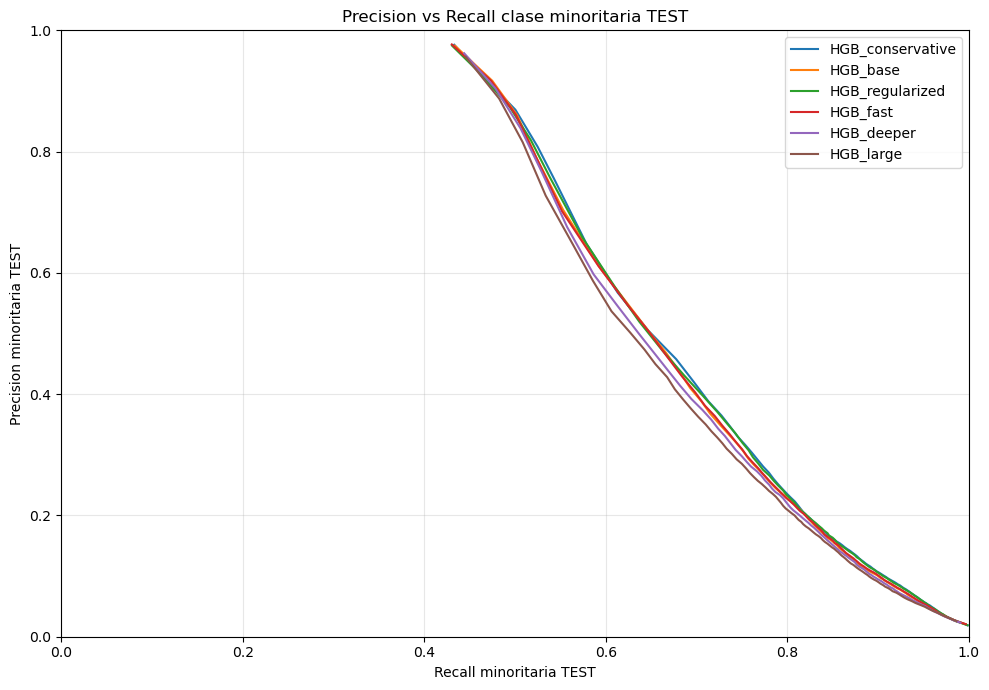


BEST TEST MODEL: HGB_conservative
model                      HGB_conservative
threshold                              0.96
macro_f1_test                       0.81558
weighted_f1_test                   0.988834
accuracy_test                      0.989892
precision_minority_test            0.807839
recall_minority_test               0.524832
f1_minority_test                   0.636286
precision_majority_test            0.991907
recall_majority_test               0.997861
f1_majority_test                   0.994875
tn                                  1241749
fp                                     2662
fn                                    10132
tp                                    11191

FEATURE IMPORTANCE - BEST MODEL: HGB_conservative
                    feature  importance  importance_std  importance_pct
                    minutes    0.101771        0.000041        0.317043
                   hour_sin    0.099625        0.000308        0.310360
                   hour_cos    0.07255

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from sklearn.ensemble import HistGradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────

df = pd.read_csv("dataset_final.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df["datetime"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"])

df["Estado_binary"] = (df["Estado"] != 0).astype(int)

df = df.sort_values(
    ["Denominació / Denominación", "datetime"]
).reset_index(drop=True)


# ─────────────────────────────────────────────
# 2. TEMPORAL FEATURES
# ─────────────────────────────────────────────

print("Creating temporal features...")

group_col = "Denominació / Denominación"

grouped = df.groupby(group_col)

# Main lag
df["estado_lag_4"] = grouped["Estado_binary"].shift(4)

# Rolling windows before lag_4
df["estado_rolling_4_to_8"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(4).rolling(window=4, min_periods=1).mean()
)

df["estado_rolling_8_to_12"] = grouped["Estado_binary"].transform(
    lambda x: x.shift(8).rolling(window=4, min_periods=1).mean()
)

# Trend: positive = worsening, negative = clearing
df["estado_trend"] = (
    df["estado_rolling_4_to_8"] -
    df["estado_rolling_8_to_12"]
)


# Consecutive congested steps ending at lag_4

def consecutive_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)
    count = 0

    for i, v in enumerate(values):
        if v == 1:
            count += 1
        else:
            count = 0
        result[i] = count

    return pd.Series(result, index=x.index)


df["consecutive_congested_steps"] = grouped["Estado_binary"].transform(
    consecutive_congestion_lag4
)


# Time since last congestion, measured in 15-min steps, using info available before lag_4

def time_since_last_congestion_lag4(x):
    values = x.shift(4).fillna(0).astype(int).values
    result = np.zeros(len(values), dtype=np.float32)

    last_seen = None

    for i, v in enumerate(values):
        if v == 1:
            last_seen = i
            result[i] = 0
        else:
            if last_seen is None:
                result[i] = 999
            else:
                result[i] = i - last_seen

    return pd.Series(result, index=x.index)


df["time_since_last_congestion"] = grouped["Estado_binary"].transform(
    time_since_last_congestion_lag4
)


before = len(df)

df = df.dropna(
    subset=[
        "estado_lag_4",
        "estado_rolling_4_to_8",
        "estado_rolling_8_to_12",
        "estado_trend",
        "consecutive_congested_steps",
        "time_since_last_congestion",
    ]
).reset_index(drop=True)

print(f"Dropped {before - len(df)} rows")
print(f"Remaining rows: {len(df)}")


# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

train_mask = df["fecha"].dt.year.isin([2023, 2024])
test_mask = df["fecha"].dt.year == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")


# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    time_parts = df["hora"].str.split(":", expand=True).astype(int)
    hour = time_parts[0]

    df["minutes"] = time_parts[0] * 60 + time_parts[1]

    df["hour_sin"] = np.sin(2 * np.pi * df["minutes"] / 1440)
    df["hour_cos"] = np.cos(2 * np.pi * df["minutes"] / 1440)

    df["month"] = df["fecha"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day"] = df["fecha"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)

    df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = df["fecha"].dt.dayofweek.isin([5, 6]).astype(int)

    df["is_rush_hour"] = (
        ((hour >= 7) & (hour <= 9)) |
        ((hour >= 17) & (hour <= 20))
    ).astype(int)

    df["is_night"] = (
        (hour >= 22) | (hour <= 6)
    ).astype(int)

    return df


train_df = add_features(train_df)
test_df = add_features(test_df)


# ─────────────────────────────────────────────
# 5. LABEL ENCODING
# ─────────────────────────────────────────────

le_denom = LabelEncoder()

train_df["Denominació / Denominación"] = le_denom.fit_transform(
    train_df["Denominació / Denominación"]
)

test_df["Denominació / Denominación"] = le_denom.transform(
    test_df["Denominació / Denominación"]
)

le_day = LabelEncoder()

train_df["Day_of_week"] = le_day.fit_transform(
    train_df["Day_of_week"]
)

test_df["Day_of_week"] = le_day.transform(
    test_df["Day_of_week"]
)


# ─────────────────────────────────────────────
# 6. USE ALL FEATURES
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 6. USE SELECTED CLEAN FEATURES
# ─────────────────────────────────────────────

selected_features_hgb_clean = [
    "hour_sin",
    "hour_cos",
    "minutes",
    "is_rush_hour",
    "is_night",
    "is_weekend",
    "Day_of_week",
    "estado_lag_4",
    "consecutive_congested_steps",
    "time_since_last_congestion",
    "estado_trend",
    "estado_rolling_4_to_8",
    "sol",
    "day",
    "Public_holiday",
]

feature_cols = [
    c for c in selected_features_hgb_clean
    if c in train_df.columns
]

missing_features = [
    c for c in selected_features_hgb_clean
    if c not in train_df.columns
]

if len(missing_features) > 0:
    print("\nWARNING - Missing selected features:")
    print(missing_features)

X_train = train_df[feature_cols].copy()
y_train = train_df["Estado_binary"]

X_test = test_df[feature_cols].copy()
y_test = test_df["Estado_binary"]

print(f"\nUsing CLEAN selected features ({len(feature_cols)}):")
print(feature_cols)


# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────────

continuous_cols = [
    "hour_sin",
    "hour_cos",
    "minutes",
    "time_since_last_congestion",
    "consecutive_congested_steps",
    "estado_trend",
    "estado_rolling_4_to_8",
    "sol",
    "day",
]

continuous_cols = [
    c for c in continuous_cols
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print(f"\nScaled continuous columns ({len(continuous_cols)}):")
print(continuous_cols)


# ─────────────────────────────────────────────
# 8. RESAMPLING TRAIN ONLY
# ─────────────────────────────────────────────

TARGET_SAMPLES = 200000

pipeline = ImbPipeline(steps=[
    (
        "undersample",
        RandomUnderSampler(
            sampling_strategy={0: TARGET_SAMPLES},
            random_state=42
        )
    ),
    (
        "oversample",
        SMOTE(
            sampling_strategy={1: TARGET_SAMPLES},
            random_state=42,
            k_neighbors=5
        )
    ),
])

X_train_res, y_train_res = pipeline.fit_resample(
    X_train,
    y_train
)

print(f"\nAfter resampling TRAIN: {len(X_train_res)} rows")
print(pd.Series(y_train_res).value_counts())


# ─────────────────────────────────────────────
# 9. HISTGRADIENTBOOSTING MODELS
# ─────────────────────────────────────────────

models = {
    "HGB_base": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_deeper": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=127,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_regularized": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=1.0,
        random_state=42
    ),

    "HGB_conservative": HistGradientBoostingClassifier(
        max_iter=700,
        learning_rate=0.02,
        max_leaf_nodes=31,
        min_samples_leaf=150,
        l2_regularization=2.0,
        random_state=42
    ),

    "HGB_fast": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        l2_regularization=0.1,
        random_state=42
    ),

    "HGB_large": HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=255,
        min_samples_leaf=30,
        l2_regularization=0.05,
        random_state=42
    ),
}


# ─────────────────────────────────────────────
# 10. THRESHOLDS 0.01 → 0.99
# ─────────────────────────────────────────────

THRESHOLDS = np.arange(0.01, 1.00, 0.01)


# ─────────────────────────────────────────────
# 11. TRAIN + EVALUATE ON TEST
# ─────────────────────────────────────────────

all_results = []
trained_models = {}

print("\n" + "=" * 100)
print("TRAINING HISTGRADIENTBOOSTING WITH TEMPORAL FEATURES")
print("=" * 100)

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print(f"Training model: {model_name}")
    print("-" * 100)

    model.fit(X_train_res, y_train_res)

    trained_models[model_name] = model

    y_proba_test = model.predict_proba(X_test)[:, 1]

    for threshold in THRESHOLDS:

        y_pred_test = (y_proba_test > threshold).astype(int)

        cm = confusion_matrix(
            y_test,
            y_pred_test,
            labels=[0, 1]
        )

        report = classification_report(
            y_test,
            y_pred_test,
            target_names=["fluido(0)", "no_fluido(1)"],
            output_dict=True,
            zero_division=0
        )

        all_results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),

            "macro_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="macro"
            ),

            "weighted_f1_test": f1_score(
                y_test,
                y_pred_test,
                average="weighted"
            ),

            "accuracy_test": accuracy_score(
                y_test,
                y_pred_test
            ),

            "precision_minority_test": report["no_fluido(1)"]["precision"],
            "recall_minority_test": report["no_fluido(1)"]["recall"],
            "f1_minority_test": report["no_fluido(1)"]["f1-score"],

            "precision_majority_test": report["fluido(0)"]["precision"],
            "recall_majority_test": report["fluido(0)"]["recall"],
            "f1_majority_test": report["fluido(0)"]["f1-score"],

            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

    model_results = pd.DataFrame([
        r for r in all_results
        if r["model"] == model_name
    ])

    best_row = model_results.loc[
        model_results["macro_f1_test"].idxmax()
    ]

    print("\nBest TEST result:")
    print(f"Threshold:          {best_row['threshold']}")
    print(f"Macro F1 test:      {best_row['macro_f1_test']:.4f}")
    print(f"Weighted F1 test:   {best_row['weighted_f1_test']:.4f}")
    print(f"Accuracy test:      {best_row['accuracy_test']:.4f}")
    print(f"Precision minority: {best_row['precision_minority_test']:.4f}")
    print(f"Recall minority:    {best_row['recall_minority_test']:.4f}")
    print(f"F1 minority:        {best_row['f1_minority_test']:.4f}")

    print("\nConfusion matrix:")
    print(np.array([
        [best_row["tn"], best_row["fp"]],
        [best_row["fn"], best_row["tp"]]
    ]))


# ─────────────────────────────────────────────
# 12. RESULTS
# ─────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "macro_f1_test",
    ascending=False
)

print("\n" + "=" * 100)
print("TOP 50 TEST RESULTS")
print("=" * 100)

print(results_df.head(50).to_string(index=False))


best_by_model = (
    results_df
    .sort_values("macro_f1_test", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("macro_f1_test", ascending=False)
)

print("\n" + "=" * 100)
print("BEST TEST RESULT BY MODEL")
print("=" * 100)

print(best_by_model.to_string(index=False))


# ─────────────────────────────────────────────
# 13. PLOTS
# ─────────────────────────────────────────────

plot_df = best_by_model.set_index("model")

metrics_to_plot = [
    "macro_f1_test",
    "precision_minority_test",
    "recall_minority_test",
    "f1_minority_test",
]

plot_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Best TEST metrics - HistGradientBoosting + temporal features")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.legend([
    "Macro F1 test",
    "Precision minoritaria test",
    "Recall minoritaria test",
    "F1 minoritaria test",
])

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["macro_f1_test"],
        label=model_name
    )

plt.title("Macro F1 TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("Macro F1 TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["threshold"],
        tmp["f1_minority_test"],
        label=model_name
    )

plt.title("F1 clase minoritaria TEST según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 minoritaria TEST")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 7))

for model_name in best_by_model["model"].tolist():

    tmp = results_df[
        results_df["model"] == model_name
    ].sort_values("threshold")

    plt.plot(
        tmp["recall_minority_test"],
        tmp["precision_minority_test"],
        label=model_name
    )

plt.title("Precision vs Recall clase minoritaria TEST")
plt.xlabel("Recall minoritaria TEST")
plt.ylabel("Precision minoritaria TEST")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# 14. BEST MODEL
# ─────────────────────────────────────────────

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\n" + "=" * 100)
print(f"BEST TEST MODEL: {best_model_name}")
print("=" * 100)

print(best_by_model.iloc[0].to_string())

# ─────────────────────────────────────────────
# 15. PERMUTATION IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 15. FEATURE IMPORTANCE - BEST HGB MODEL
# ─────────────────────────────────────────────

from sklearn.inspection import permutation_importance

best_model_name = best_by_model.iloc[0]["model"]
best_model = trained_models[best_model_name]

# Para que no tarde demasiado
X_importance = X_test.sample(
    n=min(50000, len(X_test)),
    random_state=42
)

y_importance = y_test.loc[X_importance.index]

perm_importance = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    scoring="f1_macro",
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

print("\n" + "=" * 100)
print(f"FEATURE IMPORTANCE - BEST MODEL: {best_model_name}")
print("=" * 100)

print(importance_df.to_string(index=False))